# 0. Wstęp

In [1]:
import sys
from pathlib import Path

KATALOG_PROJEKTU = Path.cwd().parent
sys.path.insert(0, str(KATALOG_PROJEKTU / "src"))

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from dobrostan import prepare_data, schema, stats as st, plots as pl, report as rp

pl.apply_style()
pd.set_option("display.max_columns", 40)

df, tabela_mapowan = prepare_data(KATALOG_PROJEKTU / "data" / "raw" / "dane.csv")

ETYKIETY = schema.labels()          # krótkie nazwy — osie i legendy wykresów
OPISY = schema.descriptions()       # pełne nazwy — tabele wyników
WARTOSCI = schema.value_labels      # etykiety kategorii wybranej zmiennej

print(f"Wczytano {len(df)} respondentów i {df.shape[1]} zmiennych.")

Wczytano 396 respondentów i 46 zmiennych.


## 0.1 Cel badania

Celem niniejszego projektu była analiza dobrostanu studentów Politechniki Wrocławskiej oraz identyfikacja czynników związanych z jego poziomem.

W badaniu uwzględniono zarówno ogólną satysfakcję z życia, jak i inne wskaźniki dobrostanu, w szczególności zdrowie psychiczne, zdrowie fizyczne, poziom stresu oraz poczucie kontroli nad własnym życiem. Analizowano związki pomiędzy tymi obszarami a cechami stylu życia studentów, takimi jak sen, aktywność fizyczna, sposób odżywiania, relacje społeczne, aktywność akademicka, sytuacja materialna oraz aktywność zawodowa.

Dodatkowo przeprowadzono analizy wybranych czynników demograficznych i akademickich, obejmujących między innymi wydział, etap studiów oraz formy zamieszkania.

Celem raportu jest przedstawienie najważniejszych zależności występujących w badanej próbie oraz wskazanie czynników, które najsilniej wiążą się z dobrostanem studentów.

## 0.2 Dane

Analiza została przeprowadzona na danych ankietowych zebranych wśród studentów Politechniki Wrocławskiej.

Po przygotowaniu danych do analizy końcowy zbiór obejmował 396 respondentów i 46 zmiennych.

W zbiorze znalazły się zarówno zmienne ilościowe, porządkowe, jak i kategoryczne opisujące różne aspekty funkcjonowania studentów.

Zakres danych obejmował między innymi informacje dotyczące dobrostanu, stylu życia, sytuacji akademickiej, aktywności zawodowej oraz cech demograficznych.

## 0.3 Metody statystyczne

Analizy przeprowadzono metodami dobranymi do charakteru danych ankietowych, obejmujących zmienne ilościowe, porządkowe i kategoryczne.

Zależności między zmiennymi oceniano współczynnikiem korelacji rang Spearmana. Dwie niezależne grupy porównywano testem U Manna-Whitneya, a większą ich liczbę — testem Kruskala-Wallisa wraz z testem post hoc Dunna. Zależności między zmiennymi kategorycznymi badano testem chi-kwadrat niezależności. Dla wybranych zagadnień zastosowano modele regresji liniowej.

Przy seriach powiązanych testów stosowano korektę Benjaminiego-Hochberga (FDR). Korekta obejmuje **pełną rodzinę wykonanych porównań**, a nie tylko wyniki prezentowane na wykresie; przy każdym rankingu podana jest liczba testów objętych korektą. Za poziom istotności przyjęto α = 0,05.

Zmiennym porządkowym zapisanym w postaci przedziałów przypisano wartości reprezentatywne, zachowujące naturalny porządek kategorii. Dla przedziałów domkniętych jest to środek przedziału, dla kategorii otwartych (np. „10 i więcej") — wartość brzegowa. Pełne zestawienie znajduje się w aneksie, a konsekwencje tego wyboru omówiono w rozdziale 13.

## 0.4 Kontrola jakości danych

Kwestionariusz został zaprojektowany w sposób ograniczający liczbę braków danych. Wszystkie pytania miały charakter zamknięty, a większość z nich była obowiązkowa. W części pytań respondenci mogli wybrać odpowiedź „Nie chcę odpowiadać”, która została zakodowana jako brak danych.

Nie zidentyfikowano zduplikowanych odpowiedzi w przygotowanym zbiorze.

Występujące braki danych dotyczyły przede wszystkim pytań warunkowych związanych z aktywnością zawodową. Zauważalny odsetek braków odnotowano również dla deklarowanej średniej ocen (27%), co mogło wynikać z udziału studentów pierwszego semestru, którzy nie posiadali jeszcze średniej z poprzedniego semestru.

Dla pozostałych zmiennych braki występowały wyłącznie w przypadkach wyboru odpowiedzi „Nie chcę odpowiadać”, a ich odsetek nie przekraczał 2%.

## 0.5 Pytania badawcze

Analiza została ukierunkowana na odpowiedź na następujące pytania badawcze:

1. Czy wybrane elementy stylu życia studentów — sen, aktywność fizyczna i sposób odżywiania — są związane z poziomem dobrostanu?

2. Czy relacje społeczne, sytuacja akademicka oraz aktywność zawodowa wykazują związek z dobrostanem studentów?

3. Które czynniki wykazują najsilniejszy związek z satysfakcją z życia, zdrowiem psychicznym, zdrowiem fizycznym oraz poziomem stresu?

4. Czy obserwowane zależności utrzymują się po jednoczesnym uwzględnieniu wielu czynników?

Odpowiedzi na te pytania zestawiono w rozdziale 14.

---

# 1. Charakterystyka próby

W niniejszej sekcji przedstawiono charakterystykę badanej próby pod względem cech demograficznych, warunków życia oraz aktywności zawodowej. Celem tej części jest opis struktury badanej grupy przed przejściem do analiz zależności pomiędzy badanymi zmiennymi.

## 1.1 Charakterystyka demograficzna

### 1.1.1 Wiek

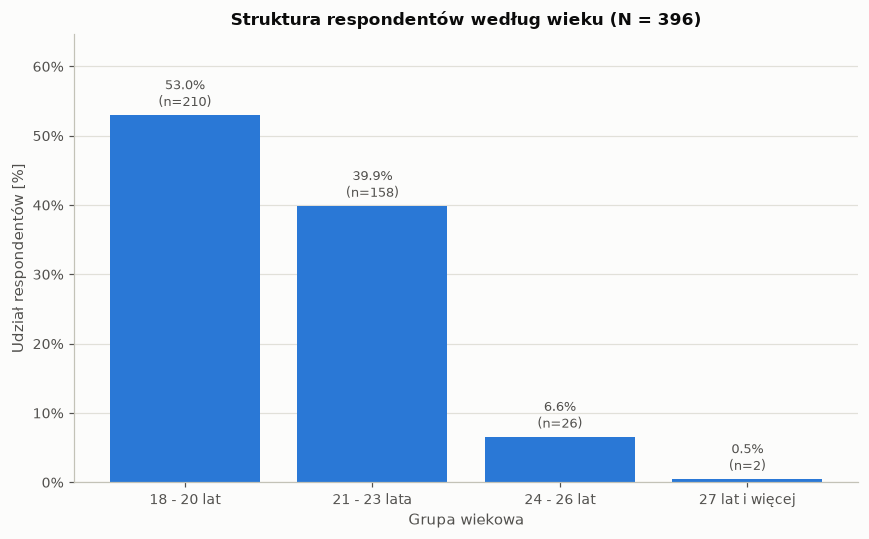

In [2]:
_ = pl.plot_distribution(
    df,
    "wiek_grupa",
    title="Struktura respondentów według wieku",
    xlabel="Grupa wiekowa",
)

W badanej próbie dominowali respondenci w wieku 18-20 lat (53,0%) oraz 21-23 lat (39,9%). Osoby w wieku powyżej 23 lat stanowiły niewielki odsetek uczestników badania (łącznie 7,1%). Struktura wieku wskazuje, że większość respondentów należała do młodszych grup wiekowych.

### 1.1.2 Płeć

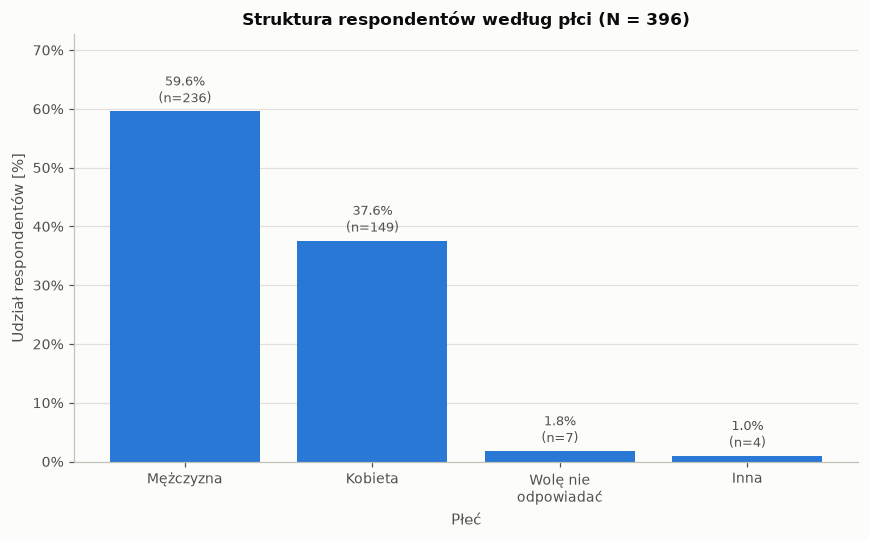

In [3]:
_ = pl.plot_distribution(
    df,
    "plec",
    sort="count",
    title="Struktura respondentów według płci",
    xlabel="Płeć",
)

Struktura płci badanej próby była zdominowana przez mężczyzn, którzy stanowili 59,6% respondentów. Kobiety stanowiły 37,6% uczestników badania. Pozostałe odpowiedzi ("Wolę nie odpowiadać" oraz "Inna") występowały sporadycznie i łącznie obejmowały 2,8% próby.

### 1.1.3 Wydział

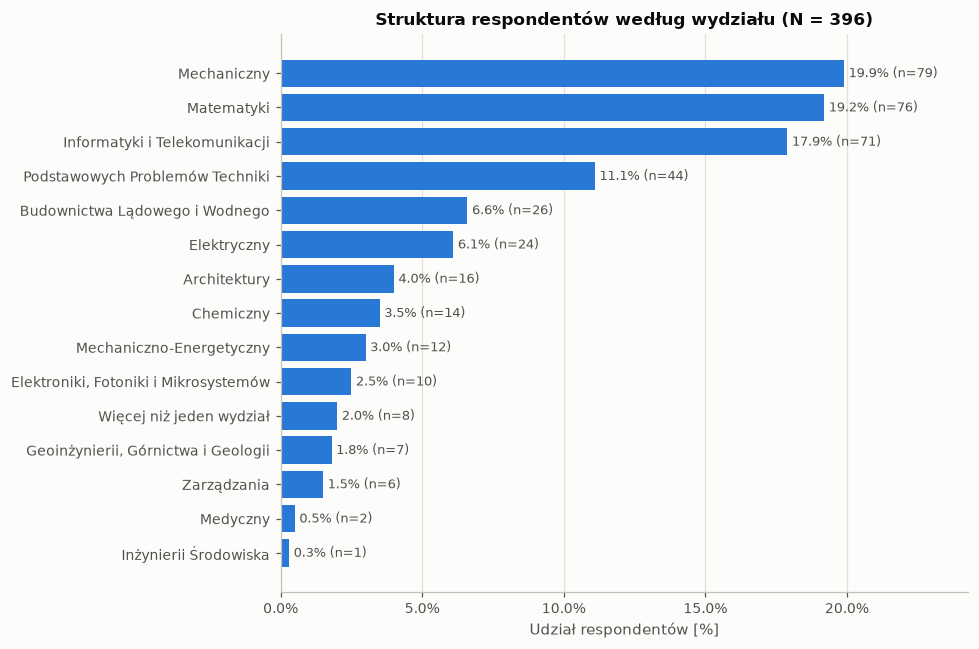

In [4]:
_ = pl.plot_distribution(
    df,
    "wydzial",
    sort="count",
    horizontal=True,
    wrap=42,
    figsize=(9, 6),
    title="Struktura respondentów według wydziału",
)

Respondenci reprezentowali wszystkie wydziały Politechniki Wrocławskiej, jednak ich udział w badaniu był zróżnicowany. Najliczniej reprezentowani byli studenci Wydziału Mechanicznego (19,9%), Wydziału Matematyki (19,2%) oraz Wydziału Informatyki i Telekomunikacji (17,9%). Najmniejszy udział stanowili studenci Wydziału Inżynierii Środowiska (jeden respondent) oraz Wydziału Medycznego (dwóch respondentów). Niewielka grupa respondentów (2,0%) zadeklarowała przynależność do więcej niż jednego wydziału.

### 1.1.4 Etap studiów

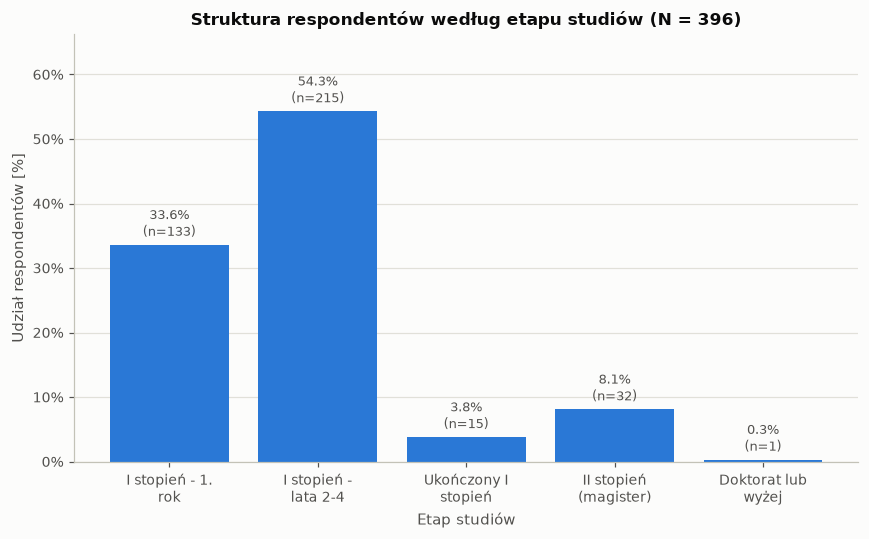

In [5]:
_ = pl.plot_distribution(
    df,
    "etap_studiow",
    wrap=14,
    title="Struktura respondentów według etapu studiów",
    xlabel="Etap studiów",
)

Największą grupę respondentów stanowili studenci I stopnia z lat 2-4 (54,3%). Studenci I roku studiów I stopnia stanowili 33,6% respondentów. Znacznie mniejszy udział mieli studenci II stopnia (8,1%) oraz osoby, które ukończyły studia I stopnia (3,8%). W badaniu uczestniczyła również jedna osoba deklarująca kształcenie na poziomie doktoratu.

## 1.2 Warunki życia

W tej części przedstawiono charakterystykę warunków życia respondentów, obejmującą sposób zamieszkania, liczbę współlokatorów oraz czas dojazdu na uczelnię.

### 1.2.1 Typ zamieszkania

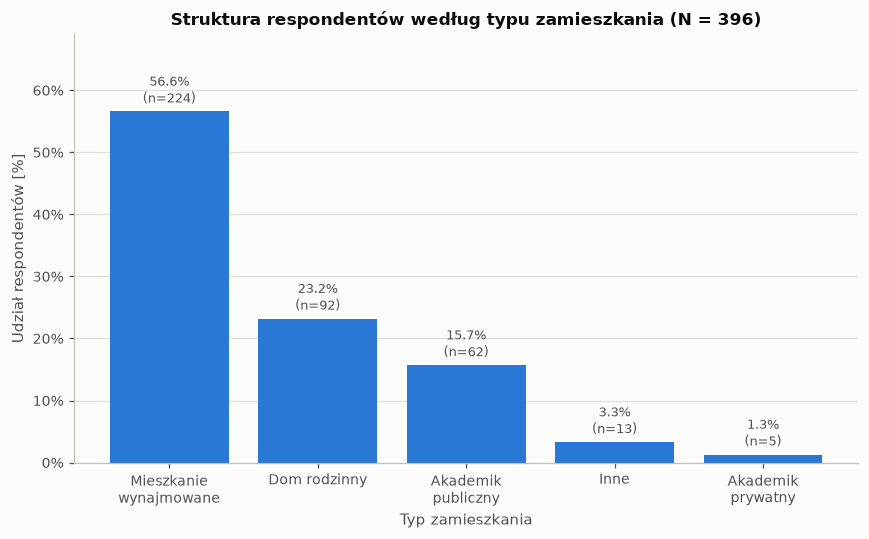

In [6]:
_ = pl.plot_distribution(
    df,
    "typ_zamieszkania",
    sort="count",
    wrap=14,
    title="Struktura respondentów według typu zamieszkania",
    xlabel="Typ zamieszkania",
)

Najczęściej wskazywaną formą zamieszkania było mieszkanie wynajmowane, które zadeklarowało 56,6% respondentów. Niemal jedna czwarta badanych (23,2%) mieszkała w domu rodzinnym, natomiast 15,7% respondentów zamieszkiwało akademik publiczny. Pozostałe formy zamieszkania występowały sporadycznie i obejmowały inne miejsca zamieszkania (3,3%) oraz akademik prywatny (1,3%).

### 1.2.2 Współlokatorzy

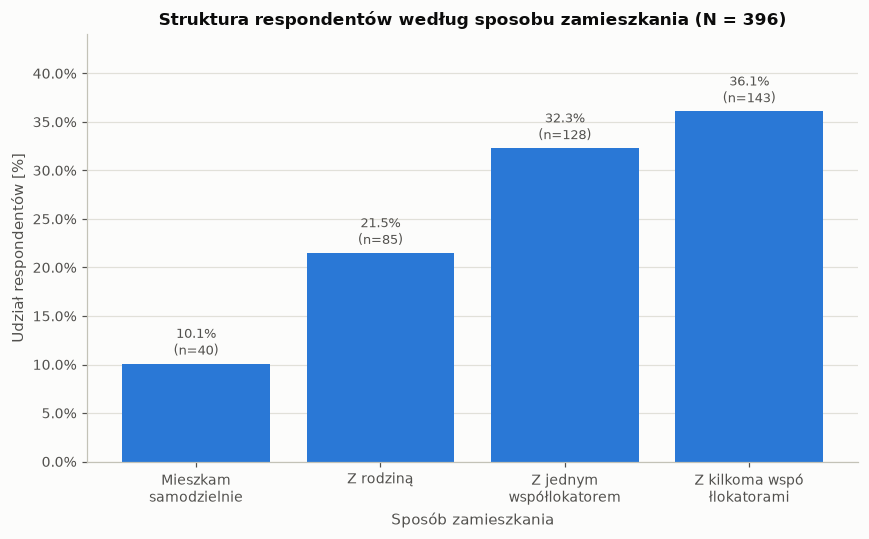

In [7]:
_ = pl.plot_distribution(
    df,
    "wspollokatorzy",
    wrap=14,
    title="Struktura respondentów według sposobu zamieszkania",
    xlabel="Sposób zamieszkania",
)

Największą grupę respondentów (36,1%) stanowili studenci mieszkający z kilkoma współlokatorami, natomiast 32,3% badanych mieszkało z jednym współlokatorem. Z rodziną mieszkało 21,5% respondentów, a 10,1% deklarowało samodzielne zamieszkiwanie.

### 1.2.3 Czas dojazdu na uczelnię

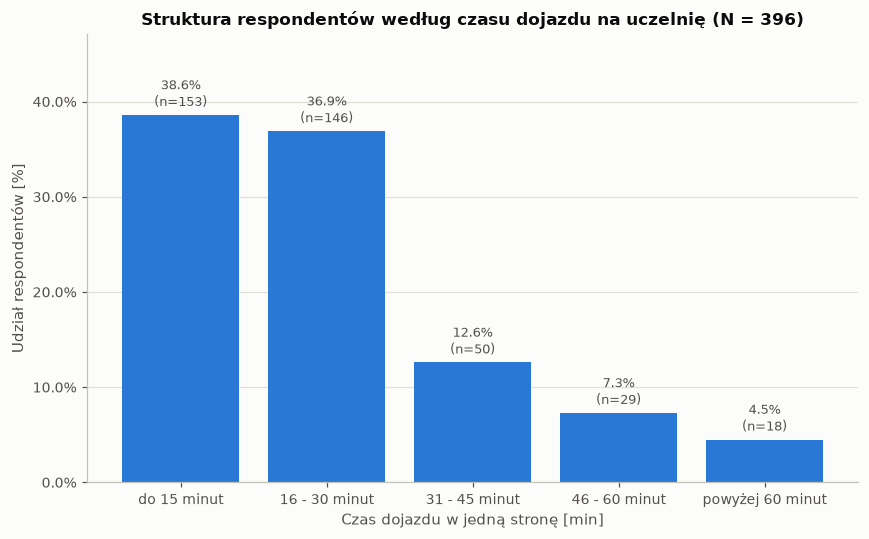

In [8]:
_ = pl.plot_distribution(
    df,
    "dojazd_min",
    value_labels=WARTOSCI("dojazd_min"),
    title="Struktura respondentów według czasu dojazdu na uczelnię",
    xlabel="Czas dojazdu w jedną stronę [min]",
)

Największa część respondentów deklarowała czas dojazdu na uczelnię wynoszący do 15 minut (38,6%) lub 16-30 minut (36,9%). Łącznie ponad trzy czwarte badanych (75,5%) dojeżdżało na uczelnię w czasie nieprzekraczającym 30 minut. Dłuższy czas dojazdu deklarowało 12,6% respondentów (31-45 minut), 7,3% (46-60 minut) oraz 4,5% (powyżej 60 minut).

## 1.3 Aktywność zawodowa

W tej części przedstawiono charakterystykę aktywności zawodowej respondentów, obejmującą odsetek osób pracujących, formę zatrudnienia oraz zgodność wykonywanej pracy z kierunkiem studiów.

### 1.3.1 Odsetek osób pracujących

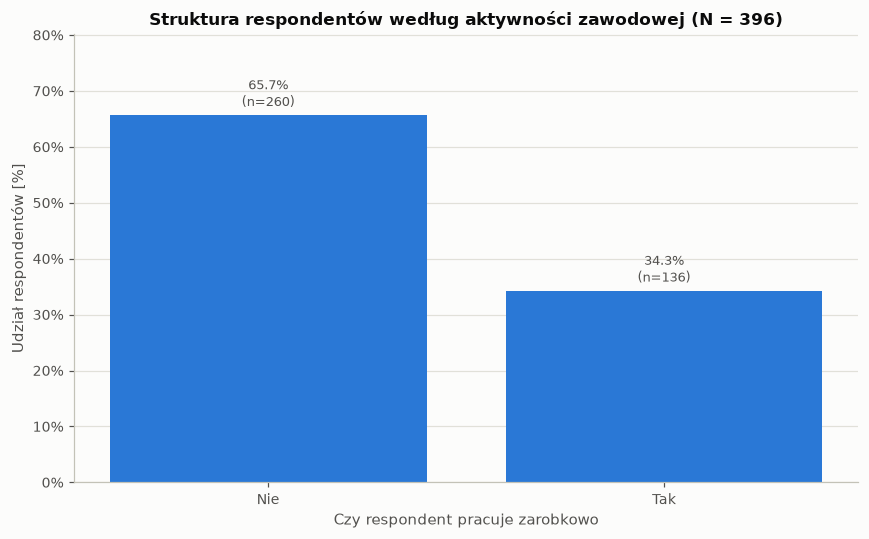

In [9]:
_ = pl.plot_distribution(
    df,
    "czy_pracuje",
    value_labels=WARTOSCI("czy_pracuje"),
    title="Struktura respondentów według aktywności zawodowej",
    xlabel="Czy respondent pracuje zarobkowo",
)

W badanej próbie dominowały osoby niepracujące, które stanowiły 65,7% respondentów. Aktywność zawodową deklarowało 34,3% badanych.

### 1.3.2 Forma pracy

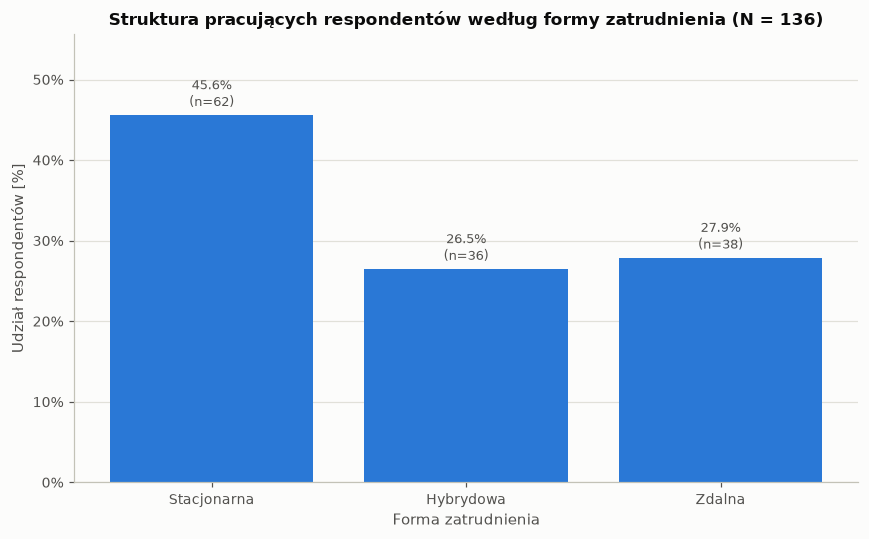

In [10]:
# Pytania o pracę były warunkowe — poniższe analizy dotyczą wyłącznie osób pracujących.
df_pracujacy = df[df["czy_pracuje"] == 1].copy()

_ = pl.plot_distribution(
    df_pracujacy,
    "forma_pracy",
    title="Struktura pracujących respondentów według formy zatrudnienia",
    xlabel="Forma zatrudnienia",
)

Wśród respondentów deklarujących aktywność zawodową najczęściej występowała praca stacjonarna, którą wykonywało 45,6% badanych. Pracę zdalną deklarowało 27,9% respondentów, natomiast hybrydową - 26,5%. Oznacza to, że ponad połowa pracujących studentów (54,4%) wykonywała pracę przynajmniej częściowo zdalnie.

### 1.3.3 Zgodność pracy z kierunkiem studiów

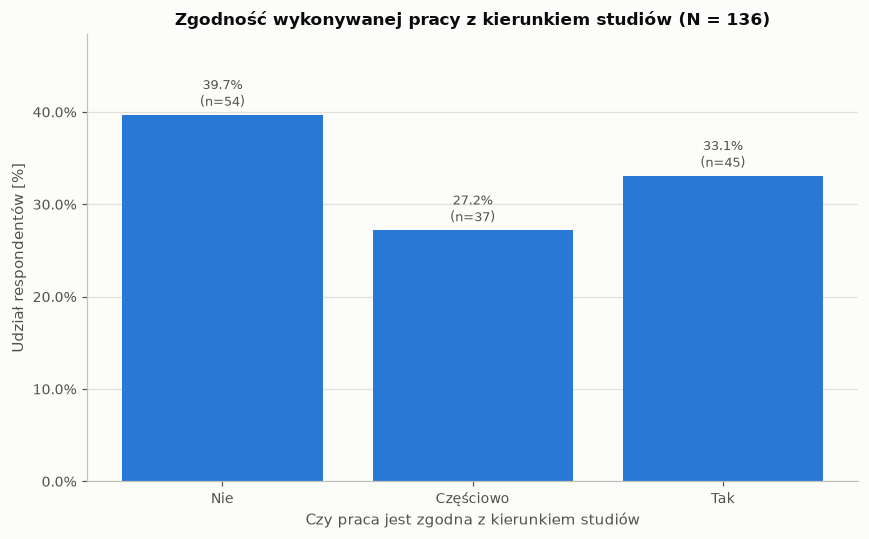

In [11]:
_ = pl.plot_distribution(
    df_pracujacy,
    "praca_zgodna",
    value_labels=WARTOSCI("praca_zgodna"),
    title="Zgodność wykonywanej pracy z kierunkiem studiów",
    xlabel="Czy praca jest zgodna z kierunkiem studiów",
)

Wśród pracujących respondentów największą grupę stanowiły osoby, których wykonywana praca nie była zgodna z kierunkiem studiów (39,7%). Zgodność pracy z kierunkiem deklarowało 33,1% badanych, natomiast 27,2% respondentów oceniło ją jako częściową.

## 1.4 Podsumowanie charakterystyki próby

W badaniu uczestniczyło 396 studentów Politechniki Wrocławskiej reprezentujących wszystkie wydziały uczelni. Najliczniejszą grupę stanowili studenci w wieku 18-20 lat oraz studenci I stopnia z lat 2-4. W próbie przeważali mężczyźni, a najliczniej reprezentowane były wydziały Mechaniczny, Matematyki oraz Informatyki i Telekomunikacji. Większość respondentów mieszkała w wynajmowanych mieszkaniach, a ponad trzy czwarte badanych dojeżdżało na uczelnię w czasie nieprzekraczającym 30 minut. Aktywność zawodową deklarowała około jedna trzecia respondentów, przy czym wśród osób pracujących najczęściej występowała praca stacjonarna, a największa grupa wykonywała pracę niezgodną z kierunkiem studiów.

---

# 2. Dobrostan studentów

W niniejszym rozdziale przedstawiono charakterystykę poziomu dobrostanu badanych studentów. Zaprezentowano rozkłady odpowiedzi dla najważniejszych wskaźników dobrostanu wykorzystanych w dalszych analizach, obejmujących satysfakcję z życia, zdrowie psychiczne i fizyczne oraz poziom stresu i poczucie kontroli.

## 2.1 Satysfakcja z życia

Satysfakcja z życia stanowi jeden z podstawowych wskaźników dobrostanu psychicznego. Respondenci oceniali swoje zadowolenie z życia w pięciostopniowej skali, gdzie 1 oznaczało bardzo niską satysfakcję, a 5 - bardzo wysoką. Rozkład uzyskanych odpowiedzi przedstawiono na rysunku poniżej.

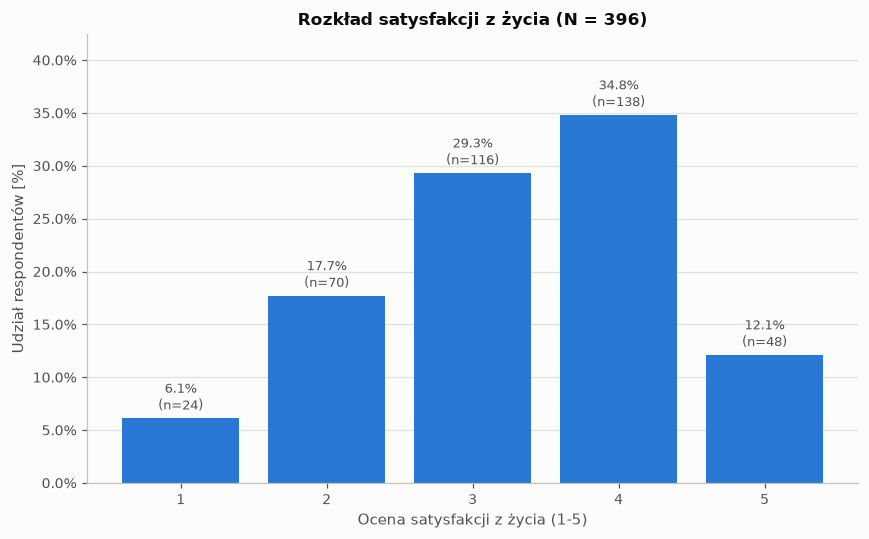

In [12]:
_ = pl.plot_distribution(
    df,
    "sat_zycie",
    title="Rozkład satysfakcji z życia",
    xlabel="Ocena satysfakcji z życia (1-5)",
)

Najwięcej respondentów oceniło swoją satysfakcję z życia na 4 (34,8%). Wysokie oceny (4-5) stanowiły łącznie 46,9% odpowiedzi, natomiast oceny niskie (1-2) 23,8%. Odpowiedź środkową (3) wskazało 29,3% badanych. Rozkład odpowiedzi sugeruje, że większość studentów ocenia swoją satysfakcję z życia jako umiarkowaną lub wysoką.

## 2.2 Zdrowie psychiczne

Kolejnym analizowanym aspektem dobrostanu była subiektywna ocena zdrowia psychicznego. Respondenci oceniali poziom satysfakcji ze swojego zdrowia psychicznego w pięciostopniowej skali, gdzie wyższe wartości oznaczały bardziej pozytywną ocenę.

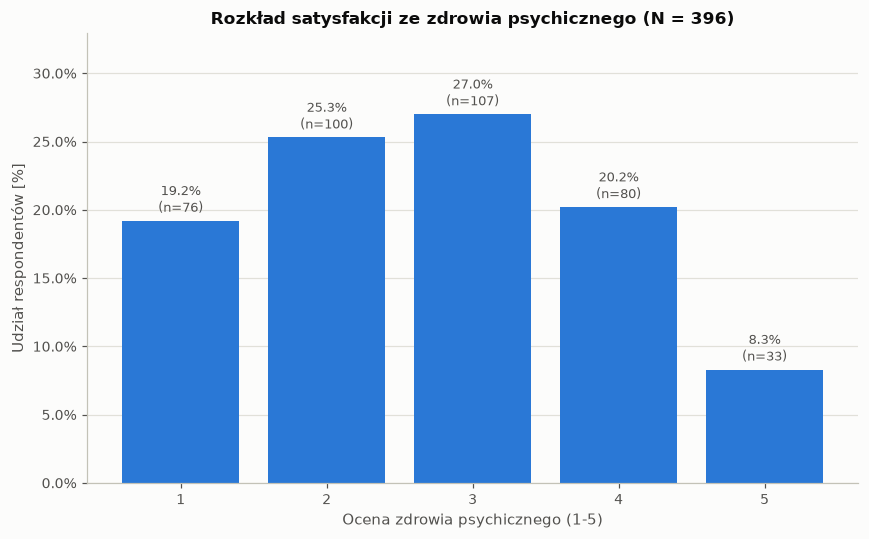

In [13]:
_ = pl.plot_distribution(
    df,
    "sat_zdrowie_psych",
    title="Rozkład satysfakcji ze zdrowia psychicznego",
    xlabel="Ocena zdrowia psychicznego (1-5)",
)

W przeciwieństwie do satysfakcji z życia rozkład ocen zdrowia psychicznego był bardziej zrównoważony. Najczęściej wybieraną odpowiedzią była ocena 3 (27,0%), wskazująca na umiarkowaną satysfakcję. Łącznie wysokie oceny (4-5) stanowiły 28,5% odpowiedzi, natomiast niskie oceny (1-2) 44,5%. Wyniki sugerują, że respondenci oceniali swoje zdrowie psychiczne ostrożniej niż ogólną satysfakcję z życia, a odpowiedzi koncentrowały się wokół wartości środkowych.

## 2.3 Zdrowie fizyczne

W badaniu uwzględniono również ocenę zdrowia fizycznego. Respondenci oceniali poziom satysfakcji ze swojego stanu zdrowia fizycznego w pięciostopniowej skali.

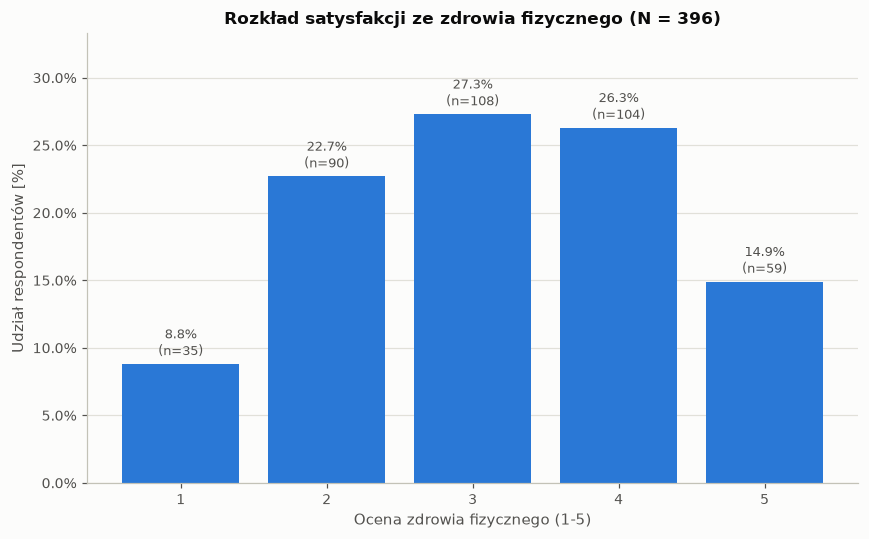

In [14]:
_ = pl.plot_distribution(
    df,
    "sat_zdrowie_fiz",
    title="Rozkład satysfakcji ze zdrowia fizycznego",
    xlabel="Ocena zdrowia fizycznego (1-5)",
)

Najczęściej wybieraną odpowiedzią była ocena 3 (27,3%), jednak niemal równie często wskazywano ocenę 4 (26,3%). Łącznie wysokie oceny (4-5) stanowiły 41,2% odpowiedzi, natomiast niskie oceny (1-2) 31,5%. W porównaniu z oceną zdrowia psychicznego respondenci korzystniej oceniali swoje zdrowie fizyczne, o czym świadczy większy udział odpowiedzi z górnej części skali oraz mniejszy odsetek ocen niskich.

## 2.4 Stres i poczucie kontroli

Oprócz satysfakcji z różnych obszarów życia w badaniu uwzględniono również dwa istotne wskaźniki dobrostanu: poziom odczuwanego stresu oraz poczucie kontroli nad własnym życiem. Obie zmienne oceniano w pięciostopniowej skali, przy czym wyższe wartości oznaczały odpowiednio większy poziom stresu oraz silniejsze poczucie kontroli.

### 2.4.1 Poziom stresu

Respondenci oceniali poziom odczuwanego stresu w pięciostopniowej skali. Rozkład odpowiedzi przedstawiono na poniższym wykresie.

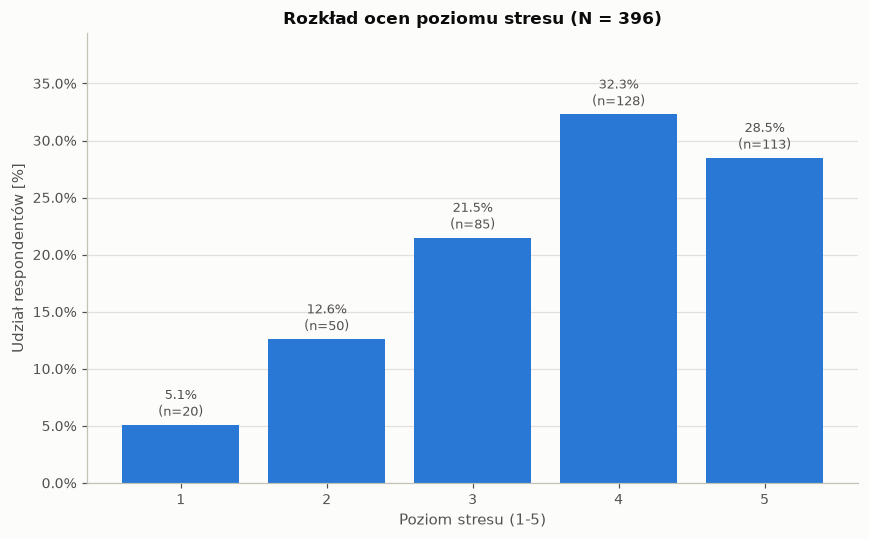

In [15]:
_ = pl.plot_distribution(
    df,
    "poziom_stresu",
    title="Rozkład ocen poziomu stresu",
    xlabel="Poziom stresu (1-5)",
)

Najczęściej wskazywaną odpowiedzią była ocena 4 (32,3%), a niewiele rzadziej wybierano najwyższą ocenę 5 (28,5%). Łącznie wysokie poziomy stresu (4-5) zadeklarowało 60,8% respondentów, podczas gdy niskie poziomy (1-2) wskazało 17,7% badanych. Wyniki sugerują, że w badanej grupie dominował wysoki poziom odczuwanego stresu.

### 2.4.2 Poczucie kontroli

Poczucie kontroli odnosi się do przekonania respondentów o możliwości wpływania na własne życie i podejmowane decyzje. Rozkład odpowiedzi przedstawiono na poniższym wykresie.

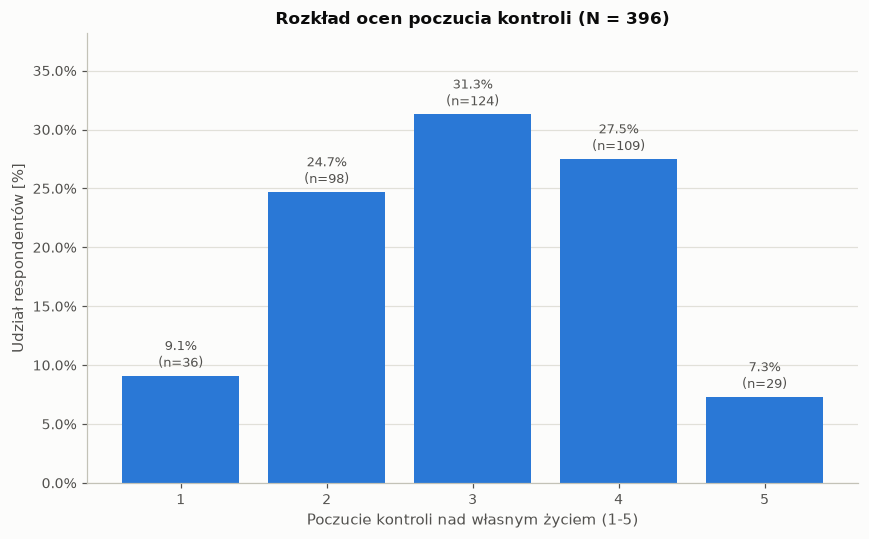

In [16]:
_ = pl.plot_distribution(
    df,
    "poczucie_kontroli",
    title="Rozkład ocen poczucia kontroli",
    xlabel="Poczucie kontroli nad własnym życiem (1-5)",
)

Rozkład odpowiedzi był stosunkowo symetryczny i koncentrował się wokół środkowych wartości skali. Najczęściej wybieraną oceną było 3, co wskazuje na umiarkowane poczucie kontroli nad własnym życiem. Łączny udział wysokich ocen (4-5) wyniósł 34,8%, natomiast ocen niskich (1-2) 33,8%. Otrzymane wyniki sugerują, że w badanej grupie nie dominowały ani bardzo wysokie, ani bardzo niskie oceny poczucia kontroli.

## 2.5 Zależności pomiędzy wskaźnikami dobrostanu

Po przedstawieniu rozkładów poszczególnych wskaźników dobrostanu przeanalizowano zależności pomiędzy nimi za pomocą macierzy korelacji Spearmana. Pozwala ona ocenić, które aspekty dobrostanu współwystępują ze sobą oraz czy zależności mają charakter dodatni czy ujemny.

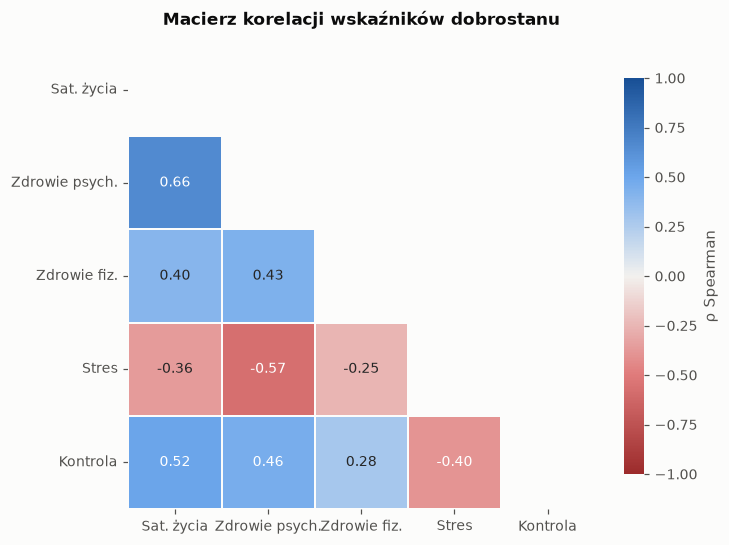

In [17]:
WSKAZNIKI_DOBROSTANU = [
    "sat_zycie",
    "sat_zdrowie_psych",
    "sat_zdrowie_fiz",
    "poziom_stresu",
    "poczucie_kontroli",
]

_ = pl.plot_correlation_heatmap(
    df,
    columns=WSKAZNIKI_DOBROSTANU,
    labels=ETYKIETY,
    title="Macierz korelacji wskaźników dobrostanu",
)

Analizowane wskaźniki dobrostanu wykazują umiarkowane zależności między sobą.

Najsilniejszą dodatnią korelację zaobserwowano pomiędzy satysfakcją z życia a zdrowiem psychicznym (ρ = 0,66), natomiast najsilniejszą zależność ujemną pomiędzy poziomem stresu a zdrowiem psychicznym (ρ = -0,57). Zauważalne są również dodatnie związki poczucia kontroli z satysfakcją z życia (ρ = 0,52) oraz zdrowiem psychicznym (ρ = 0,46).

Otrzymane wyniki wskazują, że poszczególne aspekty dobrostanu są ze sobą powiązane, jednak nie są to zależności na tyle silne, aby traktować je jako tożsame konstrukty.

---

# 3. Ranking czynników dobrostanu

Po przedstawieniu rozkładów podstawowych wskaźników dobrostanu warto sprawdzić, które czynniki wykazują z nimi najsilniejsze związki. W tym rozdziale zestawiono najważniejsze korelacje z trzema kluczowymi wskaźnikami: satysfakcją z życia, zdrowiem psychicznym oraz poziomem stresu. Zależności pomiędzy samymi wskaźnikami dobrostanu przedstawiono w poprzednim rozdziale, dlatego w poniższych rankingach skupiono się na pozostałych analizowanych zmiennych. Ranking pełni rolę przeglądu najistotniejszych zależności i stanowi wprowadzenie do kolejnych rozdziałów, w których poszczególne obszary zostaną omówione bardziej szczegółowo.

## 3.1 Czynniki związane z satysfakcją z życia

W pierwszej kolejności przeanalizowano zmienne najsilniej powiązane z satysfakcją z życia. Zestawiono współczynniki korelacji Spearmana między satysfakcją z życia a pozostałymi zmiennymi liczbowymi. Wartości dodatnie oznaczają, że wyższy poziom danej cechy współwystępuje z większą satysfakcją, ujemne — zależność odwrotną.

Korekta Benjaminiego-Hochberga została policzona na wszystkich wykonanych porównaniach, a dopiero potem wybrano dziesięć najsilniejszych zależności. Zmienne, które nie przeszły korekty, są na wykresie wyszarzone i oznaczone gwiazdką. Z rankingu wyłączono pozostałe wskaźniki dobrostanu, omówione w poprzednim rozdziale, oraz ogólny wskaźnik satysfakcji, który zawiera satysfakcję z życia jako składową.

Korekta FDR objęła 31 porównań; poniżej 10 najsilniejszych.


,Zmienna,N,ρ,p (FDR),Istotna?
0,Satysfakcja ze studiów,396,"0,501","<0,001",Tak
1,Satysfakcja z relacji,396,"0,467","<0,001",Tak
2,Satysfakcja finansowa,396,"0,391","<0,001",Tak
3,Poziom wsparcia społecznego,396,"0,388","<0,001",Tak
4,Satysfakcja z czasu wolnego,396,"0,355","<0,001",Tak
5,Satysfakcja z relacji rodzinnych,396,"0,305","<0,001",Tak
6,Problemy ze snem,396,"-0,280","<0,001",Tak
7,Częstość spotkań ze znajomymi,396,"0,263","<0,001",Tak
8,Ocena sytuacji finansowej,396,"0,249","<0,001",Tak
9,Aktywność fizyczna [h/tydzień],396,"0,234","<0,001",Tak


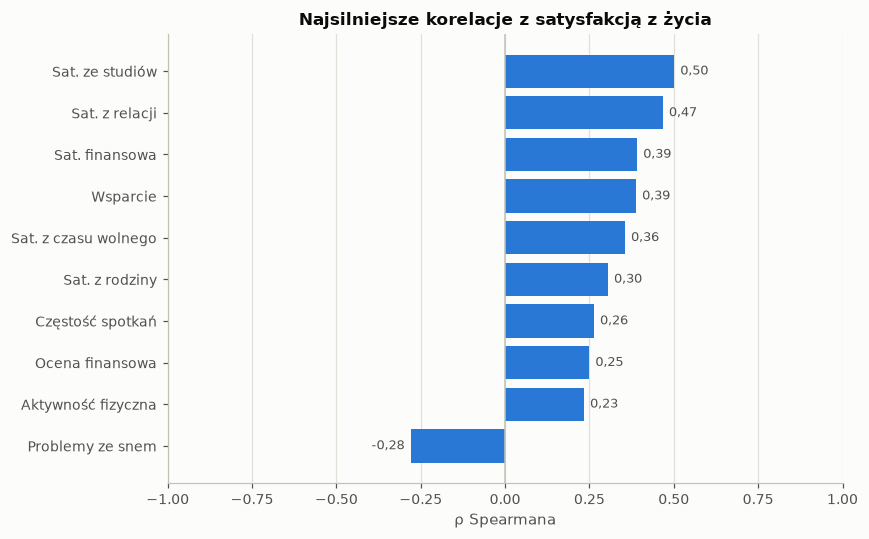

In [18]:
ranking = st.spearman_ranking(
    df,
    target="sat_zycie",
    exclude=WSKAZNIKI_DOBROSTANU + ["sat_srednia"],
    top_n=10,
)

print(
    f"Korekta FDR objęła {ranking['n_rodziny'].iloc[0]} porównań; "
    f"poniżej 10 najsilniejszych."
)
display(rp.ranking(ranking))

_ = pl.plot_correlation_ranking(
    ranking,
    labels=ETYKIETY,
    title="Najsilniejsze korelacje z satysfakcją z życia",
)

Spośród analizowanych czynników najsilniejsze związki z satysfakcją z życia wykazywały obszary związane z codziennym funkcjonowaniem i jakością życia studenckiego. Szczególnie widoczne były zależności dotyczące satysfakcji ze studiów, relacji interpersonalnych oraz sytuacji finansowej. Słabsze, lecz nadal dodatnie korelacje odnotowano również dla aktywności fizycznej i częstotliwości spotkań z innymi osobami. Jedyną zmienną o wyraźniejszym związku ujemnym były problemy ze snem, co sugeruje, że częstsze ich występowanie współwystępowało z niższą satysfakcją z życia.

## 3.2 Czynniki związane ze zdrowiem psychicznym

W analogiczny sposób przeanalizowano zmienne najsilniej powiązane z oceną zdrowia psychicznego. Pozwala to określić, które aspekty życia studentów współwystępowały z lepszą lub gorszą oceną własnego zdrowia psychicznego.

Korekta FDR objęła 31 porównań; poniżej 10 najsilniejszych.


,Zmienna,N,ρ,p (FDR),Istotna?
0,Satysfakcja z czasu wolnego,396,"0,468","<0,001",Tak
1,Satysfakcja ze studiów,396,"0,450","<0,001",Tak
2,Satysfakcja z relacji,396,"0,432","<0,001",Tak
3,Poziom wsparcia społecznego,396,"0,342","<0,001",Tak
4,Satysfakcja finansowa,396,"0,327","<0,001",Tak
5,Problemy ze snem,396,"-0,323","<0,001",Tak
6,Satysfakcja z relacji rodzinnych,396,"0,284","<0,001",Tak
7,Aktywność fizyczna [h/tydzień],396,"0,231","<0,001",Tak
8,Długość snu w dni robocze [h],396,"0,215","<0,001",Tak
9,Ocena sytuacji finansowej,396,"0,204","<0,001",Tak


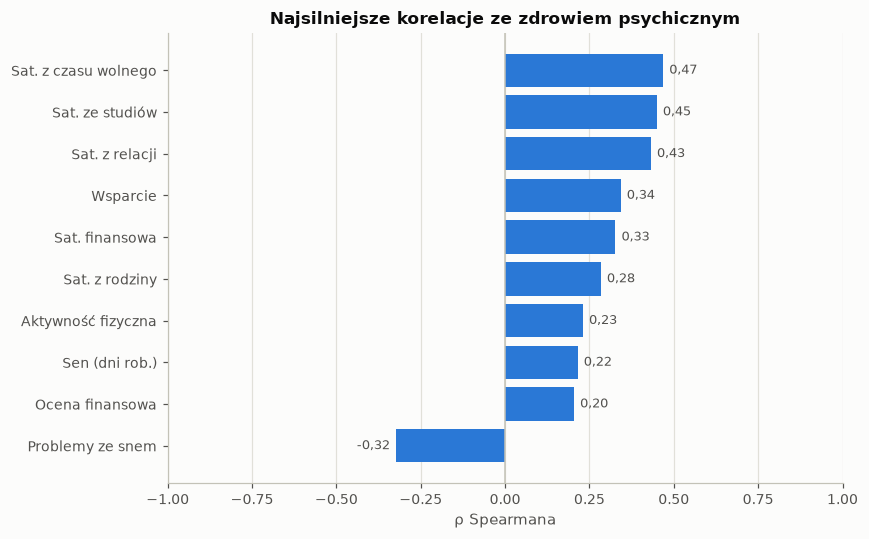

In [19]:
ranking = st.spearman_ranking(
    df,
    target="sat_zdrowie_psych",
    exclude=WSKAZNIKI_DOBROSTANU + ["sat_srednia"],
    top_n=10,
)

print(
    f"Korekta FDR objęła {ranking['n_rodziny'].iloc[0]} porównań; "
    f"poniżej 10 najsilniejszych."
)
display(rp.ranking(ranking))

_ = pl.plot_correlation_ranking(
    ranking,
    labels=ETYKIETY,
    title="Najsilniejsze korelacje ze zdrowiem psychicznym",
)

Ranking wskazuje, że lepsza ocena zdrowia psychicznego współwystępowała przede wszystkim z większą satysfakcją z różnych obszarów życia, zwłaszcza z czasu wolnego, studiów i relacji interpersonalnych. Dodatnie zależności zaobserwowano również dla poziomu wsparcia społecznego, aktywności fizycznej oraz długości snu w dni robocze. Jednocześnie częstsze problemy ze snem współwystępowały z niższą oceną zdrowia psychicznego, co stanowiło najsilniejszą zależność ujemną w analizowanym zestawieniu.

## 3.3 Czynniki związane z poziomem stresu

Ostatni ranking dotyczy czynników powiązanych z poziomem odczuwanego stresu. W przeciwieństwie do poprzednich analiz, dodatnie wartości współczynnika oznaczają współwystępowanie z wyższym poziomem stresu, natomiast wartości ujemne wskazują na zależność z jego niższym poziomem.

Korekta FDR objęła 31 porównań; poniżej 10 najsilniejszych.


,Zmienna,N,ρ,p (FDR),Istotna?
0,Satysfakcja z czasu wolnego,396,"-0,394","<0,001",Tak
1,Problemy ze snem,396,"0,345","<0,001",Tak
2,Długość snu w dni robocze [h],396,"-0,270","<0,001",Tak
3,Satysfakcja ze studiów,396,"-0,254","<0,001",Tak
4,Satysfakcja finansowa,396,"-0,222","<0,001",Tak
5,Social jetlag [h],396,"0,207","<0,001",Tak
6,Liczba godzin pracy w tygodniu,136,"0,204","0,036",Tak
7,Satysfakcja z relacji rodzinnych,396,"-0,192","<0,001",Tak
8,Poziom wsparcia społecznego,396,"-0,191","<0,001",Tak
9,Aktywność fizyczna [h/tydzień],396,"-0,181","<0,001",Tak


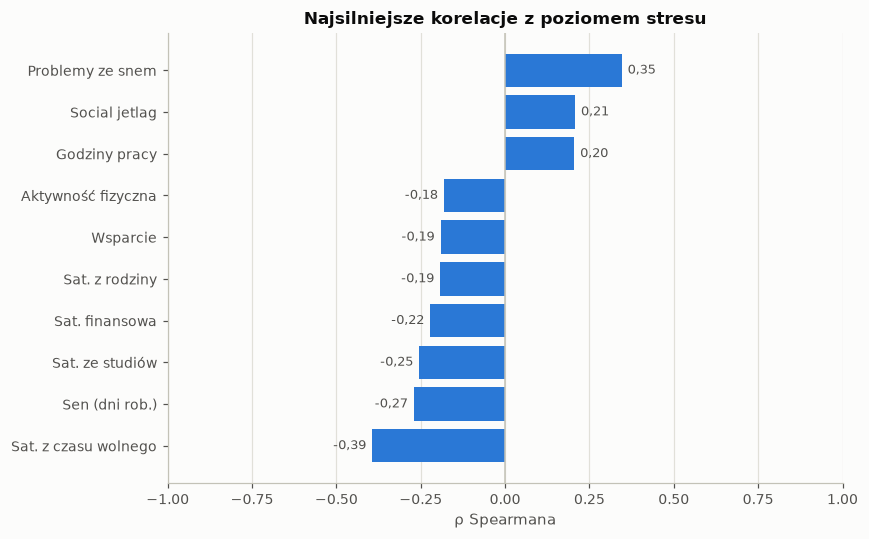

In [20]:
ranking = st.spearman_ranking(
    df,
    target="poziom_stresu",
    exclude=WSKAZNIKI_DOBROSTANU + ["sat_srednia"],
    top_n=10,
)

print(
    f"Korekta FDR objęła {ranking['n_rodziny'].iloc[0]} porównań; "
    f"poniżej 10 najsilniejszych."
)
display(rp.ranking(ranking))

_ = pl.plot_correlation_ranking(
    ranking,
    labels=ETYKIETY,
    title="Najsilniejsze korelacje z poziomem stresu",
)

W przeciwieństwie do satysfakcji z życia i zdrowia psychicznego poziom stresu nie wykazywał równie silnych zależności z analizowanymi zmiennymi. Najwyższą dodatnią korelację odnotowano dla problemów ze snem, co wskazuje, że częstsze ich występowanie współwystępowało z wyższym poziomem odczuwanego stresu. Dodatnie, choć słabsze zależności zaobserwowano również dla różnicy czasu snu pomiędzy dniami roboczymi a weekendem oraz większej liczby godzin przeznaczanych na pracę. Z kolei niższy poziom stresu współwystępował przede wszystkim z większą satysfakcją z czasu wolnego, dłuższym snem w dni robocze oraz wyższą satysfakcją ze studiów i sytuacji finansowej.

---

# 4. Sen

Sen jest jednym z najczęściej wskazywanych czynników wpływających na dobrostan psychiczny i funkcjonowanie człowieka. W tej części przeanalizowano zarówno długość snu w dni robocze, regularność rytmu snu, jak i występowanie problemów ze snem. Celem analizy było sprawdzenie, które z tych aspektów najsilniej wiążą się z poziomem stresu, zdrowiem psychicznym oraz satysfakcją z różnych obszarów życia.

## 4.1 Długość snu w badanej próbie

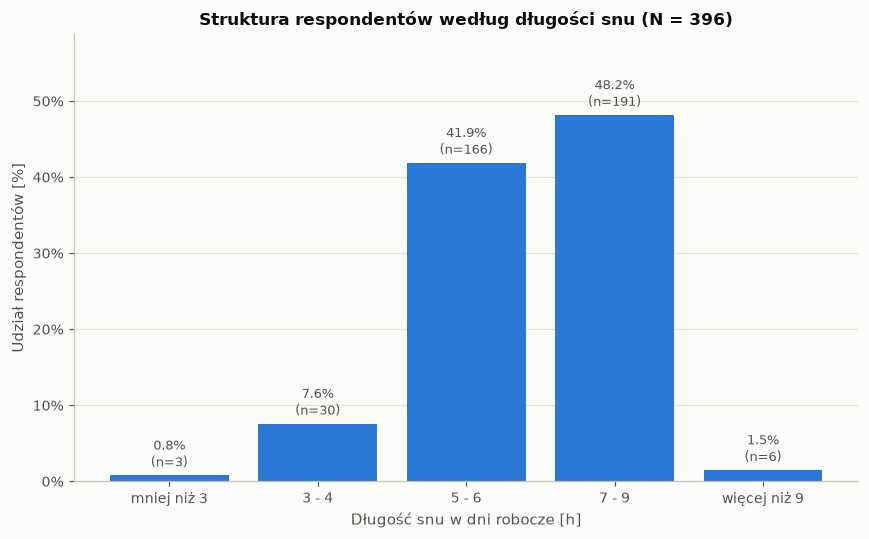

In [21]:
_ = pl.plot_distribution(
    df,
    "sen_h_dni_robocze",
    value_labels=WARTOSCI("sen_h_dni_robocze"),
    title="Struktura respondentów według długości snu",
    xlabel="Długość snu w dni robocze [h]",
)

# Skrajne kategorie są zbyt nieliczne (N = 3 i N = 6), by czytać z nich rozkład
# odpowiedzi. Wyłączamy je z wykresów porównawczych, ale nie z korelacji,
# które korzystają z uporządkowania wszystkich obserwacji.
df_sen_typowy = df[df["sen_h_dni_robocze"].between(3.5, 8)]

Przed analizą zależności sprawdzono liczebność poszczególnych kategorii długości snu. Zdecydowana większość respondentów (97,7%) deklarowała sen trwający od 3 do 9 godzin. Respondenci deklarujący sen krótszy niż 3 godziny (N = 3) oraz dłuższy niż 9 godzin (N = 6) byli bardzo nieliczni. Ze względu na niewystarczającą liczebność tych dwóch skrajnych kategorii zostały one wyłączone z dalszych analiz porównawczych dotyczących długości snu. Korelacje Spearmana obliczano natomiast dla pełnej próby, ponieważ wykorzystują one uporządkowanie wszystkich obserwacji i nie wymagają porównywania licznych grup.

## 4.2 Sen a stres

Pierwszym analizowanym obszarem jest związek długości snu w dni robocze z poziomem odczuwanego stresu. Sen jest jednym z podstawowych czynników wpływających na regenerację organizmu, dlatego sprawdzono, czy osoby śpiące dłużej deklarują również niższy poziom stresu. Zależność oceniono za pomocą współczynnika korelacji rang Spearmana.

,Zmienna X,Zmienna Y,N,ρ,p
0,Długość snu w dni robocze [h],Poziom stresu,396,"-0,270","<0,001"


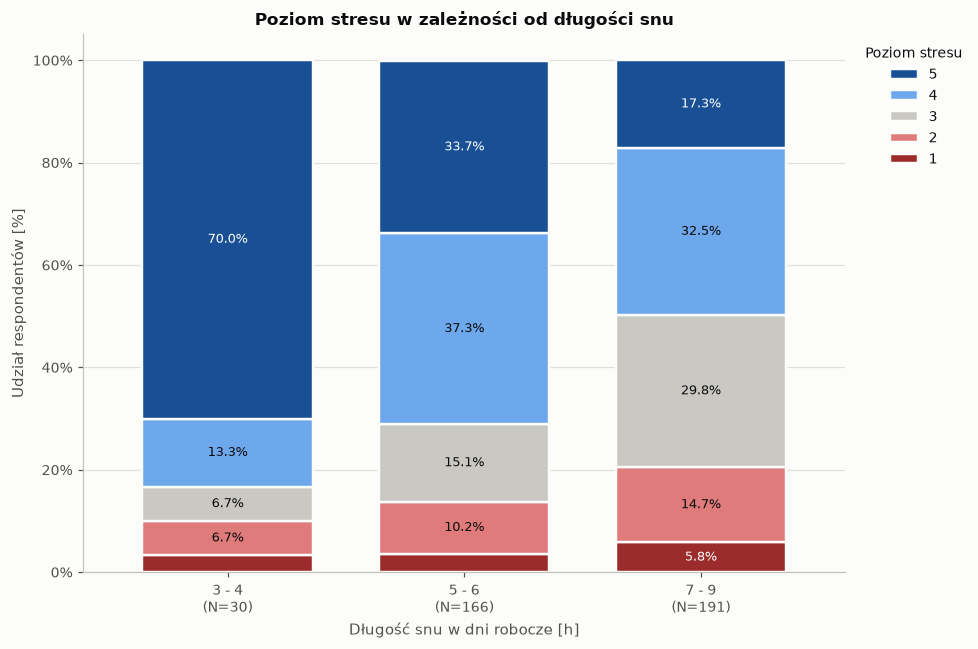

In [22]:
wynik = st.run_spearman(df, x="sen_h_dni_robocze", y="poziom_stresu")
display(rp.spearman(wynik))

_ = pl.plot_stacked_likert(
    df_sen_typowy,
    x="sen_h_dni_robocze",
    y="poziom_stresu",
    x_labels=WARTOSCI("sen_h_dni_robocze"),
    title="Poziom stresu w zależności od długości snu",
    xlabel="Długość snu w dni robocze [h]",
    legend_title="Poziom stresu",
)

Długość snu w dni robocze wykazywała istotną, lecz słabą ujemną korelację z poziomem stresu (ρ = -0,27; p < 0,001), co oznacza, że osoby śpiące dłużej przeciętnie deklarowały niższy poziom odczuwanego stresu. Wykres rozkładu odpowiedzi pokazuje wyraźny trend zgodny z wynikiem analizy korelacyjnej. Wraz ze wzrostem długości snu maleje odsetek respondentów deklarujących najwyższy poziom stresu (ocena 5), a rośnie udział odpowiedzi wskazujących na niższy poziom stresu. Największa zmiana widoczna jest pomiędzy grupami śpiącymi 3-4 godziny a 5-6 godzin, natomiast w grupie śpiącej 7-9 godzin trend ten utrzymuje się i odsetek osób deklarujących najwyższy poziom stresu jest jeszcze niższy.

## 4.3 Sen a zdrowie psychiczne

W kolejnym kroku sprawdzono, czy długość snu w dni robocze wiąże się z oceną zdrowia psychicznego.

,Zmienna X,Zmienna Y,N,ρ,p
0,Długość snu w dni robocze [h],Zdrowie psychiczne,396,"0,215","<0,001"


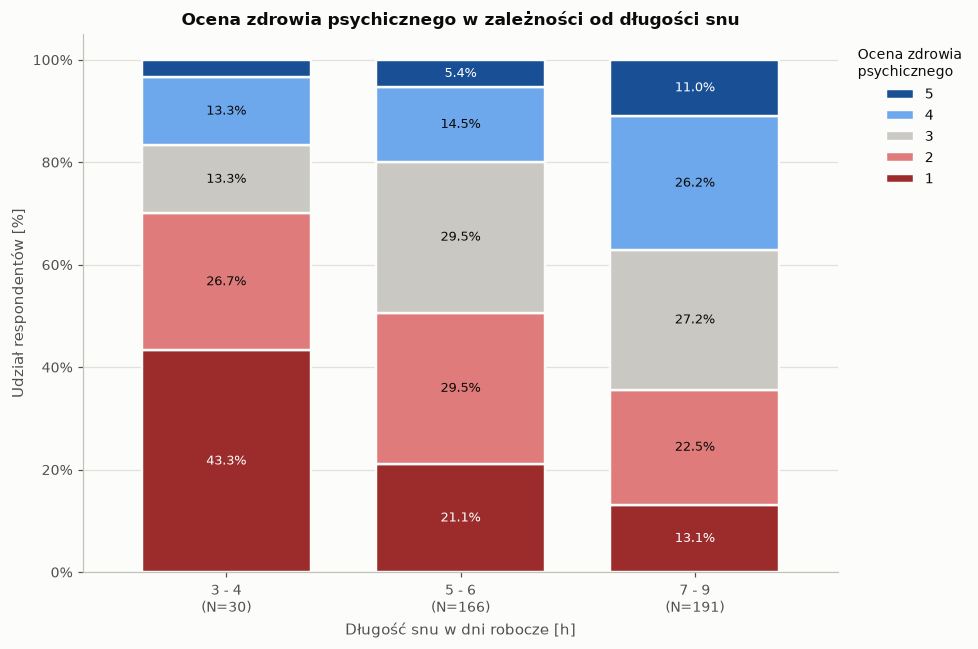

In [23]:
wynik = st.run_spearman(df, x="sen_h_dni_robocze", y="sat_zdrowie_psych")
display(rp.spearman(wynik))

_ = pl.plot_stacked_likert(
    df_sen_typowy,
    x="sen_h_dni_robocze",
    y="sat_zdrowie_psych",
    x_labels=WARTOSCI("sen_h_dni_robocze"),
    title="Ocena zdrowia psychicznego w zależności od długości snu",
    xlabel="Długość snu w dni robocze [h]",
    legend_title="Ocena zdrowia\npsychicznego",
)

Długość snu w dni robocze wykazywała istotną, lecz słabą dodatnią korelację z oceną zdrowia psychicznego (ρ = 0,22; p < 0,001). Oznacza to, że osoby deklarujące dłuższy sen przeciętnie lepiej oceniały swoje zdrowie psychiczne. Rozkład odpowiedzi jest zgodny z tym wynikiem - wraz ze wzrostem długości snu maleje udział najniższych ocen (1-2), natomiast rośnie odsetek odpowiedzi wskazujących na dobrą ocenę zdrowia psychicznego (4-5). Zależność ta jest widoczna, jednak jej siła pozostaje niewielka, co znajduje odzwierciedlenie w wartości współczynnika korelacji.

## 4.4 Sen a zdrowie fizyczne

W tej części przeanalizowano zależność pomiędzy długością snu w dni robocze a samooceną zdrowia fizycznego.

,Zmienna X,Zmienna Y,N,ρ,p
0,Długość snu w dni robocze [h],Zdrowie fizyczne,396,"0,111","0,027"


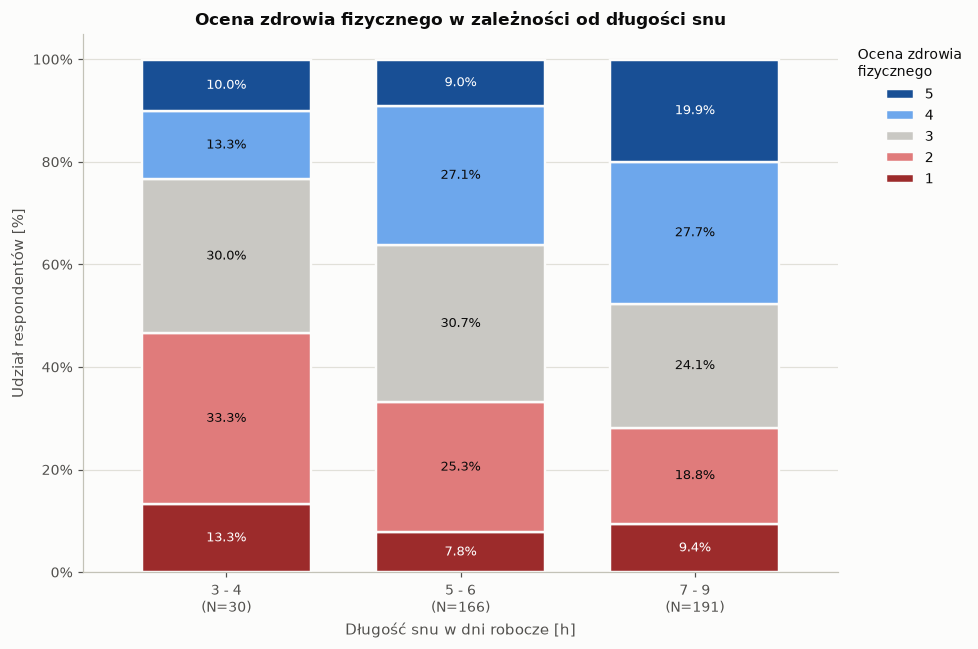

In [24]:
wynik = st.run_spearman(df, x="sen_h_dni_robocze", y="sat_zdrowie_fiz")
display(rp.spearman(wynik))

_ = pl.plot_stacked_likert(
    df_sen_typowy,
    x="sen_h_dni_robocze",
    y="sat_zdrowie_fiz",
    x_labels=WARTOSCI("sen_h_dni_robocze"),
    title="Ocena zdrowia fizycznego w zależności od długości snu",
    xlabel="Długość snu w dni robocze [h]",
    legend_title="Ocena zdrowia\nfizycznego",
)

Długość snu w dni robocze wykazywała istotną, lecz bardzo słabą dodatnią korelację z oceną zdrowia fizycznego (ρ = 0,11; p = 0,027). Oznacza to, że osoby deklarujące dłuższy sen nieco częściej oceniały swoje zdrowie fizyczne wyżej, jednak siła tej zależności była niewielka. Rozkład odpowiedzi wskazuje na subtelny trend zgodny z wynikiem analizy korelacyjnej - wraz z wydłużaniem czasu snu maleje udział najniższych ocen, a nieznacznie rośnie odsetek odpowiedzi 4 i 5. Niewielka wartość współczynnika korelacji sugeruje jednak, że długość snu wyjaśnia jedynie niewielką część zróżnicowania ocen zdrowia fizycznego.

## 4.5 Sen a satysfakcja z życia

W tej części przeanalizowano zależność pomiędzy długością snu w dni robocze a satysfakcją z życia.

,Zmienna X,Zmienna Y,N,ρ,p
0,Długość snu w dni robocze [h],Satysfakcja z życia,396,"0,101","0,045"


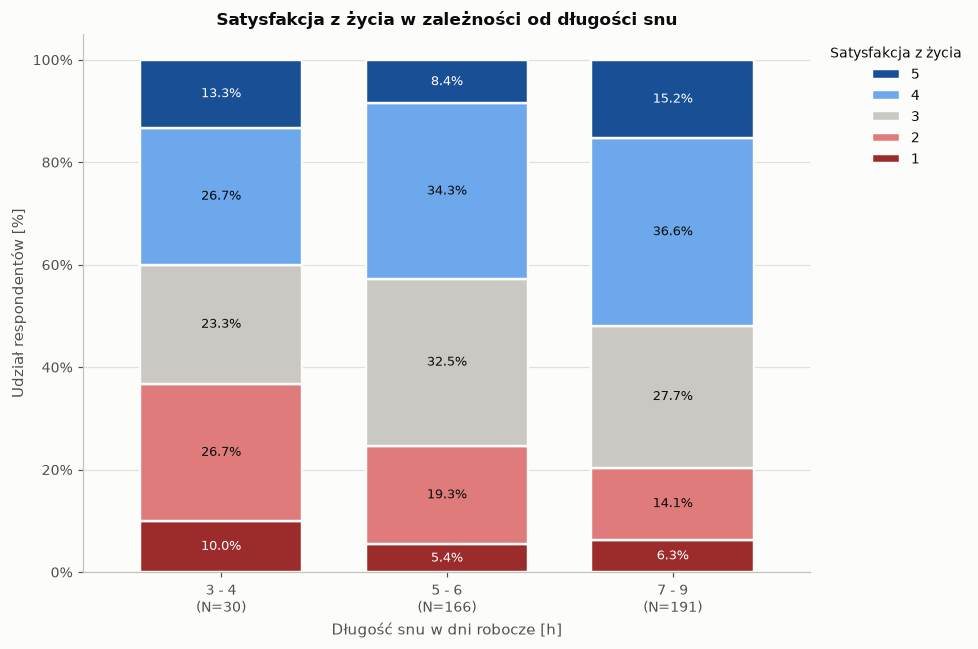

In [25]:
wynik = st.run_spearman(df, x="sen_h_dni_robocze", y="sat_zycie")
display(rp.spearman(wynik))

_ = pl.plot_stacked_likert(
    df_sen_typowy,
    x="sen_h_dni_robocze",
    y="sat_zycie",
    x_labels=WARTOSCI("sen_h_dni_robocze"),
    title="Satysfakcja z życia w zależności od długości snu",
    xlabel="Długość snu w dni robocze [h]",
    legend_title="Satysfakcja z życia",
)

Długość snu w dni robocze wykazywała istotną, lecz bardzo słabą dodatnią korelację z satysfakcją z życia (ρ = 0,10; p = 0,045). Oznacza to, że osoby śpiące dłużej nieco częściej deklarowały wyższą satysfakcję z życia, jednak siła tej zależności była niewielka. Rozkład odpowiedzi wskazuje na subtelny trend wzrostu udziału wyższych ocen satysfakcji z życia wraz z wydłużaniem czasu snu, choć różnice pomiędzy poszczególnymi grupami nie były wyraźne. Ze względu na bardzo małą liczebność grup śpiących mniej niż 3 godziny oraz więcej niż 9 godzin uzyskane dla nich wyniki należy interpretować ostrożnie.

## 4.6 Sen a satysfakcja ogólna

Oprócz analizy poszczególnych obszarów dobrostanu sprawdzono również zależność pomiędzy długością snu w dni robocze a ogólnym wskaźnikiem satysfakcji, wyznaczonym jako średnia z ocen poszczególnych obszarów życia.

,Zmienna X,Zmienna Y,N,ρ,p
0,Długość snu w dni robocze [h],Ogólny wskaźnik satysfakcji,396,"0,203","<0,001"


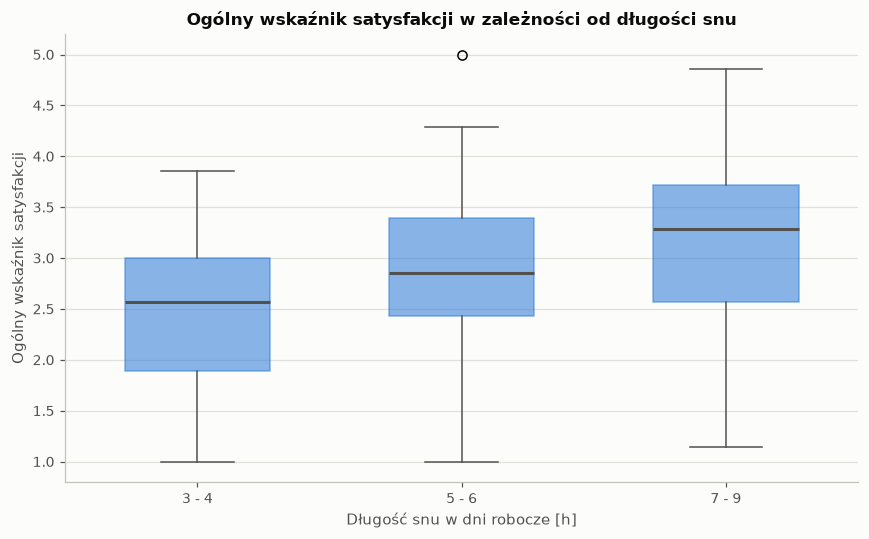

In [26]:
wynik = st.run_spearman(df, x="sen_h_dni_robocze", y="sat_srednia")
display(rp.spearman(wynik))

_ = pl.plot_box(
    df_sen_typowy,
    x="sen_h_dni_robocze",
    y="sat_srednia",
    x_labels=WARTOSCI("sen_h_dni_robocze"),
    title="Ogólny wskaźnik satysfakcji w zależności od długości snu",
    xlabel="Długość snu w dni robocze [h]",
    ylabel="Ogólny wskaźnik satysfakcji",
)

Długość snu w dni robocze wykazywała istotną, lecz słabą dodatnią korelację z ogólnym wskaźnikiem satysfakcji (ρ = 0,20; p < 0,001). Oznacza to, że osoby deklarujące dłuższy sen przeciętnie osiągały wyższe wartości zbiorczego wskaźnika satysfakcji. Wykres pudełkowy potwierdza tę zależność - mediana ogólnego wskaźnika satysfakcji stopniowo wzrasta wraz z długością snu, a rozkład wyników dla osób śpiących 7-9 godzin jest przesunięty ku wyższym wartościom względem pozostałych grup. Jednocześnie widoczne nakładanie się rozkładów wskazuje, że długość snu stanowi jedynie jeden z czynników związanych z poziomem ogólnej satysfakcji.

## 4.7 Sen w dni robocze a weekendy

Dotychczasowe analizy dotyczyły długości snu w dni robocze, która w największym stopniu odzwierciedla codzienny rytm funkcjonowania studentów. W kolejnym kroku porównano deklarowaną długość snu w dni robocze i w weekendy, aby sprawdzić, czy badani wydłużają sen w dniach wolnych od obowiązków oraz przygotować podstawę do analizy regularności rytmu snu.

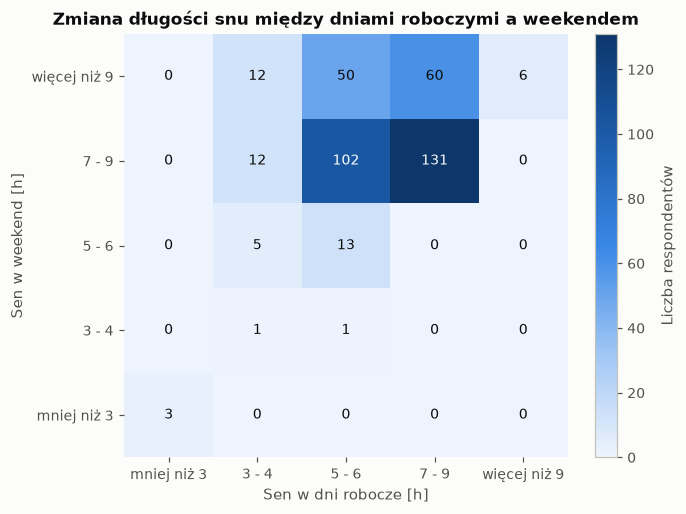

In [27]:
_ = pl.plot_transition_heatmap(
    df,
    x="sen_h_dni_robocze",
    y="sen_h_weekend",
    x_labels=WARTOSCI("sen_h_dni_robocze"),
    y_labels=WARTOSCI("sen_h_weekend"),
    title="Zmiana długości snu między dniami roboczymi a weekendem",
    xlabel="Sen w dni robocze [h]",
    ylabel="Sen w weekend [h]",
)

Większość respondentów deklarowała taką samą lub dłuższą długość snu w weekendy niż w dni robocze. Najliczniejsze były osoby śpiące 7-9 godzin zarówno w tygodniu, jak i w weekendy (131 osób), a częstym zjawiskiem było również wydłużanie snu z 5-6 do 7-9 godzin (102 osoby). Widoczne są także przejścia z 7-9 godzin do ponad 9 godzin snu w weekendy (60 osób), co wskazuje, że część badanych przeznacza weekend na dodatkowy odpoczynek. Jednocześnie przypadki skracania snu w weekendy występowały zdecydowanie rzadziej.

## 4.8 Social jetlag

Oprócz samej długości snu istotna może być również jego regularność. W tym celu wykorzystano wskaźnik social jetlag, opisujący różnicę pomiędzy deklarowaną długością snu w dni robocze i weekendy. W analizie przyjęto wartość bezwzględną tej różnicy, dzięki czemu wyższe wartości oznaczają większą zmianę długości snu pomiędzy obiema częściami tygodnia, niezależnie od kierunku tej zmiany.

Ponieważ respondenci wybierali przedziały długości snu, do obliczenia wskaźnika wykorzystano ich wartości reprezentatywne: 2 godziny dla kategorii "mniej niż 3 godziny", 3,5 godziny dla "3-4", 5,5 godziny dla "5-6", 8 godzin dla "7-9" oraz 10 godzin dla "więcej niż 9 godzin". Oznacza to, że wskaźnik social jetlag stanowi przybliżenie rzeczywistej różnicy długości snu i powinien być interpretowany jako miara względna, a nie dokładna liczba godzin.

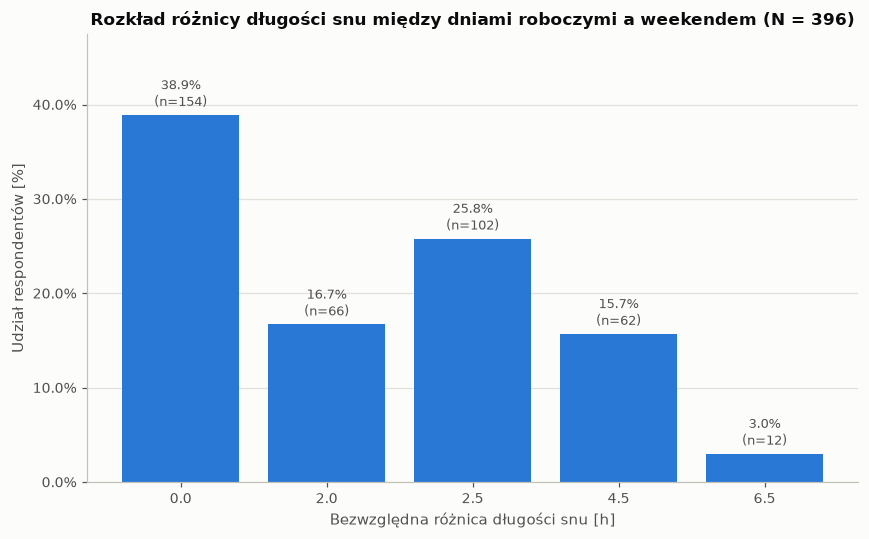

In [28]:
_ = pl.plot_distribution(
    df,
    "social_jetlag",
    title="Rozkład różnicy długości snu między dniami roboczymi a weekendem",
    xlabel="Bezwzględna różnica długości snu [h]",
)

Rozkład wskaźnika social jetlag pokazuje, że największa grupa respondentów (38,9%) deklarowała taką samą długość snu w dni robocze i weekendy. U pozostałych badanych najczęściej występowała różnica do 2,5 godziny (42,5%), natomiast większe odchylenia obserwowano coraz rzadziej. Największa zarejestrowana różnica (6,5 godziny) dotyczyła jedynie 3,0% respondentów. Oznacza to, że choć zmiana długości snu pomiędzy tygodniem a weekendem była zjawiskiem częstym, w większości przypadków nie przekraczała kilku godzin.

Korekta FDR objęła 33 porównań.


,Zmienna,N,ρ,p (FDR),Istotna?
0,Problemy ze snem,396,"0,291","<0,001",Tak
1,Ocena jakości diety,396,"-0,239","<0,001",Tak
2,Poziom stresu,396,"0,207","<0,001",Tak
3,Liczba godzin pracy w tygodniu,136,"0,197","0,064",Nie
4,Satysfakcja z czasu wolnego,396,"-0,180","0,002",Tak


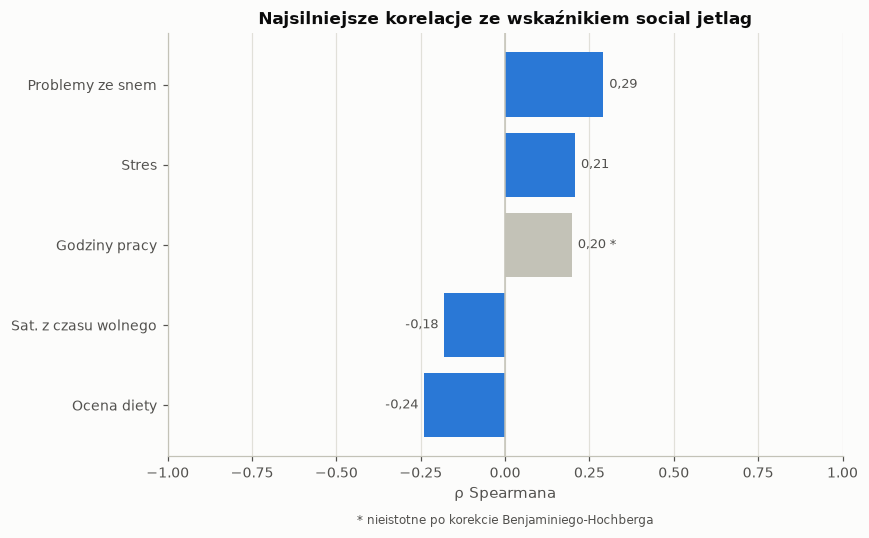

In [29]:
ranking_jetlag = st.spearman_ranking(
    df,
    target="social_jetlag",
    exclude=["sen_h_dni_robocze", "sen_h_weekend", "sat_srednia"],
    top_n=5,
)

print(f"Korekta FDR objęła {ranking_jetlag['n_rodziny'].iloc[0]} porównań.")
display(rp.ranking(ranking_jetlag))

_ = pl.plot_correlation_ranking(
    ranking_jetlag,
    labels=ETYKIETY,
    title="Najsilniejsze korelacje ze wskaźnikiem social jetlag",
)

Wskaźnik social jetlag nie wykazywał silnych zależności z analizowanymi zmiennymi. Najwyższą dodatnią korelację zaobserwowano z problemami ze snem (ρ = 0,291), co sugeruje, że większa różnica długości snu między dniami roboczymi a weekendem współwystępowała z częstszym zgłaszaniem problemów ze snem. Istotne okazały się również zależności z poziomem stresu (ρ = 0,207), oceną diety (ρ = -0,239) oraz satysfakcją z czasu wolnego (ρ = -0,180).

Korelacja z liczbą godzin pracy (ρ = 0,197) **nie przetrwała korekty Benjaminiego-Hochberga** liczonej na pełnej rodzinie 34 porównań (p = 0,060) i została na wykresie oznaczona jako nieistotna. Wszystkie zaobserwowane zależności mają słabą siłę.

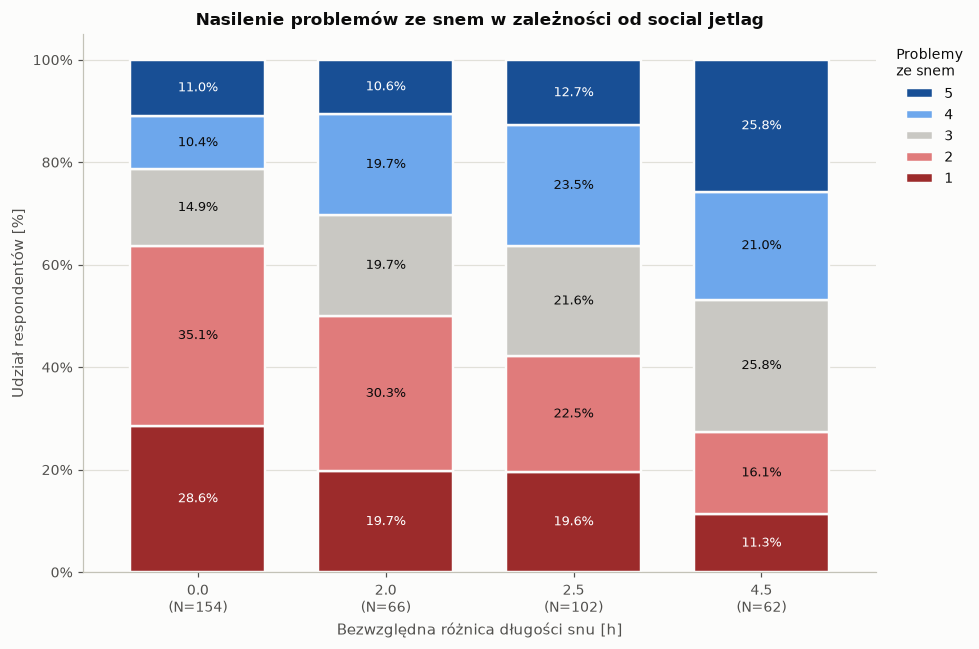

In [30]:
# Różnica 6,5 h wystąpiła u 12 osób — za mało, by czytać z niej rozkład.
df_jetlag = df[df["social_jetlag"] != 6.5]

_ = pl.plot_stacked_likert(
    df_jetlag,
    x="social_jetlag",
    y="problemy_sen",
    title="Nasilenie problemów ze snem w zależności od social jetlag",
    xlabel="Bezwzględna różnica długości snu [h]",
    legend_title="Problemy\nze snem",
)

Wraz ze wzrostem różnicy długości snu pomiędzy dniami roboczymi a weekendem widoczny jest stopniowy spadek odsetka osób deklarujących niewielkie problemy ze snem (odpowiedzi 1-2) oraz wzrost udziału odpowiedzi wskazujących na częstsze problemy (4-5). Kategoria odpowiadająca 6,5 godziny różnicy snu (N = 12) została pominięta na wykresie ze względu na bardzo małą liczebność i brak możliwości wiarygodnej interpretacji rozkładu odpowiedzi, jednak została uwzględniona przy obliczaniu współczynnika korelacji.

## 4.9 Problemy ze snem

W tej części sprawdzono, czy deklarowane problemy ze snem wiążą się z poziomem stresu oraz oceną zdrowia psychicznego. W celu porównania respondentów o wyraźnie odmiennym nasileniu problemów ze snem odpowiedzi 1-2 zakwalifikowano do grupy osób deklarujących niewielkie problemy ze snem, natomiast odpowiedzi 4-5 do grupy osób deklarujących nasilone problemy ze snem. Odpowiedzi środkowe (3) pominięto, aby porównać dwie jednoznacznie odrębne grupy respondentów. Do oceny różnic pomiędzy nimi zastosowano nieparametryczny test U Manna-Whitneya.

In [31]:
# Porównujemy krańce skali: odpowiedzi 1-2 wobec 4-5. Środkową odpowiedź (3)
# pomijamy, żeby zestawić dwie jednoznacznie odmienne grupy respondentów.
df_sen_problemy = df[df["problemy_sen"].isin([1, 2, 4, 5])].copy()

df_sen_problemy["grupa_problemow_sen"] = np.where(
    df_sen_problemy["problemy_sen"].isin([1, 2]),
    "Niewielkie problemy",
    "Nasilone problemy",
)

In [32]:
display(rp.group_sizes(df_sen_problemy["grupa_problemow_sen"]))

,Liczebność
Grupa,
Niewielkie problemy,192
Nasilone problemy,129


### 4.9.1 Problemy ze snem a poziom stresu

W pierwszej analizie sprawdzono, czy poziom odczuwanego stresu różni się pomiędzy osobami deklarującymi niewielkie oraz nasilone problemy ze snem.

,Grupa 1,Grupa 2,N₁,N₂,Mediana 1,Mediana 2,U,p,r_rb,Siła efektu
0,Nasilone problemy,Niewielkie problemy,129,192,"4,0","3,0","17681,5","<0,001","0,428",umiarkowany


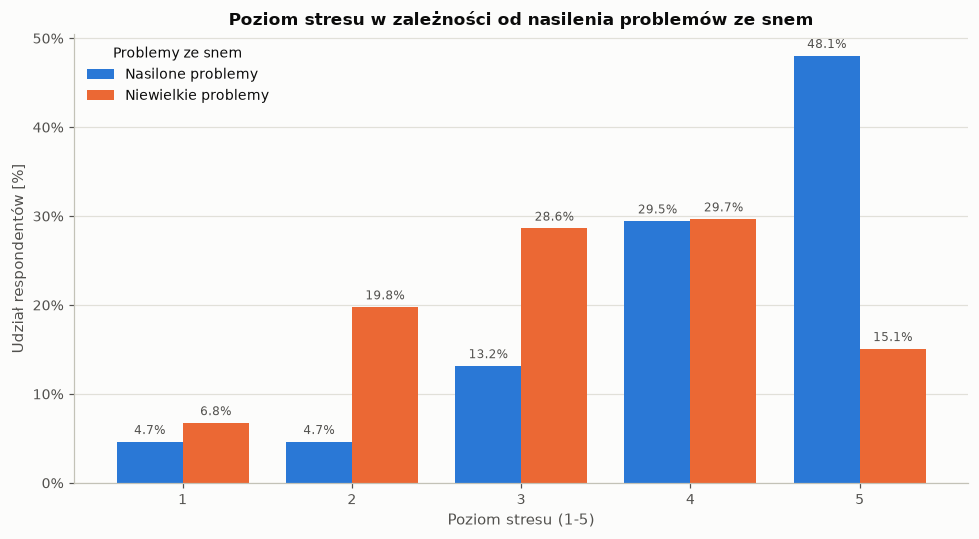

In [33]:
wynik = st.run_mannwhitney(df_sen_problemy, group="grupa_problemow_sen", outcome="poziom_stresu")
display(rp.mann_whitney(wynik))

_ = pl.plot_distribution_by_group(
    df_sen_problemy,
    column="poziom_stresu",
    groupby="grupa_problemow_sen",
    title="Poziom stresu w zależności od nasilenia problemów ze snem",
    xlabel="Poziom stresu (1-5)",
    legend_title="Problemy ze snem",
)

Test U Manna-Whitneya wykazał istotną statystycznie różnicę w poziomie stresu pomiędzy respondentami deklarującymi niewielkie i nasilone problemy ze snem (U = 7086,5; p < 0,001). Wielkość efektu była umiarkowana (r₍rb₎ = 0,428), co wskazuje, że różnica pomiędzy grupami ma nie tylko znaczenie statystyczne, ale również praktyczne. Mediana poziomu stresu wynosiła 3 w grupie osób deklarujących niewielkie problemy ze snem oraz 4 w grupie osób zgłaszających nasilone problemy. Wykres pokazuje wyraźne przesunięcie rozkładu odpowiedzi - w grupie respondentów z nasilonymi problemami ze snem zdecydowanie częściej występowały najwyższe poziomy stresu (5), natomiast w grupie osób z niewielkimi problemami częściej występowały odpowiedzi odpowiadające umiarkowanemu lub niskiemu poziomowi stresu.

### 4.9.2 Problemy ze snem a zdrowie psychiczne

Następnie sprawdzono, czy osoby deklarujące nasilone problemy ze snem różnią się od pozostałych pod względem oceny zdrowia psychicznego.

,Grupa 1,Grupa 2,N₁,N₂,Mediana 1,Mediana 2,U,p,r_rb,Siła efektu
0,Nasilone problemy,Niewielkie problemy,129,192,"2,0","3,0","7543,5","<0,001","-0,391",umiarkowany


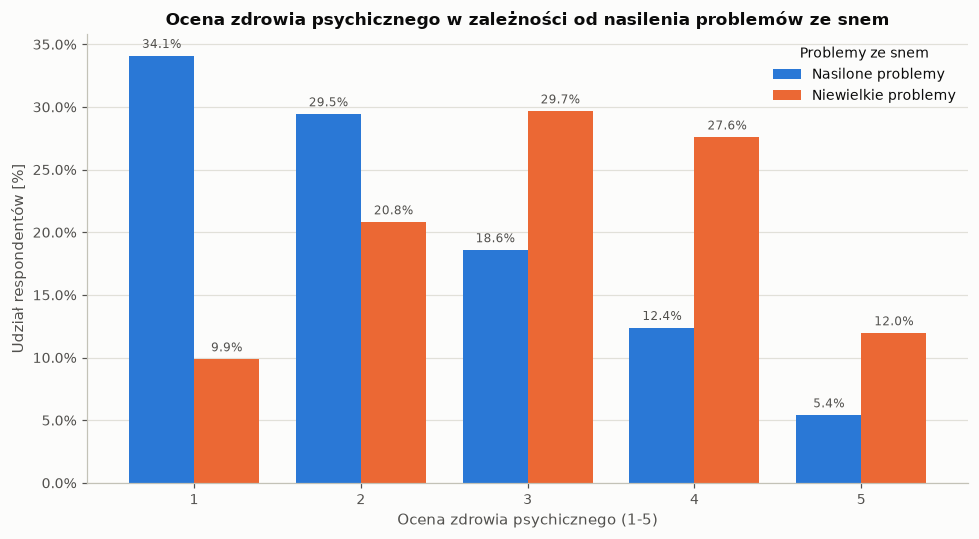

In [34]:
wynik = st.run_mannwhitney(df_sen_problemy, group="grupa_problemow_sen", outcome="sat_zdrowie_psych")
display(rp.mann_whitney(wynik))

_ = pl.plot_distribution_by_group(
    df_sen_problemy,
    column="sat_zdrowie_psych",
    groupby="grupa_problemow_sen",
    title="Ocena zdrowia psychicznego w zależności od nasilenia problemów ze snem",
    xlabel="Ocena zdrowia psychicznego (1-5)",
    legend_title="Problemy ze snem",
)

Test U Manna-Whitneya wykazał istotną statystycznie różnicę w ocenie zdrowia psychicznego pomiędzy respondentami deklarującymi niewielkie i nasilone problemy ze snem (U = 17224,5; p < 0,001). Wielkość efektu była umiarkowana (|r₍rb₎| = 0,391). Mediana oceny zdrowia psychicznego wynosiła 3 w grupie osób deklarujących niewielkie problemy ze snem oraz 2 w grupie osób zgłaszających nasilone problemy. Wykres pokazuje wyraźne przesunięcie rozkładu odpowiedzi - osoby z nasilonymi problemami ze snem znacznie częściej oceniały swoje zdrowie psychiczne nisko (1-2), natomiast respondenci deklarujący niewielkie problemy częściej wybierali umiarkowane lub wyższe oceny.

## 4.10 Porównanie zależności wskaźników snu

W poprzednich podrozdziałach przeanalizowano trzy różne aspekty snu: długość snu w dni robocze, regularność rytmu snu opisaną wskaźnikiem social jetlag oraz deklarowane problemy ze snem. W tej części zestawiono najważniejsze wyniki uzyskane dla każdego z tych wskaźników

In [35]:
porownanie_snu = pd.DataFrame(
    {
        "Wskaźnik snu": ["Długość snu", "Social jetlag", "Problemy ze snem"],
        "Stres": ["ρ = -0,270", "ρ = 0,207", "r_rb = 0,428"],
        "Zdrowie psychiczne": ["ρ = 0,215", "—", "r_rb = -0,391"],
        "Inne istotne wyniki": [
            "Satysfakcja ogólna: ρ = 0,203",
            "Problemy ze snem: ρ = 0,291",
            "—",
        ],
    }
)

display(porownanie_snu)

,Wskaźnik snu,Stres,Zdrowie psychiczne,Inne istotne wyniki
0,Długość snu,"ρ = -0,270","ρ = 0,215","Satysfakcja ogólna: ρ = 0,203"
1,Social jetlag,"ρ = 0,207",—,"Problemy ze snem: ρ = 0,291"
2,Problemy ze snem,"r_rb = 0,428","r_rb = -0,391",—


Długość snu wykazywała istotne związki z poziomem stresu, zdrowiem psychicznym oraz ogólnym wskaźnikiem satysfakcji. Wskaźnik social jetlag najsilniej wiązał się z deklarowanymi problemami ze snem, a także - w mniejszym stopniu - z poziomem stresu. Z kolei deklarowane problemy ze snem wykazywały umiarkowane związki zarówno z poziomem stresu, jak i oceną zdrowia psychicznego. Zestawienie to ułatwia porównanie wyników uzyskanych dla poszczególnych aspektów snu przed ich omówieniem w podsumowaniu rozdziału.

## 4.11 Podsumowanie sekcji

Przeprowadzone analizy wykazały, że sen stanowi istotny element związany z dobrostanem respondentów, jednak znaczenie poszczególnych jego aspektów było zróżnicowane. Sama długość snu w dni robocze wykazywała istotne statystycznie zależności z poziomem stresu, zdrowiem psychicznym, zdrowiem fizycznym oraz satysfakcją z życia. We wszystkich przypadkach siła korelacji była jednak niewielka, co wskazuje, że długość snu jest tylko jednym z wielu czynników wpływających na funkcjonowanie badanych.

Analiza długości snu w dni robocze i weekendy pokazała, że większość respondentów wydłużała sen w dniach wolnych od obowiązków. Zjawisko to znalazło odzwierciedlenie we wskaźniku social jetlag, który opisywał różnicę długości snu pomiędzy obiema częściami tygodnia. Uzyskane wyniki wskazują, że większe różnice długości snu wiązały się przede wszystkim z częstszym występowaniem problemów ze snem oraz, w mniejszym stopniu, z wyższym poziomem stresu. Pozostałe zależności miały słabą siłę i nie wskazywały, aby sam social jetlag był silnym predyktorem dobrostanu respondentów.

Najsilniejsze wyniki uzyskano dla deklarowanych problemów ze snem. Respondenci zgłaszający nasilone problemy ze snem charakteryzowali się wyższym poziomem stresu oraz gorszą oceną zdrowia psychicznego, a zaobserwowane różnice miały umiarkowaną wielkość efektu. W przeciwieństwie do samej długości snu, wskaźnik ten odzwierciedla subiektywną jakość i efektywność snu, co może lepiej opisywać rzeczywiste funkcjonowanie psychiczne badanych.

Łącznie uzyskane wyniki sugerują, że ocena wpływu snu na dobrostan nie powinna ograniczać się wyłącznie do liczby przespanych godzin. Chociaż odpowiednia długość snu pozostaje istotnym elementem zdrowego stylu życia, większe znaczenie dla funkcjonowania psychicznego wydają się mieć jego jakość oraz regularność.

---

# 5. Aktywność fizyczna

Aktywność fizyczna stanowi jeden z podstawowych elementów zdrowego stylu życia i jest uznawana za czynnik wspierający zarówno zdrowie fizyczne, jak i psychiczne. Regularny wysiłek fizyczny może wpływać na obniżenie poziomu stresu, poprawę samopoczucia oraz lepsze funkcjonowanie w życiu codziennym. W tej części przeanalizowano zależności pomiędzy deklarowanym czasem aktywności fizycznej a wybranymi aspektami dobrostanu respondentów. Dodatkowo sprawdzono, czy osoby bardziej aktywne różnią się od pozostałych pod względem wybranych elementów stylu życia.

## 5.1 Aktywność fizyczna w badanej próbie

Pierwszym krokiem analizy było przedstawienie rozkładu deklarowanego czasu aktywności fizycznej w ciągu tygodnia. Pozwala to scharakteryzować badaną grupę oraz ocenić liczebność poszczególnych kategorii przed analizą zależności z poziomem stresu i zdrowiem psychicznym.

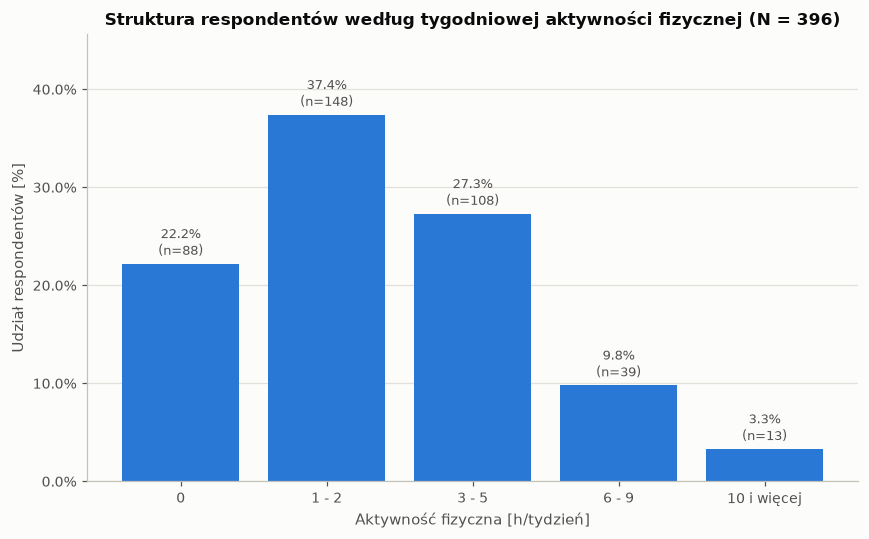

In [36]:
_ = pl.plot_distribution(
    df,
    "aktywnosc_fiz_h_tydz",
    value_labels=WARTOSCI("aktywnosc_fiz_h_tydz"),
    title="Struktura respondentów według tygodniowej aktywności fizycznej",
    xlabel="Aktywność fizyczna [h/tydzień]",
)

Najliczniejszą grupę stanowili respondenci deklarujący 1-2 godziny aktywności fizycznej tygodniowo (37,4%), a następnie osoby podejmujące 3-5 godzin aktywności (27,3%). Brak aktywności fizycznej zadeklarowało 22,2% badanych. Z kolei wysoka aktywność, obejmująca co najmniej 6 godzin tygodniowo, występowała znacznie rzadziej i dotyczyła łącznie 13,1% respondentów. Oznacza to, że w badanej próbie dominowały osoby podejmujące niewielką lub umiarkowaną aktywność fizyczną.

## 5.2 Aktywność fizyczna a dobrostan psychiczny

Jednym z najczęściej opisywanych efektów regularnej aktywności fizycznej jest jej korzystny wpływ na zdrowie psychiczne i redukcję stresu.

### 5.2.1 Aktywność fizyczna a stres

W pierwszej kolejności przeanalizowano zależność pomiędzy tygodniowym czasem aktywności fizycznej a poziomem odczuwanego stresu.

,Zmienna X,Zmienna Y,N,ρ,p
0,Aktywność fizyczna [h/tydzień],Poziom stresu,396,"-0,181","<0,001"


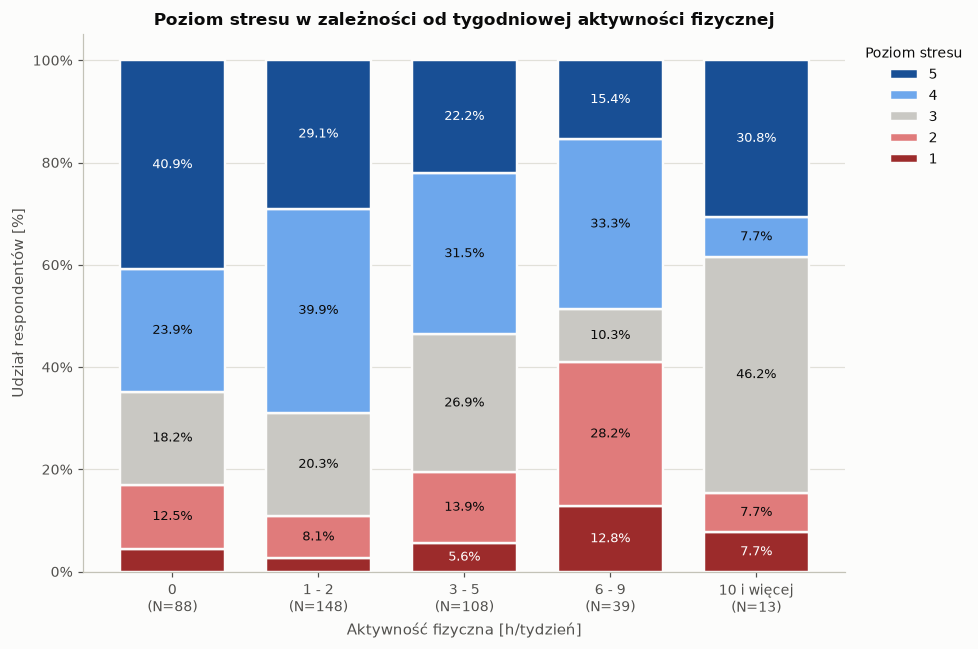

In [37]:
wynik = st.run_spearman(df, x="aktywnosc_fiz_h_tydz", y="poziom_stresu")
display(rp.spearman(wynik))

_ = pl.plot_stacked_likert(
    df,
    x="aktywnosc_fiz_h_tydz",
    y="poziom_stresu",
    x_labels=WARTOSCI("aktywnosc_fiz_h_tydz"),
    title="Poziom stresu w zależności od tygodniowej aktywności fizycznej",
    xlabel="Aktywność fizyczna [h/tydzień]",
    legend_title="Poziom stresu",
)

Tygodniowa aktywność fizyczna wykazywała istotną, lecz słabą ujemną korelację z poziomem stresu (ρ = -0,18; p < 0,001). Oznacza to, że osoby poświęcające więcej czasu na aktywność fizyczną przeciętnie deklarowały niższy poziom odczuwanego stresu. Rozkład odpowiedzi wskazuje na ogólną tendencję zgodną z wynikiem analizy korelacyjnej, jednak nie ma ona w pełni monotonicznego charakteru. Choć wraz ze wzrostem aktywności maleje odsetek respondentów deklarujących najwyższy poziom stresu (ocena 5), przejście z grupy niepodejmującej aktywności fizycznej do osób ćwiczących 1-2 godziny tygodniowo wiąże się jednocześnie ze wzrostem łącznego udziału odpowiedzi 4 i 5. Dopiero w kolejnych grupach widoczny jest bardziej systematyczny spadek odsetka odpowiedzi wskazujących na wysoki poziom stresu. Ostatnią grupę należy interpretować ostrożnie przez jej niską liczebność.

### 5.2.2 Aktywność fizyczna a zdrowie psychiczne

W kolejnym kroku sprawdzono, czy tygodniowy czas aktywności fizycznej wiąże się z oceną zdrowia psychicznego respondentów.

,Zmienna X,Zmienna Y,N,ρ,p
0,Aktywność fizyczna [h/tydzień],Zdrowie psychiczne,396,"0,231","<0,001"


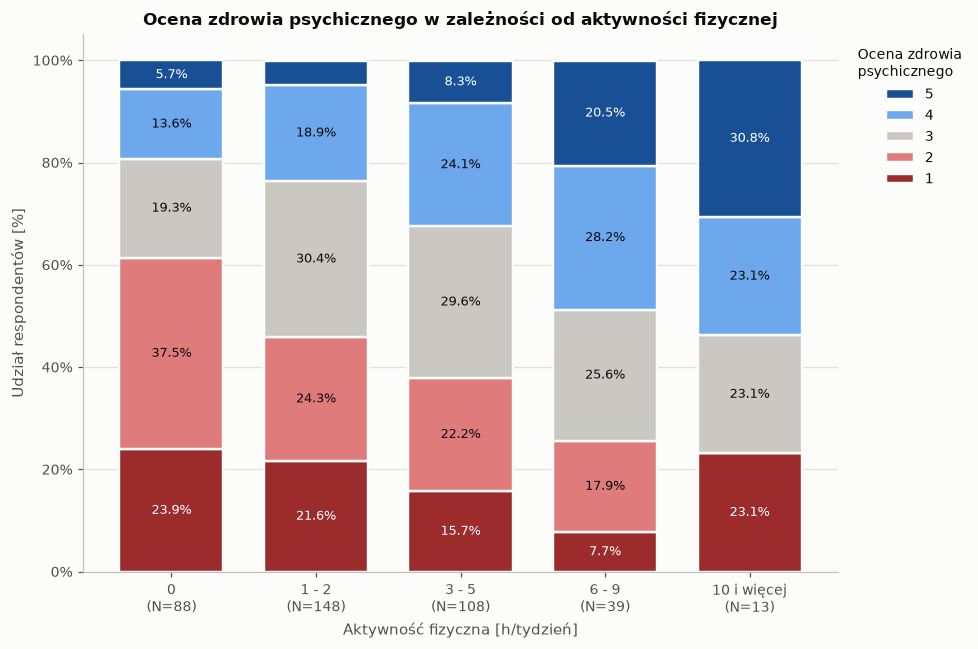

In [38]:
wynik = st.run_spearman(df, x="aktywnosc_fiz_h_tydz", y="sat_zdrowie_psych")
display(rp.spearman(wynik))

_ = pl.plot_stacked_likert(
    df,
    x="aktywnosc_fiz_h_tydz",
    y="sat_zdrowie_psych",
    x_labels=WARTOSCI("aktywnosc_fiz_h_tydz"),
    title="Ocena zdrowia psychicznego w zależności od aktywności fizycznej",
    xlabel="Aktywność fizyczna [h/tydzień]",
    legend_title="Ocena zdrowia\npsychicznego",
)

Tygodniowa aktywność fizyczna wykazywała istotną, lecz słabą dodatnią korelację z oceną zdrowia psychicznego (ρ = 0,23; p < 0,001). Oznacza to, że osoby poświęcające więcej czasu na aktywność fizyczną przeciętnie lepiej oceniały swoje zdrowie psychiczne. Rozkład odpowiedzi jest zgodny z wynikiem analizy korelacyjnej - wraz ze wzrostem aktywności fizycznej maleje udział najniższych ocen zdrowia psychicznego (1-2), natomiast rośnie odsetek odpowiedzi wskazujących na dobrą lub bardzo dobrą ocenę (4-5). Najbardziej wyraźny wzrost udziału najwyższych ocen widoczny jest w grupach deklarujących co najmniej 6 godzin aktywności fizycznej tygodniowo, choć wyniki dla kategorii "10 i więcej godzin" należy interpretować ostrożnie ze względu na niewielką liczebność tej grupy (N = 13).

## 5.3 Profil osób aktywnych i nieaktywnych

Dotychczasowe analizy dotyczyły zależności pomiędzy poziomem aktywności fizycznej a dobrostanem psychicznym. W celu porównania respondentów odpowiedzi 0 i 1-2 zakwalifikowano do grupy osób deklarujących niewielką tygodniową aktywność fizyczną, natomiast pozostałe odpowiedzi do grupy osób deklarujących większą tygodniową aktywność fizyczną. Celem analizy było sprawdzenie, czy większa aktywność fizyczna współwystępuje z innymi nawykami. Do oceny różnic pomiędzy nimi zastosowano nieparametryczny test U Manna-Whitneya.

In [39]:
# Podział na krańce: do 2 h tygodniowo wobec 3 h i więcej.
df_aktywnosc = df.copy()

df_aktywnosc["grupa_aktywnosci"] = np.where(
    df_aktywnosc["aktywnosc_fiz_h_tydz"] < 3,
    "Niska aktywność",
    "Wyższa aktywność",
)

In [40]:
display(rp.group_sizes(df_aktywnosc["grupa_aktywnosci"]))

,Liczebność
Grupa,
Niska aktywność,236
Wyższa aktywność,160


### 5.3.1 Zdrowie fizyczne

W pierwszej kolejności sprawdzono, czy osoby deklarujące wyższą aktywność fizyczną różnią się od pozostałych pod względem oceny własnego zdrowia fizycznego.

,Grupa 1,Grupa 2,N₁,N₂,Mediana 1,Mediana 2,U,p,r_rb,Siła efektu
0,Niska aktywność,Wyższa aktywność,236,160,"3,0","4,0","11352,5","<0,001","-0,399",umiarkowany


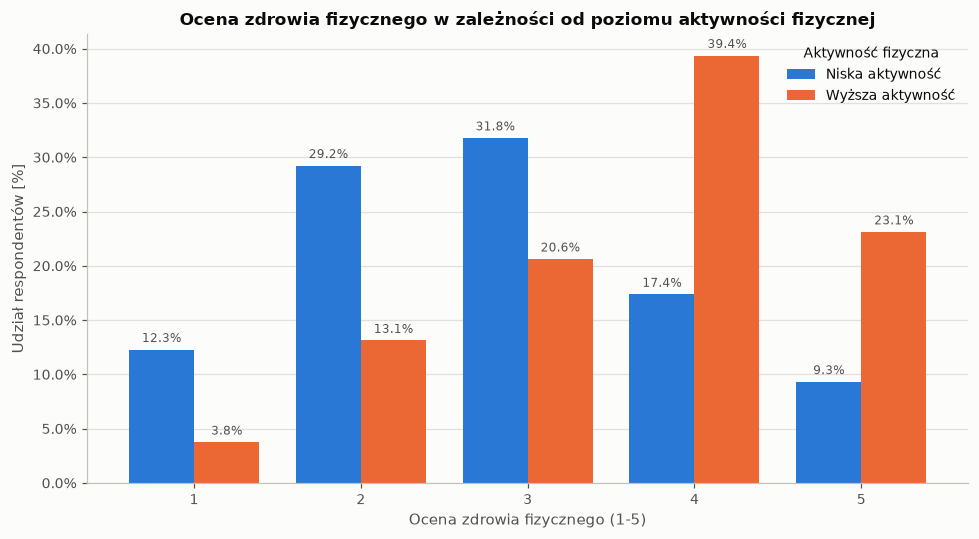

In [41]:
wynik = st.run_mannwhitney(df_aktywnosc, group="grupa_aktywnosci", outcome="sat_zdrowie_fiz")
display(rp.mann_whitney(wynik))

_ = pl.plot_distribution_by_group(
    df_aktywnosc,
    column="sat_zdrowie_fiz",
    groupby="grupa_aktywnosci",
    value_labels=None,
    title="Ocena zdrowia fizycznego w zależności od poziomu aktywności fizycznej",
    xlabel="Ocena zdrowia fizycznego (1-5)",
    legend_title="Aktywność fizyczna",
)

Test U Manna-Whitneya wykazał istotną statystycznie różnicę w ocenie zdrowia fizycznego pomiędzy respondentami deklarującymi niską oraz wyższą aktywność fizyczną (U = 26407,5; p < 0,001). Wielkość efektu była umiarkowana (|r₍rb₎| = 0,399), co wskazuje, że zależność ma nie tylko znaczenie statystyczne, ale również praktyczne. Mediana oceny zdrowia fizycznego wynosiła 3 w grupie osób o niskiej aktywności fizycznej oraz 4 w grupie osób bardziej aktywnych. Wykres pokazuje wyraźne przesunięcie rozkładu odpowiedzi - osoby deklarujące wyższą aktywność fizyczną znacznie częściej oceniały swoje zdrowie fizyczne wysoko (oceny 4-5), natomiast wśród respondentów o niskiej aktywności wyraźnie częściej występowały odpowiedzi 1-3.

### 5.3.2 Dieta

Następnie sprawdzono, czy poziom aktywności fizycznej wiąże się z subiektywną oceną własnej diety.

,Grupa 1,Grupa 2,N₁,N₂,Mediana 1,Mediana 2,U,p,r_rb,Siła efektu
0,Niska aktywność,Wyższa aktywność,236,160,"3,0","4,0","13617,0","<0,001","-0,279",mały


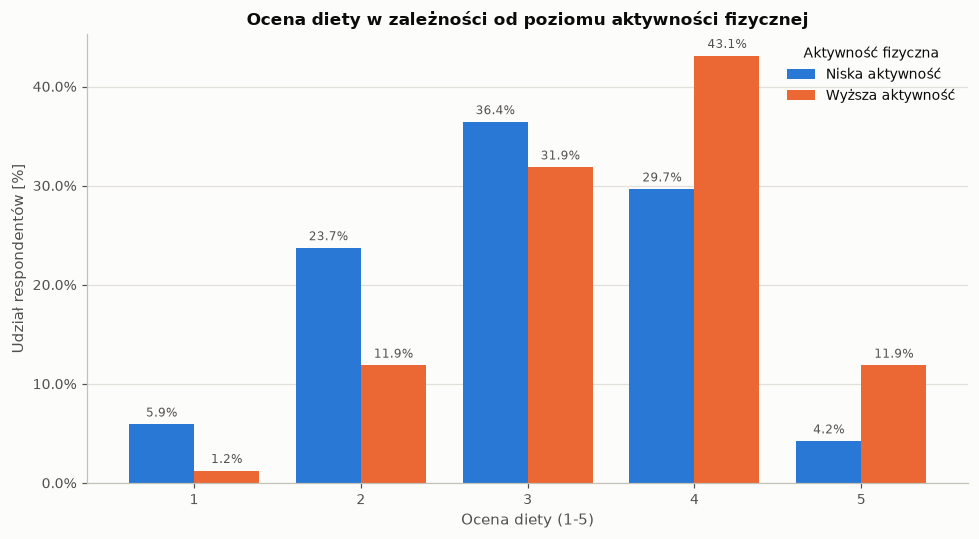

In [42]:
wynik = st.run_mannwhitney(df_aktywnosc, group="grupa_aktywnosci", outcome="ocena_diety")
display(rp.mann_whitney(wynik))

_ = pl.plot_distribution_by_group(
    df_aktywnosc,
    column="ocena_diety",
    groupby="grupa_aktywnosci",
    value_labels=None,
    title="Ocena diety w zależności od poziomu aktywności fizycznej",
    xlabel="Ocena diety (1-5)",
    legend_title="Aktywność fizyczna",
)

Test U Manna-Whitneya wykazał istotną statystycznie różnicę w ocenie diety pomiędzy respondentami deklarującymi niską oraz wyższą aktywność fizyczną (U = 24143,0; p < 0,001). Wielkość efektu była słaba (|r₍rb₎| = 0,279). Mediana oceny diety wynosiła 3 w grupie osób o niskiej aktywności fizycznej oraz 4 w grupie osób bardziej aktywnych. Wykres pokazuje przesunięcie rozkładu odpowiedzi w kierunku wyższych ocen - osoby deklarujące większą aktywność fizyczną wyraźnie częściej oceniały swoją dietę na 4 lub 5, natomiast wśród respondentów o niskiej aktywności częściej występowały niższe oceny (1-2). Otrzymane wyniki sugerują, że większa aktywność fizyczna współwystępuje z bardziej pozytywną oceną własnych nawyków żywieniowych.

### 5.3.3 Częstość spotkań ze znajomymi

W kolejnym kroku sprawdzono, czy poziom aktywności fizycznej wiąże się z częstością spotkań ze znajomymi.

,Grupa 1,Grupa 2,N₁,N₂,Mediana 1,Mediana 2,U,p,r_rb,Siła efektu
0,Niska aktywność,Wyższa aktywność,236,160,1× w miesiącu,1× w tygodniu,"14707,0","<0,001","-0,221",mały


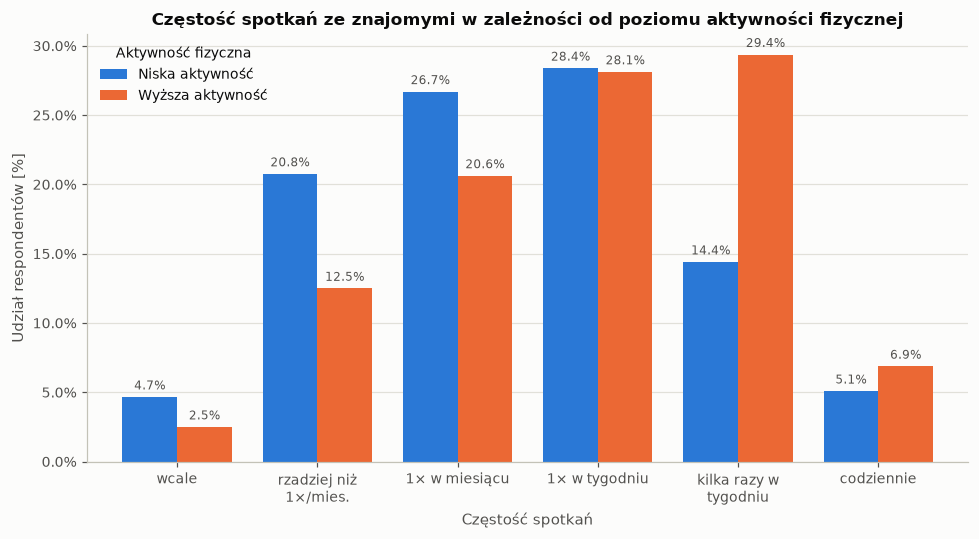

In [43]:
wynik = st.run_mannwhitney(df_aktywnosc, group="grupa_aktywnosci", outcome="czestosc_spotkan")
display(rp.mann_whitney(wynik, value_labels=WARTOSCI('czestosc_spotkan')))

_ = pl.plot_distribution_by_group(
    df_aktywnosc,
    column="czestosc_spotkan",
    groupby="grupa_aktywnosci",
    value_labels=WARTOSCI('czestosc_spotkan'),
    title="Częstość spotkań ze znajomymi w zależności od poziomu aktywności fizycznej",
    xlabel="Częstość spotkań",
    legend_title="Aktywność fizyczna",
)

Test U Manna-Whitneya wykazał istotną statystycznie różnicę w częstości spotkań ze znajomymi pomiędzy respondentami deklarującymi niską oraz wyższą aktywność fizyczną (U = 23053,0; p < 0,001). Wielkość efektu była słaba (|r₍rb₎| = 0,221). Typowa częstość spotkań odpowiadała raz w tygodniu w grupie osób bardziej aktywnych oraz raz w miesiącu w grupie osób o niskiej aktywności fizycznej. Wykres pokazuje przesunięcie rozkładu odpowiedzi w kierunku częstszych kontaktów społecznych - respondenci deklarujący wyższą aktywność fizyczną częściej wskazywali spotkania odbywające się kilka razy w tygodniu (29,4% wobec 14,4%), natomiast wśród osób mniej aktywnych większy udział stanowiły odpowiedzi odpowiadające rzadszym spotkaniom, takim jak raz w miesiącu lub rzadziej niż raz w miesiącu. Otrzymane wyniki sugerują, że większa aktywność fizyczna współwystępuje z częstszymi kontaktami towarzyskimi, choć siła tej zależności pozostaje niewielka.

### 5.3.4 Pozostałe wyniki

Oprócz opisanych wcześniej zależności przeanalizowano również pozostałe aspekty dobrostanu oraz stylu życia, które mogły różnić się pomiędzy respondentami deklarującymi niską i wyższą aktywność fizyczną. Tabela przedstawia wyniki dla wybranych zmiennych, które uzupełniają wcześniejsze analizy.

In [44]:
POZOSTALE_OBSZARY = [
    "sat_srednia",
    "poczucie_kontroli",
    "nauka_h_tydz",
    "czas_ekran_h_dzien",
    "czas_social_h_dzien",
    "czy_pracuje",
]

wyniki = st.comparison_table(df_aktywnosc, "grupa_aktywnosci", POZOSTALE_OBSZARY)
display(rp.comparisons(wyniki))

,Obszar,p (FDR),|r_rb|,Siła efektu,Różnica istotna?
0,Ogólny wskaźnik satysfakcji,"<0,001","0,256",mały,Tak
1,Poczucie kontroli,"<0,001","0,213",mały,Tak
2,Czy respondent pracuje,"0,103","0,095",pomijalny,Nie
3,Czas przed ekranem [h/dzień],"0,886","0,018",pomijalny,Nie
4,Czas w mediach społecznościowych [h/dzień],"0,886","0,018",pomijalny,Nie
5,Czas poświęcony nauce [h/tydzień],"0,911","0,006",pomijalny,Nie


Oprócz wcześniej omówionych różnic zaobserwowano również istotne, lecz słabe zależności dla ogólnego wskaźnika satysfakcji (|r₍rb₎| = 0,256) oraz poczucia kontroli nad własnym życiem (|r₍rb₎| = 0,213). Oznacza to, że osoby deklarujące wyższą aktywność fizyczną przeciętnie wyżej oceniały ogólną satysfakcję z życia oraz częściej odczuwały kontrolę nad własnym życiem.

Ze względu na wykonanie wielu porównań zastosowano korektę Benjamini-Hochberga (FDR), a przedstawione poziomy istotności odnoszą się do skorygowanych wartości p.

Jednocześnie nie uzyskano istotnych statystycznie różnic pomiędzy grupami pod względem czasu przeznaczanego na naukę, korzystania z urządzeń ekranowych, aktywności w mediach społecznościowych ani podejmowania pracy. Co więcej, wielkość efektu dla tych zmiennych była pomijalna (|r₍rb₎| < 0,10), co sugeruje, że ewentualne różnice pomiędzy grupami miały bardzo niewielki charakter. Na podstawie uzyskanych wyników nie stwierdzono zatem, aby osoby bardziej aktywne fizycznie poświęcały mniej czasu na naukę, pracę czy korzystanie z urządzeń elektronicznych.

## 5.4 Podsumowanie

Przeprowadzone analizy wskazują, że aktywność fizyczna była istotnie związana z wieloma aspektami dobrostanu badanych. Osoby deklarujące większą liczbę godzin aktywności fizycznej tygodniowo przeciętnie odczuwały niższy poziom stresu oraz lepiej oceniały swoje zdrowie psychiczne. Choć obserwowane zależności miały słabą siłę, były konsekwentne.

Analiza profilu respondentów wykazała ponadto, że osoby bardziej aktywne fizycznie wyżej oceniały swoje zdrowie fizyczne, lepiej oceniały własną dietę oraz częściej spotykały się ze znajomymi. Dodatkowo deklarowały wyższą ogólną satysfakcję z życia oraz większe poczucie kontroli nad własnym życiem. Spośród analizowanych zmiennych najsilniejszą zależność zaobserwowano dla oceny zdrowia fizycznego, dla której wielkość efektu osiągnęła poziom umiarkowany.

Jednocześnie nie uzyskano istotnych statystycznie różnic dotyczących czasu poświęcanego na naukę, korzystania z urządzeń ekranowych, aktywności w mediach społecznościowych ani podejmowania pracy. Oznacza to, że w badanej próbie większa aktywność fizyczna współwystępowała przede wszystkim z korzystniejszą oceną dobrostanu i wybranymi pozytywnymi nawykami, natomiast nie znaleziono dowodów na jej związek z ograniczaniem czasu przeznaczanego na codzienne obowiązki lub korzystanie z urządzeń elektronicznych.

---

# 6. Dieta

Dieta stanowi jeden z podstawowych elementów stylu życia i może wpływać zarówno na zdrowie fizyczne, jak i psychiczne. W tej części przeanalizowano zależności pomiędzy subiektywną oceną jakości diety a wybranymi aspektami dobrostanu respondentów. Dodatkowo sprawdzono, czy obserwowane zależności utrzymują się po uwzględnieniu poziomu wydatków oraz zweryfikowano kilka popularnych hipotez dotyczących studenckich nawyków żywieniowych.

## 6.1 Dieta w badanej próbie

Pierwszym krokiem analizy było przedstawienie rozkładu odpowiedzi respondentów. Pozwala to scharakteryzować badaną próbę oraz ocenić liczebność poszczególnych kategorii przed analizą zależności z dobrostanem.

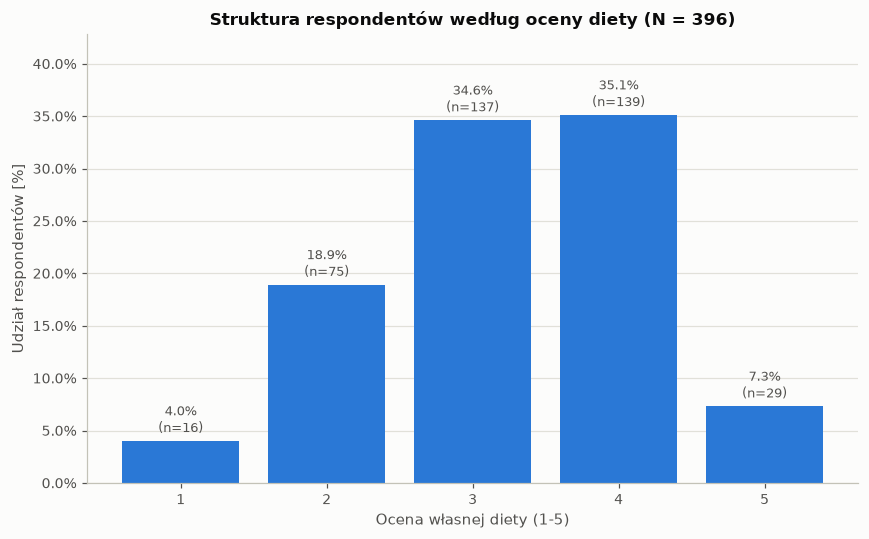

In [45]:
_ = pl.plot_distribution(
    df,
    "ocena_diety",
    title="Struktura respondentów według oceny diety",
    xlabel="Ocena własnej diety (1-5)",
)

Najliczniejszą grupę stanowili respondenci oceniający swoją dietę na 4 (35,1%), niewiele mniej osób wybrało ocenę 3 (34,6%). Oceny skrajne występowały zdecydowanie rzadziej - najwyższą ocenę 5 zadeklarowało 7,3% badanych, natomiast najniższą ocenę 1 jedynie 4,0%. Oznacza to, że większość respondentów postrzegała swoją dietę jako przeciętną lub dobrą, podczas gdy bardzo pozytywne i bardzo negatywne oceny należały do rzadkości.

## 6.2 Dieta a dobrostan

W kolejnym kroku przeanalizowano zależność pomiędzy subiektywną oceną własnej diety a wybranymi aspektami dobrostanu. Do oceny zależności zastosowano współczynnik korelacji rang Spearmana.

### 6.2.1 Dieta a zdrowie fizyczne

W pierwszej kolejności sprawdzono, czy subiektywna ocena jakości diety wiąże się z oceną własnego zdrowia fizycznego.

,Zmienna X,Zmienna Y,N,ρ,p
0,Ocena jakości diety,Zdrowie fizyczne,396,"0,319","<0,001"


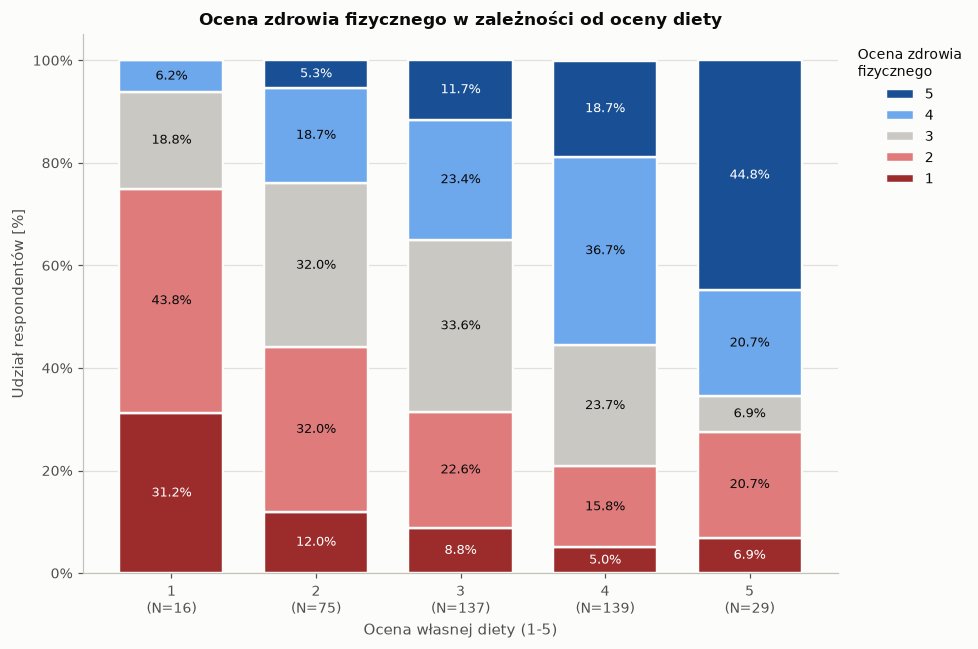

In [46]:
wynik = st.run_spearman(df, x="ocena_diety", y="sat_zdrowie_fiz")
display(rp.spearman(wynik))

_ = pl.plot_stacked_likert(
    df,
    x="ocena_diety",
    y="sat_zdrowie_fiz",
    title="Ocena zdrowia fizycznego w zależności od oceny diety",
    xlabel="Ocena własnej diety (1-5)",
    legend_title="Ocena zdrowia\nfizycznego",
)

Subiektywna ocena jakości diety wykazywała istotną, lecz słabą dodatnią korelację z oceną zdrowia fizycznego (ρ = 0,320; p < 0,001). Osoby lepiej oceniające swoją dietę przeciętnie wyżej oceniały również swoje zdrowie fizyczne. Rozkład odpowiedzi jest zgodny z wynikiem analizy korelacyjnej — wraz ze wzrostem oceny diety maleje udział najniższych ocen zdrowia fizycznego (1-2), a rośnie odsetek odpowiedzi wskazujących na dobrą lub bardzo dobrą ocenę (4-5). Trend ma niemal monotoniczny charakter i jest widoczny we wszystkich kolejnych kategoriach. Skrajne oceny diety (1 oraz 5) należy interpretować ostrożnie ze względu na niewielką liczebność tych grup.

### 6.2.2 Dieta a zdrowie psychiczne

W kolejnym kroku sprawdzono, czy subiektywna ocena jakości diety wiąże się również z oceną zdrowia psychicznego respondentów.

,Zmienna X,Zmienna Y,N,ρ,p
0,Ocena jakości diety,Zdrowie psychiczne,396,"0,121","0,016"


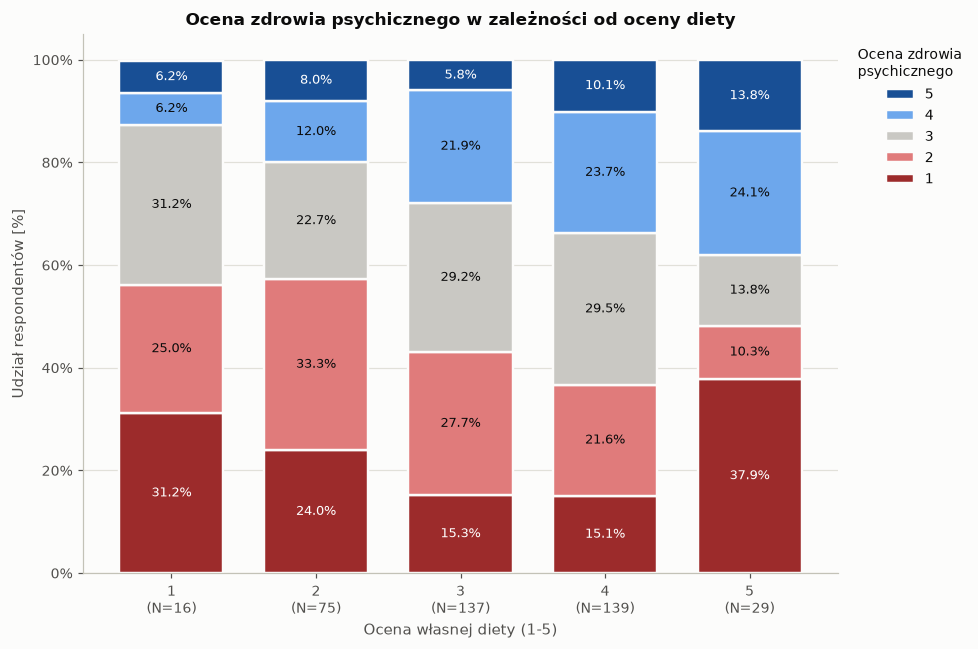

In [47]:
wynik = st.run_spearman(df, x="ocena_diety", y="sat_zdrowie_psych")
display(rp.spearman(wynik))

_ = pl.plot_stacked_likert(
    df,
    x="ocena_diety",
    y="sat_zdrowie_psych",
    title="Ocena zdrowia psychicznego w zależności od oceny diety",
    xlabel="Ocena własnej diety (1-5)",
    legend_title="Ocena zdrowia\npsychicznego",
)

Subiektywna ocena jakości diety wykazywała istotną, lecz bardzo słabą dodatnią korelację z oceną zdrowia psychicznego (ρ = 0,12; p = 0,016). Oznacza to, że osoby lepiej oceniające swoją dietę przeciętnie nieco wyżej oceniały również swoje zdrowie psychiczne, jednak siła tej zależności była niewielka. Rozkład odpowiedzi tylko częściowo odzwierciedla wynik analizy korelacyjnej. W grupach oceniających swoją dietę na 1-4 widoczna jest stopniowa tendencja do wzrostu udziału wyższych ocen zdrowia psychicznego oraz spadku udziału ocen najniższych. W kategorii najwyższej oceny diety (5) wzorzec ten nie utrzymuje się, co najprawdopodobniej wynika z niewielkiej liczebności tej grupy (N = 29). Otrzymane wyniki wskazują zatem, że związek pomiędzy oceną diety a zdrowiem psychicznym jest istotny statystycznie, lecz wyraźnie słabszy niż w przypadku zdrowia fizycznego.

## 6.3 Dieta a sytuacja finansowa

Można przypuszczać, że osoby dysponujące większym budżetem mają łatwiejszy dostęp do zdrowszej żywności, a tym samym lepiej oceniają swoje zdrowie. W związku z tym sprawdzono, czy zależność pomiędzy oceną diety a zdrowiem utrzymuje się również po uwzględnieniu wysokości podstawowych wydatków respondentów. W tym celu zastosowano modele regresji liniowej, w których jednocześnie uwzględniono ocenę diety oraz poziom wydatków podstawowych.

In [48]:
NAZWY_DIETA = {
    "Intercept": "Wyraz wolny",
    "ocena_diety": "Ocena diety",
    "wydatki_podstawowe": "Wydatki podstawowe",
}

model_fiz = smf.ols("sat_zdrowie_fiz ~ ocena_diety + wydatki_podstawowe", data=df).fit()
model_psych = smf.ols("sat_zdrowie_psych ~ ocena_diety + wydatki_podstawowe", data=df).fit()

for nazwa, model in [("Zdrowie fizyczne", model_fiz), ("Zdrowie psychiczne", model_psych)]:
    display(rp.model_fit(model, nazwa))
    display(rp.regression(model, NAZWY_DIETA))

,Model,N,R²,skoryg. R²,F,p
0,Zdrowie fizyczne,396,"0,109","0,104","24,00","<0,001"


,Zmienna,β,95% CI,p
0,Wyraz wolny,"2,015","[1,55; 2,48]","<0,001"
1,Ocena diety,"0,393","[0,28; 0,51]","<0,001"
2,Wydatki podstawowe,"-0,000","[-0,00; 0,00]","0,260"


,Model,N,R²,skoryg. R²,F,p
0,Zdrowie psychiczne,396,"0,014","0,009","2,86","0,058"


,Zmienna,β,95% CI,p
0,Wyraz wolny,"2,193","[1,70; 2,69]","<0,001"
1,Ocena diety,"0,150","[0,03; 0,27]","0,018"
2,Wydatki podstawowe,"0,000","[-0,00; 0,00]","0,647"


Wyniki regresji liniowej wskazują, że po uwzględnieniu wysokości podstawowych wydatków respondentów subiektywna ocena diety nadal pozostawała istotnie związana zarówno z oceną zdrowia fizycznego (p < 0,001), jak i zdrowia psychicznego (p=0,018). Jednocześnie nie uzyskano dowodów na istotny związek pomiędzy poziomem podstawowych wydatków a oceną zdrowia fizycznego (p = 0,260) ani zdrowia psychicznego (p = 0,647).

Otrzymane wyniki sugerują, że zależność pomiędzy subiektywną oceną diety a zdrowiem utrzymuje się również po uwzględnieniu poziomu podstawowych wydatków respondentów. Oznacza to, że obserwowane wcześniej związki nie mogą być wyjaśnione wyłącznie różnicami w sytuacji finansowej badanych.

Model wyjaśniał około 10,9% zróżnicowania ocen zdrowia fizycznego oraz 1,4% zróżnicowania ocen zdrowia psychicznego. Oznacza to, że uwzględnione zmienne w znacznie większym stopniu wyjaśniały zróżnicowanie ocen zdrowia fizycznego niż psychicznego.

## 6.4 Dodatkowe obserwacje

Oprócz związku z oceną zdrowia przeanalizowano również zależności pomiędzy subiektywną oceną diety a wybranymi elementami stylu życia. Analizy miały charakter uzupełniający i służyły identyfikacji dodatkowych wzorców występujących w badanej próbie.

In [49]:
OBSZARY_DIETY = [
    "czestosc_fastfood",
    "czestosc_energetyki",
    "czas_social_h_dzien",
    "srednia_ocen",
]

wyniki = st.correlation_table(df, "ocena_diety", OBSZARY_DIETY)
display(rp.correlations(wyniki))

,Obszar,N,ρ,p (FDR),Istotna?
0,Częstość spożywania fast foodów,395,"-0,475","<0,001",Tak
1,Częstość spożywania napojów energetycznych,394,"-0,285","<0,001",Tak
2,Czas w mediach społecznościowych [h/dzień],396,"-0,196","<0,001",Tak
3,Średnia ocen z ostatniego semestru,288,"0,187","0,001",Tak


Najsilniejszą zależność zaobserwowano dla częstości spożywania fast foodów (ρ = -0,475), co wskazuje, że osoby lepiej oceniające swoją dietę również rzadziej deklarowały spożywanie tego typu produktów. Podobną, choć słabszą zależność odnotowano dla spożycia napojów energetycznych (ρ = -0,285). Ponadto lepsza ocena diety wiązała się z krótszym czasem korzystania z mediów społecznościowych (ρ = -0,196) oraz nieznacznie wyższą średnią ocen (ρ = 0,187).

## 6.5 Podsumowanie

Przeprowadzone analizy wskazują, że subiektywna ocena jakości diety była związana przede wszystkim z oceną zdrowia fizycznego, natomiast zależność z oceną zdrowia psychicznego była wyraźnie słabsza. Dodatkowo wykazano, że obserwowane związki utrzymywały się również po uwzględnieniu poziomu podstawowych wydatków respondentów, co sugeruje, że nie mogą być one wyjaśnione wyłącznie różnicami w sytuacji finansowej badanych.

Analiza dodatkowych zależności wykazała również, że osoby lepiej oceniające swoją dietę rzadziej deklarowały spożywanie fast foodów i napojów energetycznych oraz przeciętnie spędzały mniej czasu korzystając z mediów społecznościowych. Zaobserwowano także słabą dodatnią zależność pomiędzy oceną diety a średnią ocen.

Otrzymane wyniki wskazują, że subiektywna ocena jakości diety stanowi element szerszego wzorca zachowań prozdrowotnych. Jednocześnie siła większości zaobserwowanych zależności była słaba lub umiarkowana, co sugeruje, że dieta jest jednym z wielu czynników związanych z dobrostanem studentów, a nie jego jedynym wyznacznikiem.

---

# 7. Relacje społeczne

Relacje społeczne stanowią jeden z kluczowych elementów dobrostanu i mogą wpływać zarówno na jakość życia, jak i zdrowie psychiczne. W tej części przeanalizowano zależności pomiędzy wybranymi aspektami funkcjonowania społecznego respondentów a ich dobrostanem. Analiza objęła liczbę bliskich znajomych, częstotliwość spotkań towarzyskich, stan cywilny oraz poziom odczuwanego wsparcia społecznego.

## 7.1 Relacje społeczne w badanej próbie

Pierwszym krokiem analizy było przedstawienie rozkładu odpowiedzi respondentów. Pozwala to scharakteryzować badaną próbę oraz ocenić liczebność poszczególnych kategorii przed dalszą analizą.

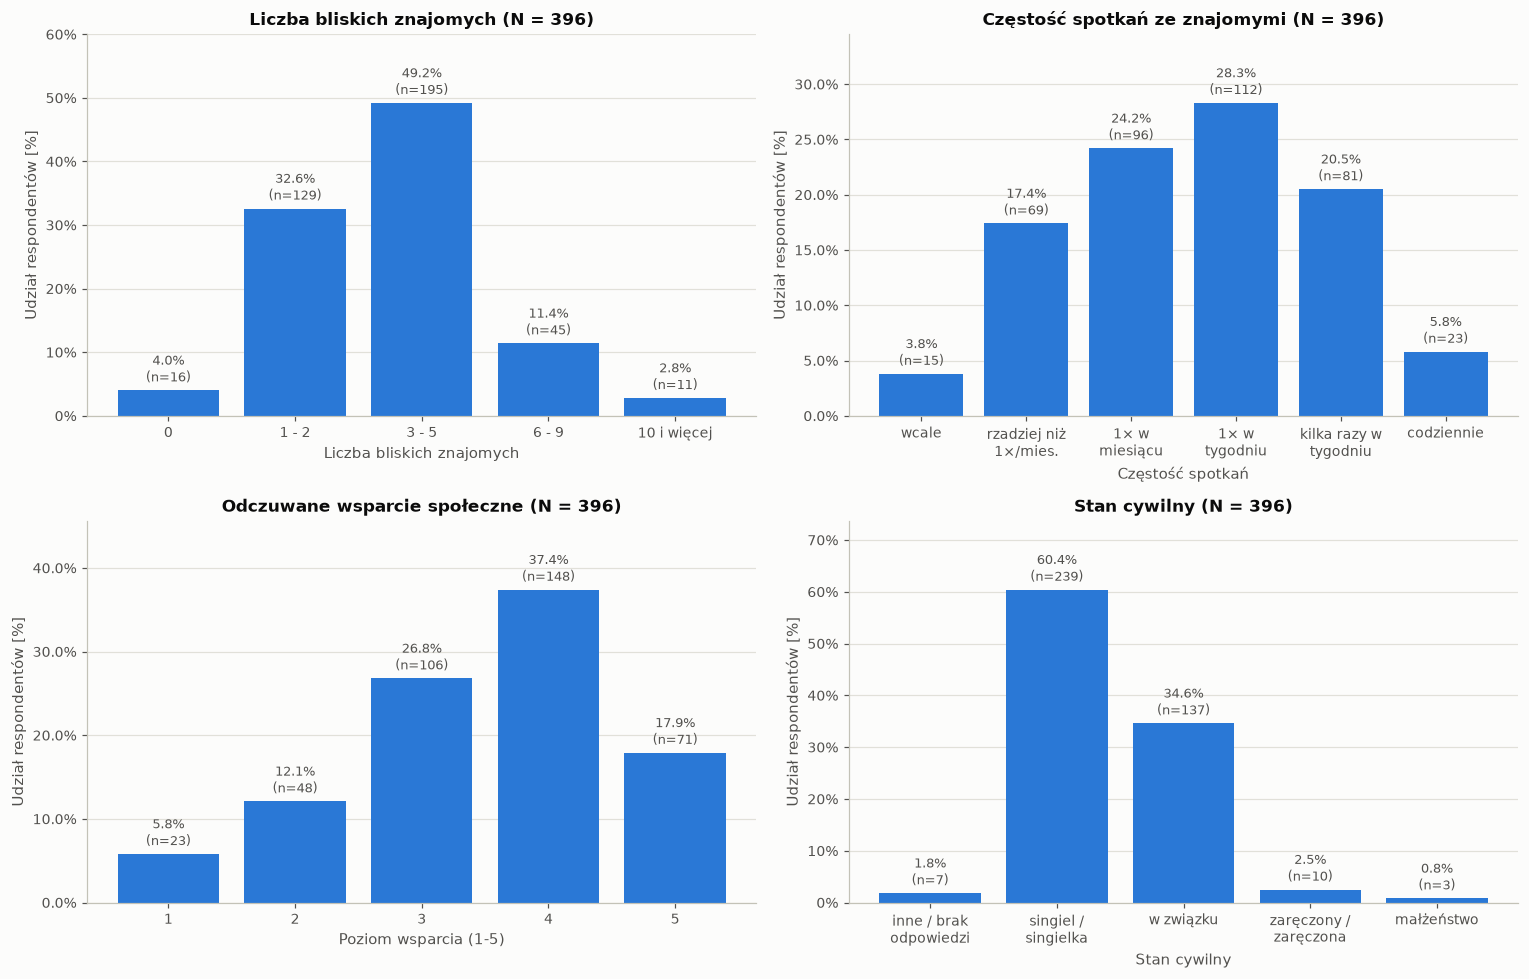

In [50]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

pl.plot_distribution(
    df, "liczba_bliskich",
    value_labels=WARTOSCI("liczba_bliskich"),
    title="Liczba bliskich znajomych",
    xlabel="Liczba bliskich znajomych",
    ax=axes[0, 0],
)
pl.plot_distribution(
    df, "czestosc_spotkan",
    value_labels=WARTOSCI("czestosc_spotkan"),
    title="Częstość spotkań ze znajomymi",
    xlabel="Częstość spotkań",
    wrap=12,
    ax=axes[0, 1],
)
pl.plot_distribution(
    df, "poziom_wsparcia",
    title="Odczuwane wsparcie społeczne",
    xlabel="Poziom wsparcia (1-5)",
    ax=axes[1, 0],
)
pl.plot_distribution(
    df, "stan_cywilny",
    title="Stan cywilny",
    xlabel="Stan cywilny",
    wrap=12,
    ax=axes[1, 1],
)

fig.tight_layout()

Badana próba charakteryzowała się umiarkowanie rozwiniętymi relacjami społecznymi. Największa grupa respondentów deklarowała posiadanie od 3 do 5 bliskich znajomych (49,2%), natomiast jedynie 2,8% wskazało liczbę co najmniej 10 bliskich znajomych.

Najczęściej deklarowaną częstotliwością spotkań było spotykanie się raz w tygodniu (28,3%), a ponad połowa respondentów oceniała poziom otrzymywanego wsparcia społecznego jako wysoki (4-5). Większość badanych stanowiły osoby niepozostające w związku (60,4%).

## 7.2 Liczba bliskich znajomych a dobrostan

W pierwszej kolejności przeanalizowano zależność pomiędzy deklarowaną liczbą bliskich znajomych a satysfakcją z relacji. Celem analizy było sprawdzenie, czy większa liczba bliskich relacji wiąże się z wyższym poziomem zadowolenia oraz czy zależność ta ma charakter liniowy.

### 7.2.1 Liczba bliskich znajomych a satysfakcja z relacji

Do oceny zależności pomiędzy liczbą bliskich znajomych a satysfakcją z relacji wykorzystano współczynnik korelacji rang Spearmana.

,Zmienna X,Zmienna Y,N,ρ,p
0,Liczba bliskich znajomych,Satysfakcja z relacji,396,"0,318","<0,001"


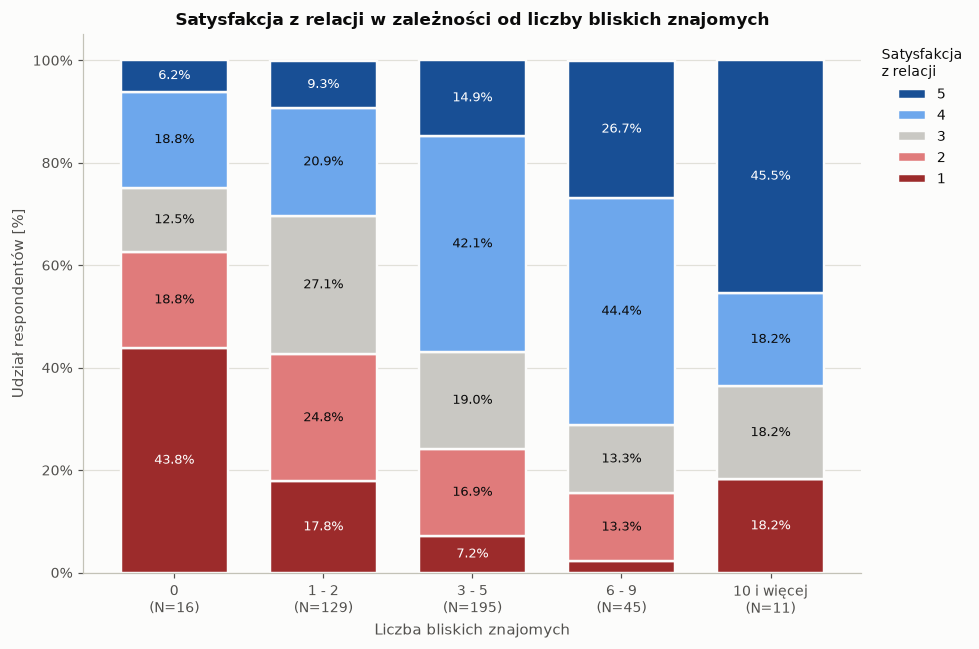

In [51]:
wynik = st.run_spearman(df, x="liczba_bliskich", y="sat_relacje")
display(rp.spearman(wynik))

_ = pl.plot_stacked_likert(
    df,
    x="liczba_bliskich",
    y="sat_relacje",
    x_labels=WARTOSCI("liczba_bliskich"),
    title="Satysfakcja z relacji w zależności od liczby bliskich znajomych",
    xlabel="Liczba bliskich znajomych",
    legend_title="Satysfakcja\nz relacji",
)

Liczba bliskich znajomych wykazywała istotną, lecz słabą dodatnią korelację z satysfakcją z relacji (ρ = 0,32; p < 0,001). Oznacza to, że osoby deklarujące większą liczbę bliskich znajomych przeciętnie wyżej oceniały satysfakcję z relacji. Rozkład odpowiedzi odzwierciedla wynik analizy korelacyjnej - wraz ze wzrostem liczby bliskich znajomych maleje udział najniższych ocen satysfakcji (1-2), natomiast rośnie odsetek ocen wysokich (4-5). Najbardziej wyraźna zmiana widoczna jest pomiędzy grupami posiadającymi 1-2 oraz 3-5 bliskich znajomych. W dwóch najwyższych kategoriach liczby znajomych przeważają odpowiedzi 4 i 5, jednak wyniki dla grupy deklarującej 10 i więcej bliskich znajomych należy interpretować ostrożnie ze względu na niewielką liczebność tej grupy (N = 11).

### 7.2.2 Punkt nasycenia relacji

W kolejnym kroku sprawdzono, czy średni poziom satysfakcji z relacji różni się pomiędzy kategoriami liczby bliskich znajomych. W tym celu zastosowano jednoczynnikową analizę wariancji (ANOVA), a następnie test post hoc Tukeya HSD, pozwalający określić, pomiędzy którymi grupami występują istotne statystycznie różnice. Wyniki zilustrowano wykresem średnich wraz z 95% przedziałami ufności.

,Obszar,H,η²,p (FDR),Istotna?
0,Satysfakcja z relacji,"40,42","0,093","<0,001",Tak


,Liczba bliskich znajomych,N,Mediana,Średnia,SD
0,0,16,2.0,2.25,1.39
1,1 - 2,129,3.0,2.79,1.23
2,3 - 5,195,4.0,3.41,1.15
3,6 - 9,45,4.0,3.80,1.06
4,10 i więcej,11,4.0,3.73,1.56


,Porównanie,p (FDR),Istotna?
0,0.0 vs 1 - 2,"0,221",Nie
1,1 - 2 vs 3 - 5.0,"<0,001",Tak
2,3 - 5.0 vs 6 - 9,"0,068",Nie
3,6 - 9 vs 10 i więcej.0,"0,965",Nie


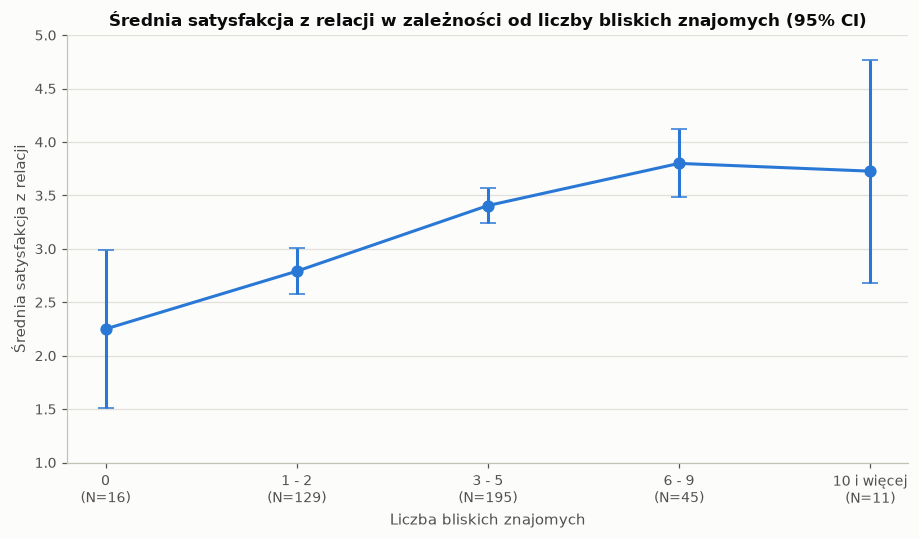

In [52]:
# Test nieparametryczny, spójnie z metodyką przyjętą w całym raporcie
# (satysfakcja z relacji to skala porządkowa 1-5).
wynik, statystyki = st.run_kruskal(df, "liczba_bliskich", "sat_relacje")
display(rp.kruskal(st.fdr_correction(wynik)))

statystyki["Liczba bliskich znajomych"] = statystyki["liczba_bliskich"].map(
    WARTOSCI("liczba_bliskich")
)
display(statystyki[["Liczba bliskich znajomych", "N", "Mediana", "Średnia", "SD"]].round(2))

# Post hoc: interesują nas przejścia między sąsiednimi kategoriami.
porownania = st.fdr_correction(st.run_dunn(df, "liczba_bliskich", "sat_relacje"))

wartosci = sorted(df["liczba_bliskich"].dropna().unique())
sasiednie = {f"{a} vs {b}" for a, b in zip(wartosci[:-1], wartosci[1:])}

display(
    rp.dunn(
        porownania[porownania["porownanie"].isin(sasiednie)],
        value_labels=WARTOSCI("liczba_bliskich"),
    )
)

_ = pl.plot_mean_ci(
    df,
    x="liczba_bliskich",
    y="sat_relacje",
    x_labels=WARTOSCI("liczba_bliskich"),
    title="Średnia satysfakcja z relacji w zależności od liczby bliskich znajomych",
    xlabel="Liczba bliskich znajomych",
    ylabel="Średnia satysfakcja z relacji",
    ylim=(1, 5),
)

Test Kruskala-Wallisa wykazał, że poziom satysfakcji z relacji różni się istotnie między kategoriami liczby bliskich znajomych (H = 40,42; p < 0,001; η² = 0,093). Sam wynik testu omnibus nie wskazuje jednak, które grupy się różnią — w tym celu przeprowadzono test post hoc Dunna z korektą Benjaminiego-Hochberga.

Spośród przejść między sąsiednimi kategoriami istotna okazała się wyłącznie zmiana z 1-2 na 3-5 bliskich znajomych (p = 0,0001). Przejście z 3-5 na 6-9 znajomych nie osiągnęło istotności po korekcie (p = 0,068), podobnie jak pozostałe porównania. Oznacza to, że największy przyrost satysfakcji z relacji następuje po osiągnięciu około 3-5 bliskich osób, a dalsze powiększanie sieci kontaktów nie wiąże się już z istotną poprawą.

Wykres średnich z 95% przedziałami ufności ilustruje ten wzorzec. Średnia satysfakcja rośnie wyraźnie od kategorii 0 i 1-2 do 3-5 znajomych, po czym stabilizuje się. Nakładanie się przedziałów ufności dla trzech najwyższych kategorii jest zgodne z wynikami testu post hoc. Szeroki przedział dla kategorii „10 i więcej" wynika z jej niewielkiej liczebności (N = 11), dlatego średnią w tej grupie należy traktować ostrożnie.

W poprzedniej wersji raportu w tym miejscu zastosowano jednoczynnikową analizę wariancji z testem Tukeya. Zastąpiono ją testem nieparametrycznym, spójnym z metodyką przyjętą w pozostałych rozdziałach — satysfakcja z relacji jest zmienną porządkową mierzoną na pięciostopniowej skali. Wnioski merytoryczne pozostały bez zmian.

## 7.3 Częstość spotkań a dobrostan

W kolejnym kroku przeanalizowano zależność pomiędzy deklarowaną częstotliwością spotkań z bliskimi znajomymi a satysfakcją z relacji. Celem analizy było sprawdzenie, czy częstsze utrzymywanie kontaktów społecznych wiąże się z wyższym poziomem zadowolenia z relacji.

### 7.3.1 Częstość spotkań a satysfakcja z relacji

Do oceny zależności wykorzystano współczynnik korelacji rang Spearmana. Na wykresie przedstawiono procentowy rozkład ocen satysfakcji z relacji w poszczególnych kategoriach częstości spotkań.

,Zmienna X,Zmienna Y,N,ρ,p
0,Częstość spotkań ze znajomymi,Satysfakcja z relacji,396,"0,254","<0,001"


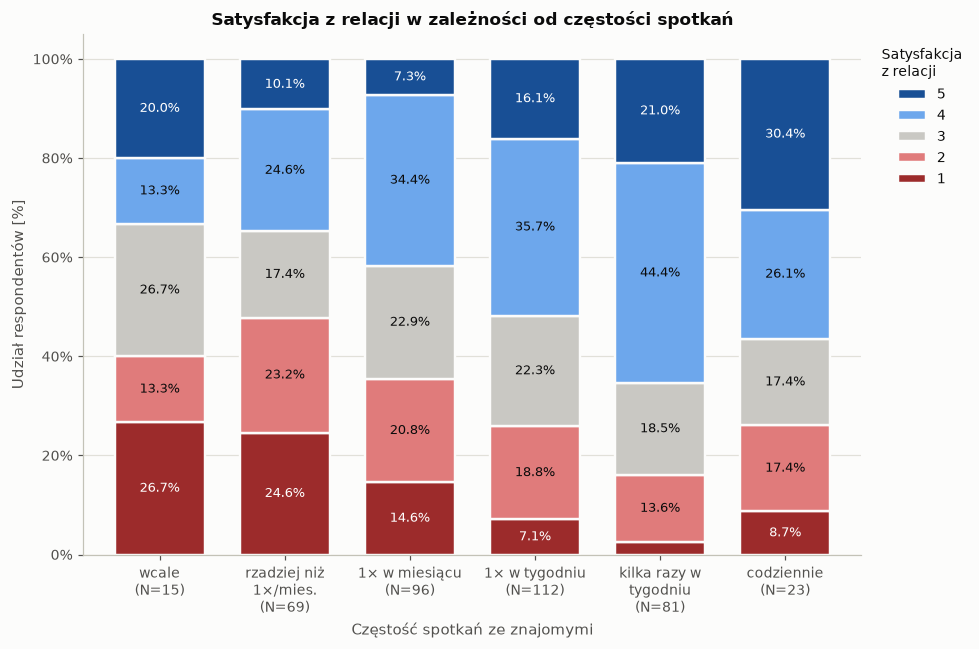

In [53]:
wynik = st.run_spearman(df, x="czestosc_spotkan", y="sat_relacje")
display(rp.spearman(wynik))

_ = pl.plot_stacked_likert(
    df,
    x="czestosc_spotkan",
    y="sat_relacje",
    x_labels=WARTOSCI("czestosc_spotkan"),
    title="Satysfakcja z relacji w zależności od częstości spotkań",
    xlabel="Częstość spotkań ze znajomymi",
    legend_title="Satysfakcja\nz relacji",
)

Częstość spotkań wykazała istotną, lecz słabą dodatnią korelację z satysfakcją z relacji (ρ = 0,254; p < 0,001). Osoby częściej spotykające się z bliskimi znajomymi przeciętnie wyżej oceniały satysfakcję ze swoich relacji. Rozkład odpowiedzi jest zgodny z wynikiem analizy — wraz ze wzrostem częstości spotkań maleje udział najniższych ocen satysfakcji (1-2), a rośnie odsetek odpowiedzi wysokich (4-5). Skrajne kategorie „wcale" (N = 15) oraz „codziennie" (N = 23) należy interpretować ostrożnie ze względu na małą liczebność.

### 7.3.2 Częstość spotkań jako moderator wpływu liczby bliskich znajomych

W poprzednich analizach wykazano, że zarówno liczba bliskich znajomych, jak i częstość spotkań są dodatnio związane z satysfakcją z relacji. W kolejnym kroku sprawdzono, czy zależności te są od siebie niezależne, czy też częstość spotkań modyfikuje wpływ liczby bliskich znajomych na poziom satysfakcji z relacji.

,Model,N,R²,skoryg. R²,F,p
0,Satysfakcja z relacji,396,"0,141","0,132","16,04","<0,001"


,Zmienna,β,95% CI,p
0,Wyraz wolny,"2,240","[1,77; 2,71]","<0,001"
1,Liczba bliskich znajomych,"0,275","[0,10; 0,45]","0,002"
2,(Liczba bliskich znajomych)²,"-0,032","[-0,05; -0,01]","0,001"
3,Częstość spotkań,"0,011","[-0,16; 0,19]","0,900"
4,Liczba znajomych × częstość spotkań,"0,051","[0,01; 0,10]","0,030"


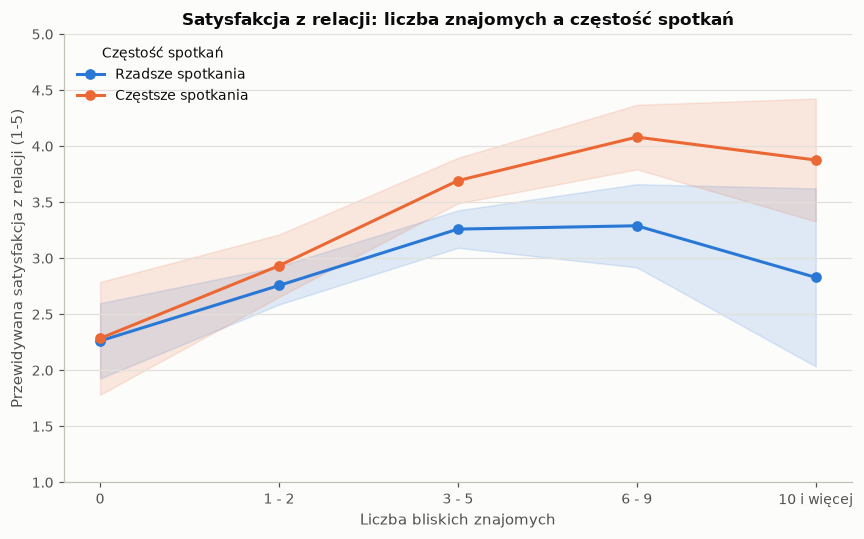

In [54]:
NAZWY_MODERACJA = {
    "Intercept": "Wyraz wolny",
    "liczba_bliskich": "Liczba bliskich znajomych",
    "liczba_bliskich_sq": "(Liczba bliskich znajomych)²",
    "czestosc_spotkan": "Częstość spotkań",
    "liczba_bliskich:czestosc_spotkan": "Liczba znajomych × częstość spotkań",
}

df_moderacja = df[["liczba_bliskich", "czestosc_spotkan", "sat_relacje"]].dropna().copy()
df_moderacja["liczba_bliskich_sq"] = df_moderacja["liczba_bliskich"] ** 2

model_moderacja = smf.ols(
    "sat_relacje ~ liczba_bliskich + liczba_bliskich_sq"
    " + czestosc_spotkan + liczba_bliskich:czestosc_spotkan",
    data=df_moderacja,
).fit()

display(rp.model_fit(model_moderacja, "Satysfakcja z relacji"))
display(rp.regression(model_moderacja, NAZWY_MODERACJA))

# Wykres interakcji: przewidywania modelu dla dwóch poziomów częstości spotkań.
siatka = np.array([0, 1.5, 4, 7.5, 10])
kwartyle = df_moderacja["czestosc_spotkan"].quantile([0.25, 0.75])

predykcja = pd.DataFrame(
    {
        "liczba_bliskich": np.tile(siatka, 2),
        "czestosc_spotkan": np.repeat(kwartyle.values, len(siatka)),
    }
)
predykcja["liczba_bliskich_sq"] = predykcja["liczba_bliskich"] ** 2
predykcja["Grupa"] = np.repeat(["Rzadsze spotkania", "Częstsze spotkania"], len(siatka))

oszacowanie = model_moderacja.get_prediction(predykcja).summary_frame(alpha=0.05)
predykcja[["srednia", "dol", "gora"]] = oszacowanie[
    ["mean", "mean_ci_lower", "mean_ci_upper"]
].values

fig, ax = plt.subplots(figsize=(8, 5))
etykiety = [WARTOSCI("liczba_bliskich")[v] for v in siatka]

for kolor, (grupa, dane) in zip(pl.CATEGORICAL, predykcja.groupby("Grupa", sort=False)):
    ax.plot(etykiety, dane["srednia"], marker="o", linewidth=2, label=grupa, color=kolor)
    ax.fill_between(etykiety, dane["dol"], dane["gora"], alpha=0.14, color=kolor)

ax.set_ylim(1, 5)
ax.set_xlabel("Liczba bliskich znajomych")
ax.set_ylabel("Przewidywana satysfakcja z relacji (1-5)")
ax.set_title("Satysfakcja z relacji: liczba znajomych a częstość spotkań")
ax.grid(axis="y")
ax.legend(title="Częstość spotkań")
fig.tight_layout()

W celu sprawdzenia, czy częstość spotkań modyfikuje zależność pomiędzy liczbą bliskich znajomych a satysfakcją z relacji, dopasowano model regresji uwzględniający liniowy i kwadratowy efekt liczby bliskich znajomych, częstość spotkań oraz ich interakcję. Model był istotny statystycznie (F = 16,04; p < 0,001) i wyjaśniał 14,1% zróżnicowania satysfakcji z relacji (R² = 0,141).

Zarówno liniowy (β = 0,275; p = 0,002), jak i kwadratowy składnik liczby bliskich znajomych (β = −0,032; p = 0,001) okazały się istotne statystycznie, co potwierdza wcześniejsze obserwacje wskazujące na występowanie efektu nasycenia - korzyści wynikające ze wzrostu liczby bliskich znajomych stopniowo maleją wraz z wielkością sieci społecznej. Nie uzyskano natomiast dowodów na istotny główny efekt częstości spotkań po uwzględnieniu pozostałych zmiennych (β = 0,011; p = 0,900). Jednocześnie istotna interakcja pomiędzy liczbą bliskich znajomych a częstością spotkań (β = 0,051; p = 0,030) wskazuje, że związek pomiędzy liczbą bliskich znajomych a satysfakcją z relacji zależy od częstotliwości utrzymywania kontaktów z tymi osobami.

Jak przedstawiono na wykresie, w obu grupach satysfakcja z relacji wzrasta wraz ze zwiększaniem liczby bliskich znajomych, jednak wzrost ten jest wyraźniejszy wśród osób częściej spotykających się z bliskimi. W tej grupie przewidywana satysfakcja utrzymuje się na wysokim poziomie również przy największej liczbie bliskich znajomych. Natomiast wśród osób rzadziej utrzymujących kontakt po osiągnięciu około 3-5 bliskich znajomych obserwuje się wyraźne spowolnienie wzrostu satysfakcji, a w najwyższej kategorii jej spadek. Wyniki sugerują zatem, że sama liczba bliskich znajomych nie jest wystarczająca do utrzymania wysokiej satysfakcji z relacji - istotne znaczenie ma również regularność kontaktów z tymi osobami.

## 7.4 Stan związku a dobrostan

W kolejnym etapie przeanalizowano związek pomiędzy pozostawaniem w związku a dobrostanem badanych. Ze względu na niewielką liczebność części kategorii stan cywilny sprowadzono do dwóch grup: osoby pozostające w związku (wliczając bycie zaręczonym oraz w związku małżeńskim) oraz osoby niebędące w związku.

In [55]:
# Kategorie „małżeństwo" i „inne / brak odpowiedzi" są zbyt nieliczne,
# by je analizować osobno; zaręczyny łączymy z byciem w związku.
df_zwiazek = df[
    ~df["stan_cywilny"].isin(["inne / brak odpowiedzi", "małżeństwo"])
].copy()

df_zwiazek["stan_cywilny"] = pd.Categorical(
    df_zwiazek["stan_cywilny"].replace({"zaręczony / zaręczona": "w związku"}),
    categories=["singiel / singielka", "w związku"],
    ordered=True,
)

display(rp.group_sizes(df_zwiazek["stan_cywilny"], name="Stan związku"))

C:\Users\jdoe\AppData\Local\Temp\ipykernel_9364\1508318867.py:7: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_zwiazek["stan_cywilny"] = pd.Categorical(


,Liczebność
Stan związku,
singiel / singielka,239
w związku,147


### 7.4.1 Porównanie wszystkich obszarów satysfakcji

W pierwszej kolejności zestawiono średni poziom satysfakcji osób pozostających w związku i osób niebędących w związku we wszystkich analizowanych obszarach dobrostanu. Celem analizy było określenie, czy pozostawanie w związku wiąże się z ogólnie wyższym poziomem satysfakcji, czy też różnice ograniczają się do wybranych aspektów życia.

In [56]:
OBSZARY_SATYSFAKCJI = [
    "sat_zycie",
    "sat_studia",
    "sat_finanse",
    "sat_zdrowie_fiz",
    "sat_zdrowie_psych",
    "sat_relacje",
    "sat_czas_wolny",
    "sat_rodzina",
]

wyniki = st.comparison_table(df_zwiazek, "stan_cywilny", OBSZARY_SATYSFAKCJI)
display(rp.comparisons(wyniki))

,Obszar,p (FDR),|r_rb|,Siła efektu,Różnica istotna?
0,Satysfakcja z relacji,"<0,001","0,293",mały,Tak
1,Zdrowie fizyczne,"0,248","0,099",pomijalny,Nie
2,Satysfakcja z czasu wolnego,"0,248","0,104",mały,Nie
3,Satysfakcja finansowa,"0,674","0,057",pomijalny,Nie
4,Zdrowie psychiczne,"0,824","0,037",pomijalny,Nie
5,Satysfakcja z życia,"0,824","0,029",pomijalny,Nie
6,Satysfakcja ze studiów,"0,982","0,007",pomijalny,Nie
7,Satysfakcja z relacji rodzinnych,"0,982","0,001",pomijalny,Nie


W celu porównania poziomu dobrostanu pomiędzy osobami pozostającymi w związku i osobami niebędącymi w związku dla każdego analizowanego obszaru przeprowadzono test U Manna-Whitneya. Ze względu na wykonanie wielu porównań zastosowano korektę Benjamini-Hochberga (FDR). Po uwzględnieniu korekty istotną statystycznie różnicę stwierdzono wyłącznie w przypadku satysfakcji z relacji (p < 0,001). W pozostałych analizowanych obszarach dobrostanu nie uzyskano dowodów na różnice pomiędzy grupami (p > 0,05). Z tego względu dalsza część analizy koncentruje się na satysfakcji z relacji.

### 7.4.2 Satysfakcja z relacji

Ponieważ jedynie satysfakcja z relacji różniła się istotnie pomiędzy osobami pozostającymi w związku i osobami niebędącymi w związku, przeprowadzono bardziej szczegółową analizę tego obszaru. Celem było określenie charakteru obserwowanych różnic oraz porównanie rozkładu ocen satysfakcji z relacji w obu grupach.

,Grupa 1,Grupa 2,N₁,N₂,Mediana 1,Mediana 2,U,p,r_rb,Siła efektu
0,singiel / singielka,w związku,239,147,"3,0","4,0","12418,5","<0,001","-0,293",mały


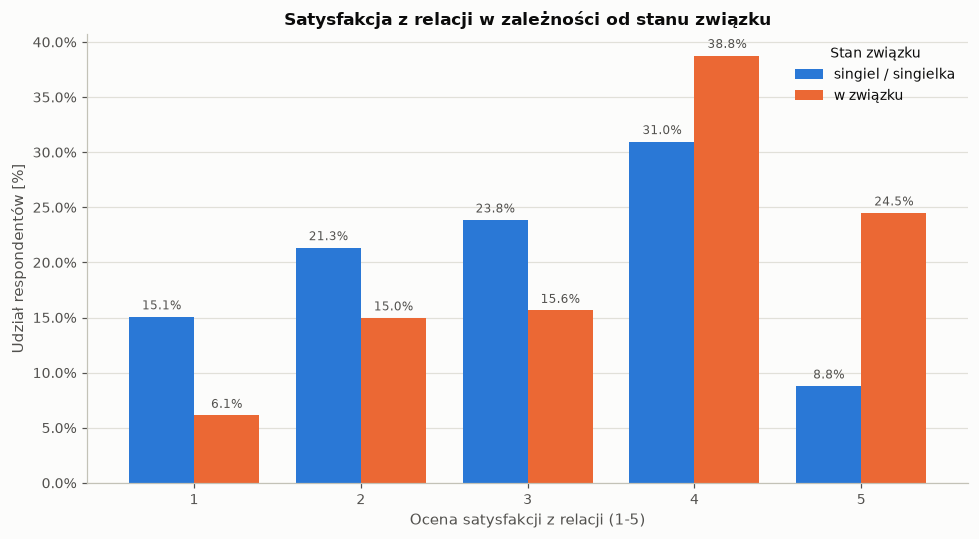

In [57]:
wynik = st.run_mannwhitney(df_zwiazek, group="stan_cywilny", outcome="sat_relacje")
display(rp.mann_whitney(wynik))

_ = pl.plot_distribution_by_group(
    df_zwiazek,
    column="sat_relacje",
    groupby="stan_cywilny",
    title="Satysfakcja z relacji w zależności od stanu związku",
    xlabel="Ocena satysfakcji z relacji (1-5)",
    legend_title="Stan związku",
)

Osoby pozostające w związku częściej deklarowały wysoką satysfakcję z relacji niż osoby niebędące w związku. Mediana satysfakcji wynosiła odpowiednio 4 i 3, przy małej wielkości efektu (r₍rb₎ = -0,293). Rozkład odpowiedzi wskazuje, że wśród osób pozostających w związku dominowały najwyższe oceny satysfakcji - 38,8% respondentów wybrało ocenę 4, a 24,5% ocenę 5. W grupie singli najwyższa była również częstość odpowiedzi 4 (31,0%), jednak znacznie rzadziej wybierano ocenę 5 (8,8%), a częściej pojawiały się oceny niższe (1-3). Wyniki wskazują zatem, że pozostawanie w związku wiąże się z wyższą oceną satysfakcji z relacji.

## 7.5 Wsparcie społeczne a dobrostan

W kolejnym etapie przeanalizowano związek pomiędzy odczuwanym poziomem wsparcia społecznego a dobrostanem badanych. W tym celu oceniono zależność pomiędzy poziomem wsparcia społecznego a satysfakcją z poszczególnych obszarów życia oraz poziomem odczuwanego stresu.

,Obszar,N,ρ,p (FDR),Istotna?,Uwaga
0,Ogólny wskaźnik satysfakcji,396,"0,416","<0,001",Tak,zależność część-całość
1,Satysfakcja z życia,396,"0,388","<0,001",Tak,
2,Satysfakcja z relacji,396,"0,370","<0,001",Tak,
3,Zdrowie psychiczne,396,"0,342","<0,001",Tak,
4,Poziom stresu,396,"-0,191","<0,001",Tak,


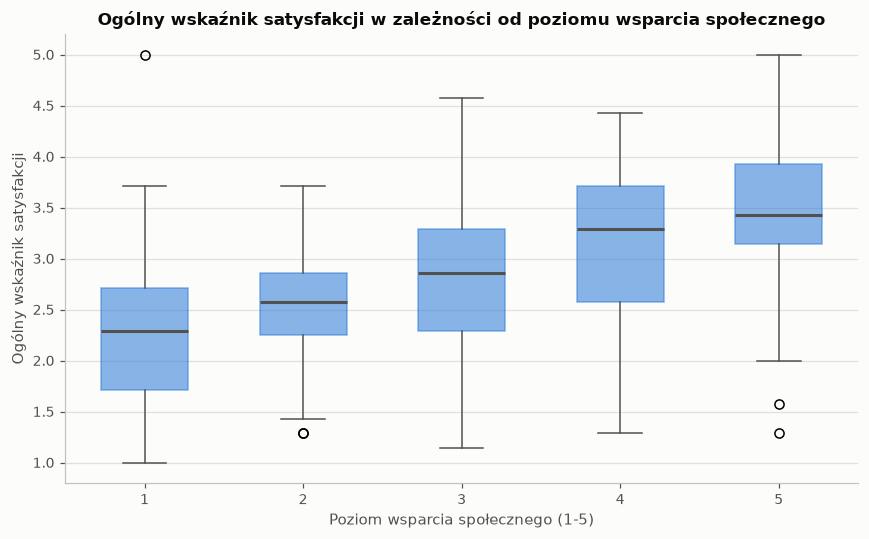

In [58]:
OBSZARY_WSPARCIA = [
    "sat_zycie",
    "sat_zdrowie_psych",
    "sat_relacje",
    "poziom_stresu",
    "sat_srednia",
]

wyniki = st.correlation_table(df, "poziom_wsparcia", OBSZARY_WSPARCIA)
display(rp.correlations(wyniki))

_ = pl.plot_box(
    df,
    x="poziom_wsparcia",
    y="sat_srednia",
    title="Ogólny wskaźnik satysfakcji w zależności od poziomu wsparcia społecznego",
    xlabel="Poziom wsparcia społecznego (1-5)",
    ylabel="Ogólny wskaźnik satysfakcji",
)

Analiza korelacji rang Spearmana wykazała, że odczuwany poziom wsparcia społecznego był istotnie związany ze wszystkimi analizowanymi wskaźnikami dobrostanu, również po korekcie Benjaminiego-Hochberga. Umiarkowane dodatnie zależności odnotowano dla satysfakcji z życia (ρ = 0,388), satysfakcji z relacji (ρ = 0,370) oraz zdrowia psychicznego (ρ = 0,343). Poziom wsparcia wykazywał też słabą ujemną korelację z poziomem stresu (ρ = -0,191).

Najwyższą wartość współczynnika uzyskano dla ogólnego wskaźnika satysfakcji (ρ = 0,416), jednak wskaźnik ten jest średnią z pozostałych wymiarów satysfakcji, w tym z satysfakcji z relacji. Jego korelacja nie stanowi więc odrębnego ustalenia, tylko zagregowaną powtórkę pozostałych wierszy tabeli — w zestawieniu oznaczono ją jako zależność część-całość.

Wykres pokazuje, że wraz ze wzrostem deklarowanego wsparcia rośnie ogólny poziom satysfakcji. Mediana wskaźnika systematycznie zwiększa się od osób deklarujących najniższy poziom wsparcia do odczuwających je najsilniej. Mimo częściowego nakładania się rozkładów w sąsiednich kategoriach obserwowany trend jest wyraźny.

## 7.6 Podsumowanie

Przeprowadzone analizy wskazują, że relacje społeczne stanowią istotny element dobrostanu badanych. Zarówno liczba bliskich znajomych, jak i częstość spotkań z nimi były dodatnio związane z satysfakcją z relacji. Jednocześnie uzyskane wyniki sugerują, że znaczenie ma nie tylko wielkość sieci społecznej, ale również jakość i regularność utrzymywanych kontaktów. Największy wzrost satysfakcji obserwowano po zwiększeniu liczby bliskich znajomych do około 3-5 osób, natomiast dalsze powiększanie tej grupy nie wiązało się już z istotną poprawą zadowolenia z relacji. Ponadto częstsze spotkania wzmacniały dodatni wpływ liczby bliskich znajomych na satysfakcję z relacji.

Analiza stanu związku wykazała, że osoby pozostające w relacji deklarowały wyższą satysfakcję z relacji niż osoby niebędące w związku, przy czym różnica ta nie przekładała się na pozostałe analizowane obszary dobrostanu. Z kolei odczuwane wsparcie społeczne okazało się konsekwentnie związane z wyższym poziomem dobrostanu - osoby deklarujące większe wsparcie osiągały wyższe wyniki zarówno w zakresie ogólnej satysfakcji z życia, zdrowia psychicznego, jak również charakteryzowały się niższym poziomem odczuwanego stresu.

Uzyskane wyniki wskazują, że dobrostan badanych jest związany nie tyle z samym posiadaniem rozbudowanej sieci kontaktów społecznych, ile przede wszystkim z możliwością utrzymywania bliskich i regularnych relacji oraz odczuwaniem wsparcia ze strony innych osób. Spośród analizowanych aspektów relacji społecznych najszerszy związek z dobrostanem wykazywało właśnie wsparcie społeczne, które pozostawało istotnie powiązane ze wszystkimi analizowanymi wskaźnikami.

---

# 8. Studia i zaangażowanie akademickie

W tej części przeanalizowano zależności pomiędzy aktywnością akademicką studentów a dobrostanem. Uwzględniono tygodniowy czas poświęcany na naukę, średnią ocen oraz aktywność w organizacjach studenckich.

## 8.1 Aktywność akademicka w badanej próbie

Pierwszym krokiem analizy było przedstawienie rozkładu odpowiedzi dotyczących aktywności akademickiej respondentów. Pozwala to scharakteryzować badaną próbę oraz ocenić liczebność poszczególnych kategorii przed przeprowadzeniem dalszych analiz.

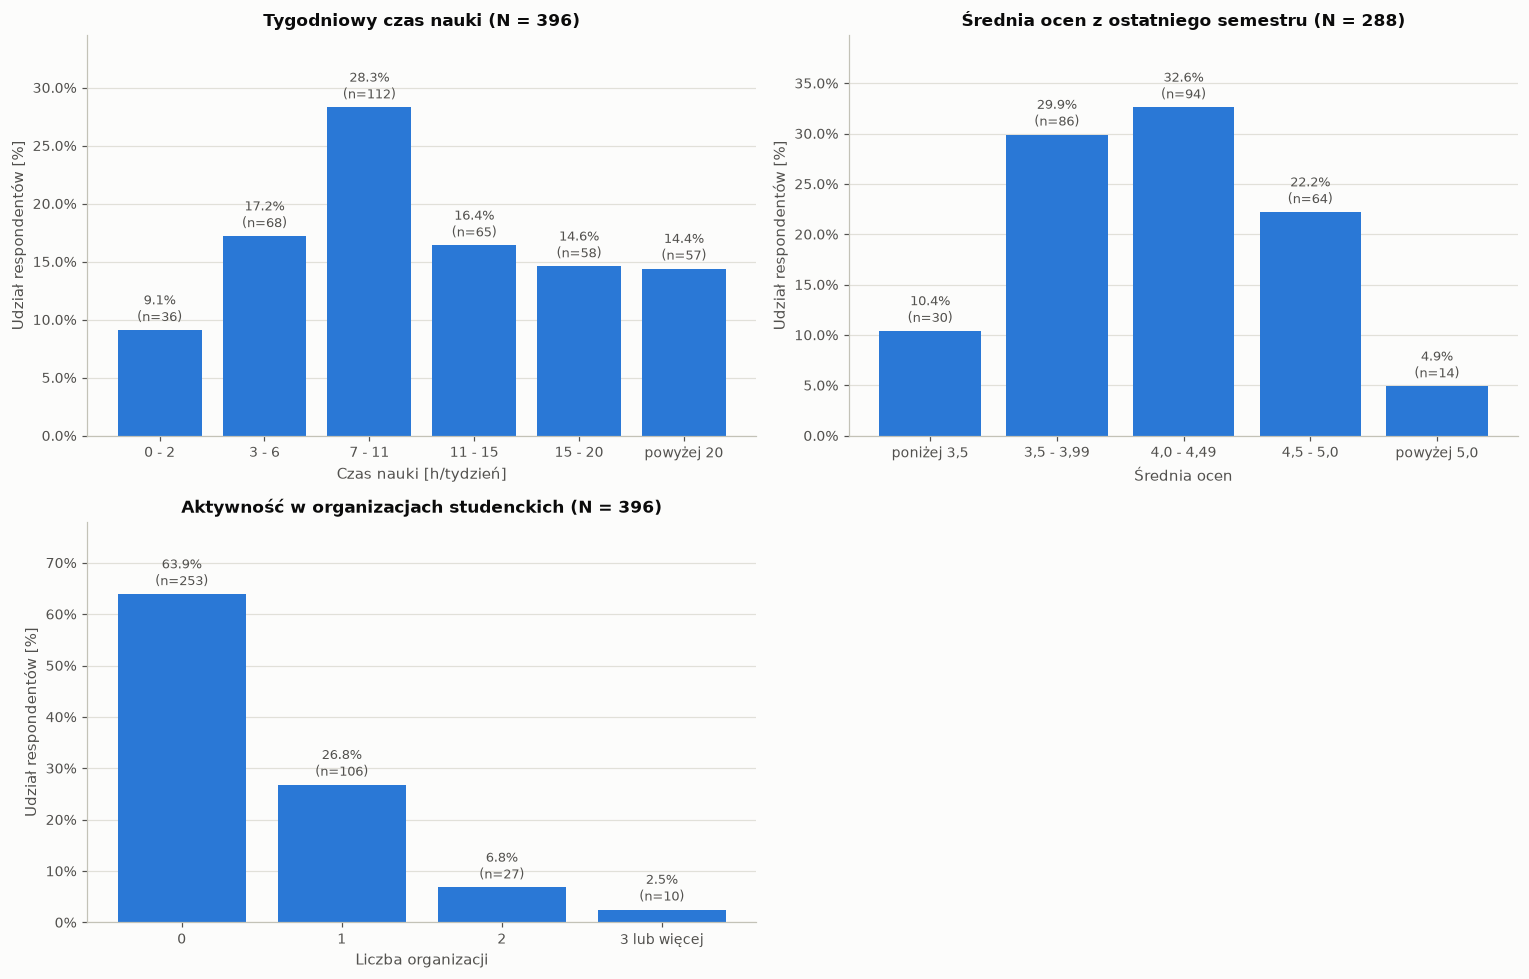

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

pl.plot_distribution(
    df, "nauka_h_tydz",
    value_labels=WARTOSCI("nauka_h_tydz"),
    title="Tygodniowy czas nauki",
    xlabel="Czas nauki [h/tydzień]",
    ax=axes[0, 0],
)
pl.plot_distribution(
    df, "srednia_ocen",
    value_labels=WARTOSCI("srednia_ocen"),
    na_label="I semestr\n(brak ocen)",
    title="Średnia ocen z ostatniego semestru",
    xlabel="Średnia ocen",
    wrap=12,
    ax=axes[0, 1],
)
pl.plot_distribution(
    df, "liczba_organizacji",
    value_labels=WARTOSCI("liczba_organizacji"),
    title="Aktywność w organizacjach studenckich",
    xlabel="Liczba organizacji",
    ax=axes[1, 0],
)

axes[1, 1].axis("off")
fig.tight_layout()

Wśród badanych najliczniejszą grupę stanowili studenci deklarujący przeznaczanie na naukę od 7 do 11 godzin tygodniowo (28,3%), natomiast najmniej liczni byli respondenci uczący się od 0 do 2 godzin tygodniowo (9,1%). W przypadku średniej ocen największy odsetek stanowili studenci pierwszego semestru, którzy nie posiadali jeszcze ocen (27,3%). Spośród pozostałych respondentów najczęściej deklarowano średnią ocen w przedziale 4,0-4,49 (23,7%) oraz 3,5-3,99 (21,7%), natomiast najwyższą kategorię ocen (powyżej 5,0) wskazało 3,5% badanych. Większość respondentów nie należała do żadnej organizacji studenckiej (63,9%), natomiast 26,8% deklarowało członkostwo w jednej organizacji. Udział osób angażujących się w dwie lub więcej organizacji był wyraźnie niższy.

## 8.2 Czas nauki a dobrostan

W kolejnym etapie analiz zbadano zależność pomiędzy tygodniowym czasem poświęcanym na naukę a dobrostanem respondentów. Analizie poddano zarówno ogólny poziom dobrostanu oraz jego poszczególne wymiary, jak i satysfakcję ze studiów, która stanowiła bardziej bezpośredni wskaźnik funkcjonowania w środowisku akademickim.

In [60]:
OBSZARY_AKADEMICKIE = [
    "sat_zycie",
    "sat_zdrowie_psych",
    "sat_relacje",
    "sat_studia",
    "sat_czas_wolny",
    "poziom_stresu",
    "sat_srednia",
]

wyniki = st.correlation_table(df, "nauka_h_tydz", OBSZARY_AKADEMICKIE)
display(rp.correlations(wyniki))

,Obszar,N,ρ,p (FDR),Istotna?,Uwaga
0,Satysfakcja z czasu wolnego,396,"-0,211","<0,001",Tak,
1,Satysfakcja ze studiów,396,"0,154","0,007",Tak,
2,Satysfakcja z relacji,396,"0,111","0,062",Nie,
3,Poziom stresu,396,"0,100","0,076",Nie,
4,Satysfakcja z życia,396,"0,097","0,076",Nie,
5,Ogólny wskaźnik satysfakcji,396,"0,039","0,513",Nie,zależność część-całość
6,Zdrowie psychiczne,396,"0,015","0,772",Nie,


Po zastosowaniu korekty FDR istotne statystycznie zależności uzyskano jedynie dla satysfakcji z czasu wolnego oraz satysfakcji ze studiów. Silniejszą zależność odnotowano w przypadku satysfakcji z czasu wolnego, dla której stwierdzono słabą ujemną korelację (ρ = -0,211; p < 0,001). W przypadku satysfakcji ze studiów zaobserwowano słabą dodatnią korelację (ρ = 0,154; p = 0,007). Dla pozostałych analizowanych zmiennych nie uzyskano dowodów na istotne zależności.

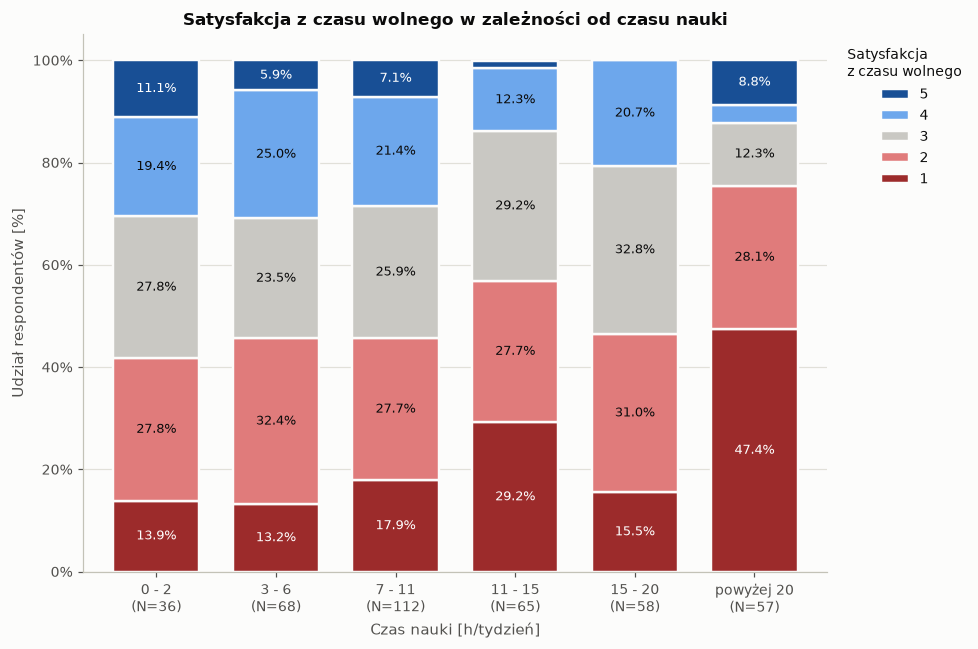

In [61]:
_ = pl.plot_stacked_likert(
    df,
    x="nauka_h_tydz",
    y="sat_czas_wolny",
    x_labels=WARTOSCI("nauka_h_tydz"),
    title="Satysfakcja z czasu wolnego w zależności od czasu nauki",
    xlabel="Czas nauki [h/tydzień]",
    legend_title="Satysfakcja\nz czasu wolnego",
)

Rozkład odpowiedzi nie wskazuje na wyraźnie monotoniczną zależność pomiędzy analizowanymi zmiennymi. Mimo pewnych wahań pomiędzy poszczególnymi kategoriami czasu nauki, w grupie respondentów poświęcających na naukę ponad 20 godzin tygodniowo widoczny jest wyraźny wzrost odsetka osób deklarujących najniższą satysfakcję z czasu wolnego oraz spadek udziału najwyższych ocen. Obserwacja ta jest zgodna z uzyskaną słabą ujemną korelacją.

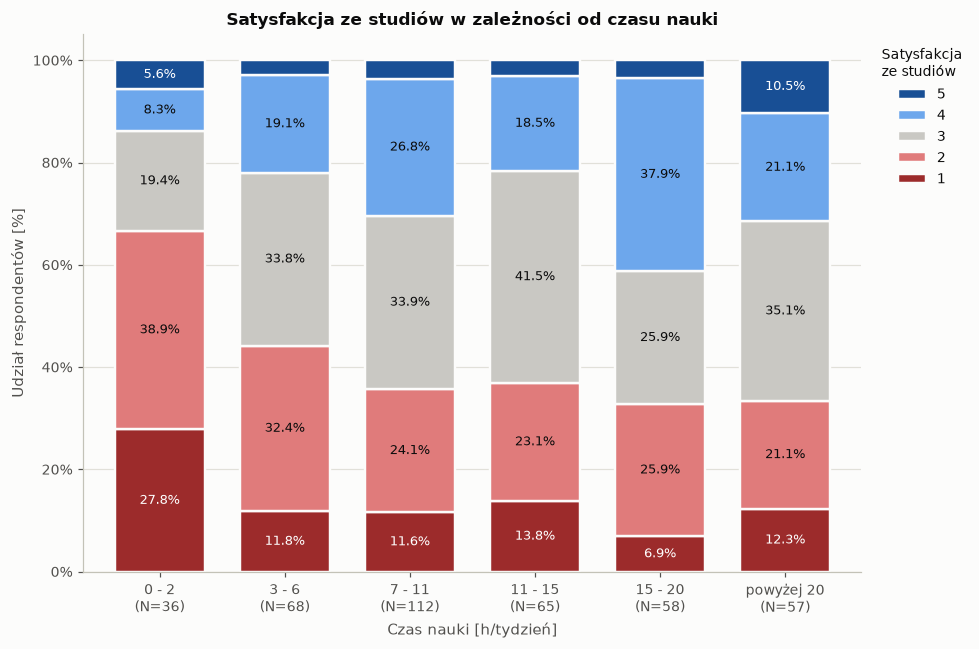

In [62]:
_ = pl.plot_stacked_likert(
    df,
    x="nauka_h_tydz",
    y="sat_studia",
    x_labels=WARTOSCI("nauka_h_tydz"),
    title="Satysfakcja ze studiów w zależności od czasu nauki",
    xlabel="Czas nauki [h/tydzień]",
    legend_title="Satysfakcja\nze studiów",
)

Rozkład odpowiedzi wskazuje, że respondenci poświęcający na naukę od 0 do 2 godzin tygodniowo częściej deklarowali niską satysfakcję ze studiów (oceny 1-2) niż osoby przeznaczające na naukę większą liczbę godzin. W pozostałych grupach udział ocen niskich był wyraźnie mniejszy, natomiast częściej występowały oceny umiarkowane i wysokie. Jednocześnie różnice pomiędzy kategoriami obejmującymi więcej niż 3 godziny nauki tygodniowo były mniej wyraźne, co odpowiada słabej dodatniej sile uzyskanej korelacji.

## 8.3 Średnia ocen a dobrostan

W kolejnym etapie analiz zbadano zależność pomiędzy średnią ocen z ostatniego semestru a dobrostanem respondentów. Oceniono jej związek zarówno z ogólnym poziomem dobrostanu oraz jego poszczególnymi wymiarami, jak i z satysfakcją ze studiów, stanowiącą bardziej bezpośredni wskaźnik funkcjonowania w środowisku akademickim.

In [63]:
wyniki = st.correlation_table(df, "srednia_ocen", OBSZARY_AKADEMICKIE)
display(rp.correlations(wyniki))

,Obszar,N,ρ,p (FDR),Istotna?,Uwaga
0,Satysfakcja ze studiów,288,"0,260","<0,001",Tak,
1,Ogólny wskaźnik satysfakcji,288,"0,247","<0,001",Tak,zależność część-całość
2,Zdrowie psychiczne,288,"0,178","0,006",Tak,
3,Satysfakcja z życia,288,"0,135","0,038",Tak,
4,Poziom stresu,288,"-0,107","0,097",Nie,
5,Satysfakcja z relacji,288,"0,096","0,105",Nie,
6,Satysfakcja z czasu wolnego,288,"0,096","0,105",Nie,


Wyniki sugerują, że wyższa średnia ocen wiązała się przede wszystkim z większą satysfakcją ze studiów oraz wyższym ogólnym poziomem satysfakcji. Zależności ze zdrowiem psychicznym i satysfakcją z życia były słabsze, natomiast dla pozostałych analizowanych zmiennych nie uzyskano dowodów na istotny związek po zastosowaniu korekty FDR.

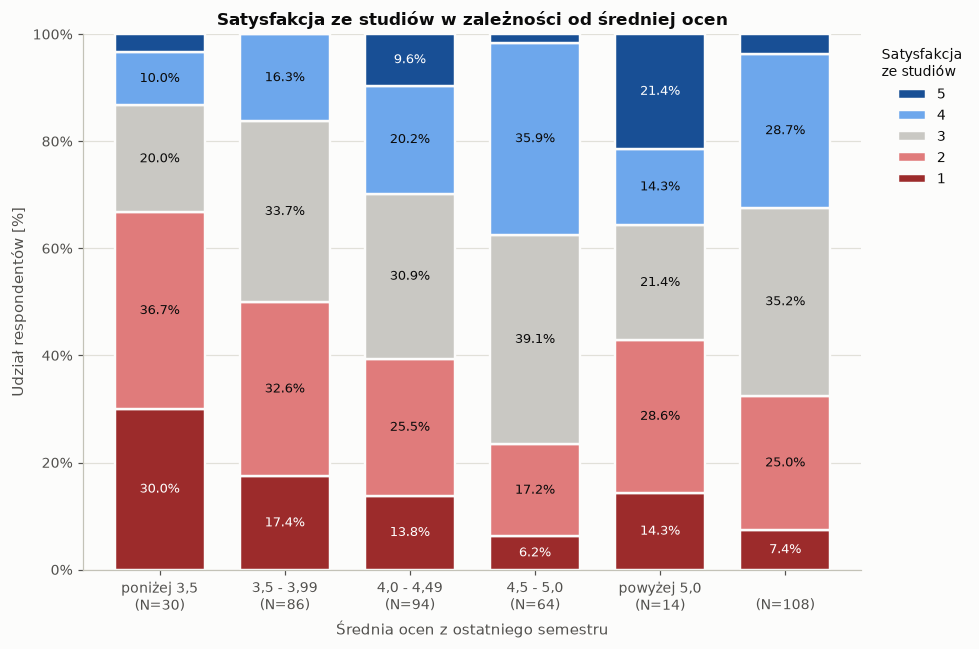

In [64]:
_ = pl.plot_stacked_likert(
    df,
    x="srednia_ocen",
    y="sat_studia",
    x_labels=WARTOSCI("srednia_ocen"),
    title="Satysfakcja ze studiów w zależności od średniej ocen",
    xlabel="Średnia ocen z ostatniego semestru",
    legend_title="Satysfakcja\nze studiów",
)

W grupie respondentów ze średnią ocen poniżej 3,5 dominowały niskie oceny satysfakcji ze studiów (1-2), natomiast w kolejnych kategoriach średnich ocen ich udział stopniowo malał na rzecz ocen wyższych (4-5). Tendencja ta jest szczególnie widoczna po przekroczeniu średniej 4,0, choć w grupie osób ze średnią powyżej 5,0 interpretację ogranicza niewielka liczebność próby (N = 14). Wyniki te pozostają zgodne z uzyskaną słabą dodatnią korelacją.

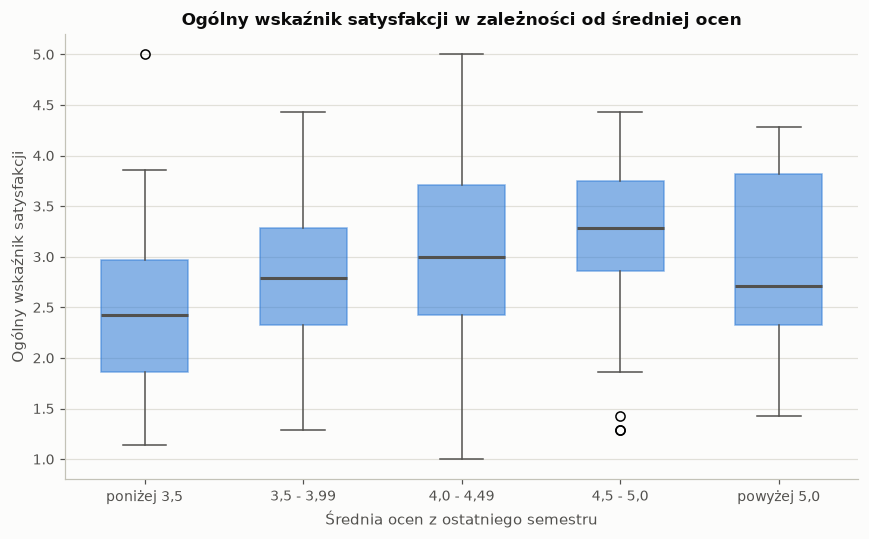

In [65]:
_ = pl.plot_box(
    df,
    x="srednia_ocen",
    y="sat_srednia",
    x_labels=WARTOSCI("srednia_ocen"),
    title="Ogólny wskaźnik satysfakcji w zależności od średniej ocen",
    xlabel="Średnia ocen z ostatniego semestru",
    ylabel="Ogólny wskaźnik satysfakcji",
)

Wraz ze wzrostem średniej ocen widoczna jest ogólna tendencja do osiągania wyższych wartości ogólnego wskaźnika satysfakcji, choć zależność ta nie ma jednoznacznie monotonicznego charakteru. Rozkłady wyników w poszczególnych grupach w znacznym stopniu się pokrywają, co wskazuje na dużą zmienność odpowiedzi. Wyniki te są zgodne z uzyskaną słabą dodatnią korelacją.

## 8.4 Aktywność w organizacjach studenckich

W ostatnim etapie analiz zbadano, czy przynależność do organizacji studenckich wiąże się z dobrostanem respondentów. Ze względu na niewielką liczebność osób należących do więcej niż jednej organizacji respondentów podzielono na dwie grupy: osoby nienależące do żadnej organizacji oraz osoby należące do co najmniej jednej organizacji.

In [66]:
# Osoby należące do więcej niż jednej organizacji są nieliczne — dzielimy
# próbę na należących i nienależących do żadnej.
# Kolumna trafia do lokalnej kopii, żeby nie modyfikować przygotowanego zbioru.
df_organizacje = df.assign(
    grupa_organizacje=np.where(df["liczba_organizacji"] == 0, "0 organizacji", "≥1 organizacja")
)

In [67]:
display(rp.group_sizes(df_organizacje["grupa_organizacje"]))

wyniki = st.comparison_table(df_organizacje, "grupa_organizacje", OBSZARY_AKADEMICKIE)
display(rp.comparisons(wyniki))

,Liczebność
Grupa,
0 organizacji,253
≥1 organizacja,143


,Obszar,p (FDR),|r_rb|,Siła efektu,Różnica istotna?
0,Satysfakcja z życia,"<0,001","0,237",mały,Tak
1,Ogólny wskaźnik satysfakcji,"0,015","0,173",mały,Tak
2,Zdrowie psychiczne,"0,050","0,135",mały,Nie
3,Satysfakcja ze studiów,"0,070","0,120",mały,Nie
4,Satysfakcja z czasu wolnego,"0,108","0,104",mały,Nie
5,Satysfakcja z relacji,"0,195","0,081",pomijalny,Nie
6,Poziom stresu,"0,346","0,055",pomijalny,Nie


W badanej próbie 253 respondentów (63,9%) nie należało do żadnej organizacji studenckiej, natomiast 143 osoby (36,1%) deklarowały przynależność do co najmniej jednej organizacji. Wyniki wskazują, że osoby angażujące się w działalność organizacji studenckich osiągały wyższe wyniki w zakresie satysfakcji z życia oraz ogólnego wskaźnika satysfakcji. Nie uzyskano natomiast dowodów na istotne różnice w zakresie zdrowia psychicznego, satysfakcji ze studiów, satysfakcji z czasu wolnego, satysfakcji z relacji ani poziomu stresu.

,Grupa 1,Grupa 2,N₁,N₂,Mediana 1,Mediana 2,U,p,r_rb,Siła efektu
0,0 organizacji,≥1 organizacja,253,143,"3,0","4,0","13806,5","<0,001","-0,237",mały


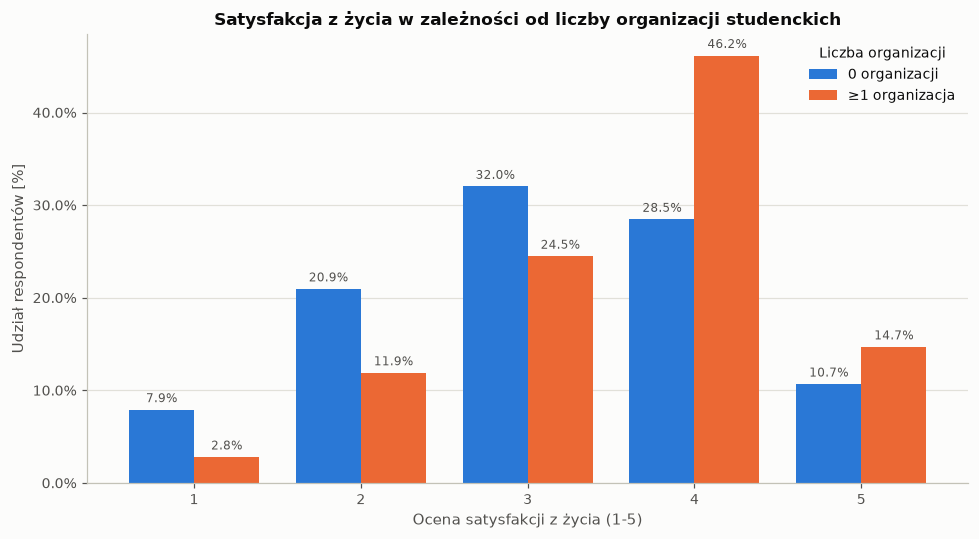

In [68]:
wynik = st.run_mannwhitney(df_organizacje, group="grupa_organizacje", outcome="sat_zycie")
display(rp.mann_whitney(wynik))

_ = pl.plot_distribution_by_group(
    df_organizacje,
    column="sat_zycie",
    groupby="grupa_organizacje",
    title="Satysfakcja z życia w zależności od liczby organizacji studenckich",
    xlabel="Ocena satysfakcji z życia (1-5)",
    legend_title="Liczba organizacji",
)

Respondenci należący do co najmniej jednej organizacji studenckiej częściej oceniali swoje zadowolenie z życia wysoko (oceny 4-5), natomiast osoby nieangażujące się w działalność organizacji częściej wybierały oceny niższe (1-3). Największa różnica dotyczyła oceny 4, którą wskazało 46,2% osób należących do organizacji oraz 28,5% osób nienależących do żadnej organizacji. Wyniki te są zgodne z uzyskanym istotnym wynikiem testu Manna-Whitneya.

## 8.5 Podsumowanie

Przeprowadzone analizy wykazały, że poszczególne aspekty aktywności akademickiej wiązały się z dobrostanem w odmiennym zakresie. Tygodniowy czas poświęcany na naukę był związany przede wszystkim z większą satysfakcją ze studiów, jednak jednocześnie osoby uczące się najwięcej deklarowały niższą satysfakcję z czasu wolnego. Najwięcej istotnych zależności odnotowano dla średniej ocen z ostatniego semestru - wyższe wyniki w nauce współwystępowały z większą satysfakcją ze studiów, wyższym ogólnym poziomem satysfakcji, lepszym zdrowiem psychicznym oraz większą satysfakcją z życia. Z kolei osoby należące do co najmniej jednej organizacji studenckiej częściej deklarowały wyższą satysfakcję z życia oraz wyższy ogólny poziom satysfakcji niż respondenci nieangażujący się w działalność organizacji. Wyniki wskazują, że aktywność akademicka nie była związana z dobrostanem w jednakowym stopniu - najszerszy zakres istotnych zależności zaobserwowano dla średniej ocen.

---

# 9. Praca i finanse

W niniejszym rozdziale przeanalizowano zależności pomiędzy aktywnością zawodową oraz sytuacją finansową studentów a dobrostanem. Uwzględniono fakt podejmowania pracy, stopień jej zgodności z kierunkiem studiów, subiektywną ocenę sytuacji finansowej oraz satysfakcję z sytuacji finansowej.

## 9.1 Praca i sytuacja finansowa w badanej próbie

Pierwszym krokiem analizy było przedstawienie charakterystyki respondentów pod względem aktywności zawodowej oraz sytuacji finansowej. Pozwala to scharakteryzować badaną próbę oraz ocenić liczebność poszczególnych kategorii przed przeprowadzeniem dalszych analiz.

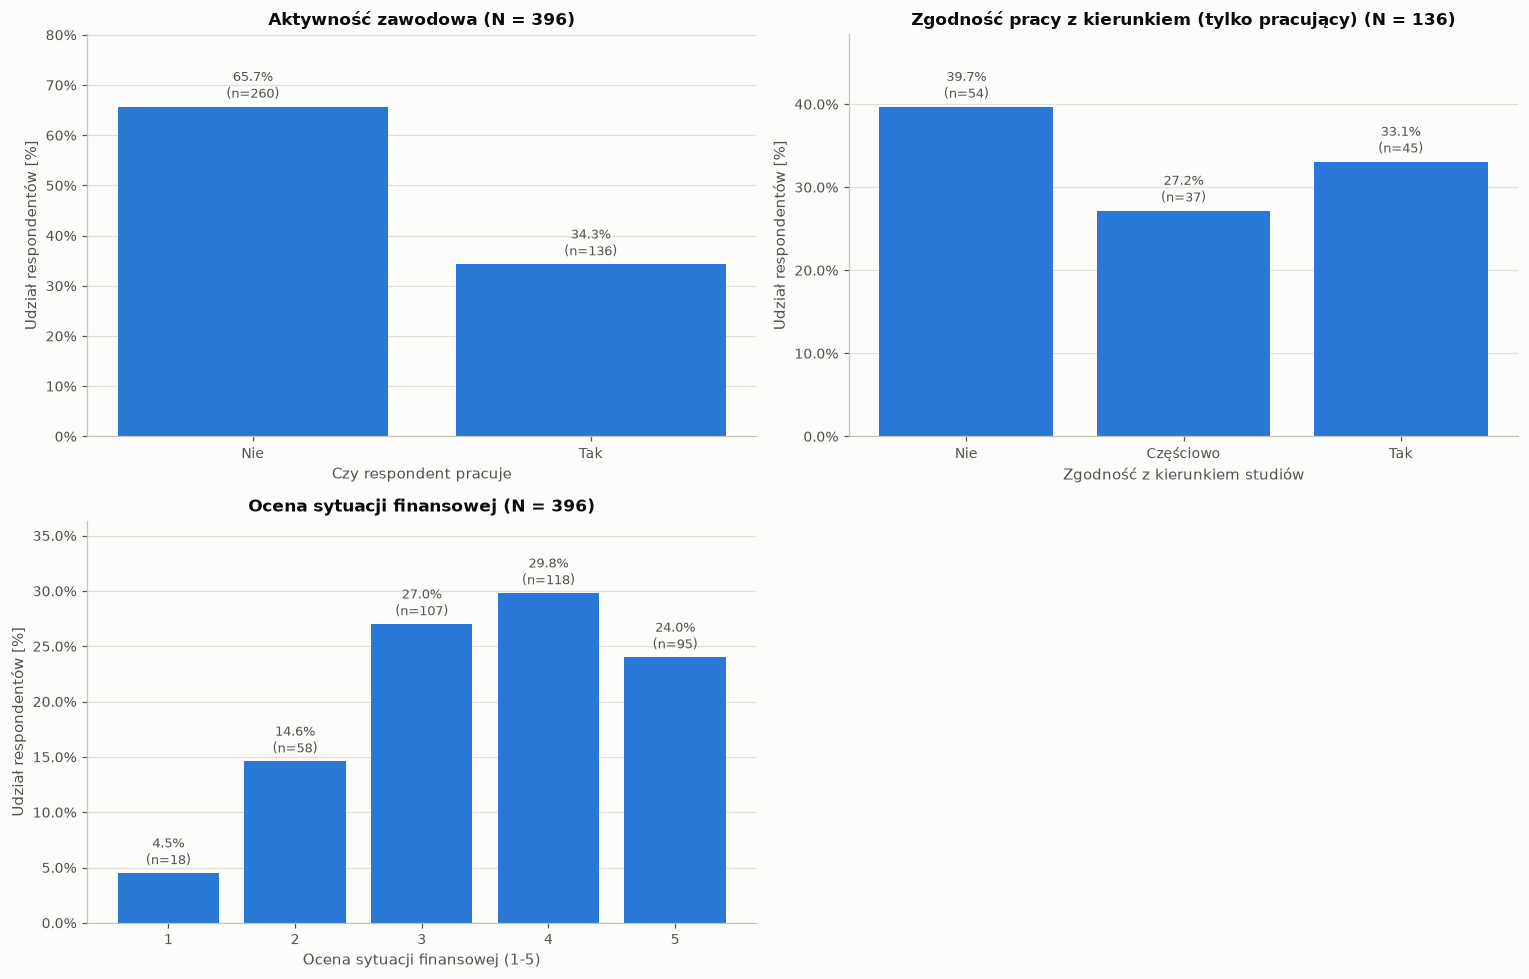

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

pl.plot_distribution(
    df, "czy_pracuje",
    value_labels=WARTOSCI("czy_pracuje"),
    title="Aktywność zawodowa",
    xlabel="Czy respondent pracuje",
    ax=axes[0, 0],
)
pl.plot_distribution(
    df_pracujacy, "praca_zgodna",
    value_labels=WARTOSCI("praca_zgodna"),
    title="Zgodność pracy z kierunkiem (tylko pracujący)",
    xlabel="Zgodność z kierunkiem studiów",
    ax=axes[0, 1],
)
pl.plot_distribution(
    df, "ocena_finansowa",
    title="Ocena sytuacji finansowej",
    xlabel="Ocena sytuacji finansowej (1-5)",
    ax=axes[1, 0],
)

axes[1, 1].axis("off")
fig.tight_layout()

W badanej próbie większość respondentów nie podejmowała pracy zawodowej, natomiast pracę deklarowało 34,3% studentów. Wśród osób pracujących najczęściej wskazywano brak zgodności wykonywanej pracy z kierunkiem studiów (39,7%), jednak odsetek osób pracujących w pełnej zgodności z kierunkiem był również wysoki (33,1%). Pracę częściowo zgodną z kierunkiem deklarowało 27,2% pracujących respondentów. W ocenie sytuacji finansowej dominowały odpowiedzi pozytywne - najczęściej wybierano ocenę 4 (29,8%), a następnie 3 (27,0%) i 5 (24,0%), natomiast najniższą ocenę wskazało 4,5% badanych.

## 9.2 Zgodność wykonywanej pracy z kierunkiem studiów

W kolejnym etapie analiz skoncentrowano się na zgodności wykonywanej pracy z kierunkiem studiów. W pierwszej kolejności sprawdzono, czy stopień zgodności różnił się pomiędzy wydziałami, a następnie oceniono jego związek z dobrostanem studentów.

### 9.2.1 Zróżnicowanie zgodności wykonywanej pracy pomiędzy wydziałami

W pierwszym kroku przeanalizowano, czy stopień zgodności wykonywanej pracy z kierunkiem studiów różnił się pomiędzy wydziałami. Analizę przeprowadzono wyłącznie wśród respondentów podejmujących pracę zawodową.

In [70]:
# Trzy najliczniej reprezentowane wydziały wobec reszty — pozostałe grupy
# byłyby zbyt małe na osobne porównania.
NAJWIEKSZE_WYDZIALY = ["Informatyki i Telekomunikacji", "Mechaniczny", "Matematyki"]

df_wydzialy = df_pracujacy.copy()
df_wydzialy["wydzial_grupa"] = df_wydzialy["wydzial"].where(
    df_wydzialy["wydzial"].isin(NAJWIEKSZE_WYDZIALY),
    "Pozostałe wydziały",
)

display(rp.group_sizes(df_wydzialy["wydzial_grupa"], name="Wydział"))

,Liczebność
Wydział,
Pozostałe wydziały,57
Matematyki,31
Informatyki i Telekomunikacji,24
Mechaniczny,24


,χ²,df,N,p,V Craméra
0,"43,25",6,136,"<0,001","0,399"


,Porównanie,p (FDR),Istotna?
0,Informatyki i Telekomunikacji vs Matematyki,"0,010",Tak
1,Informatyki i Telekomunikacji vs Mechaniczny,"<0,001",Tak
2,Matematyki vs Mechaniczny,"<0,001",Tak


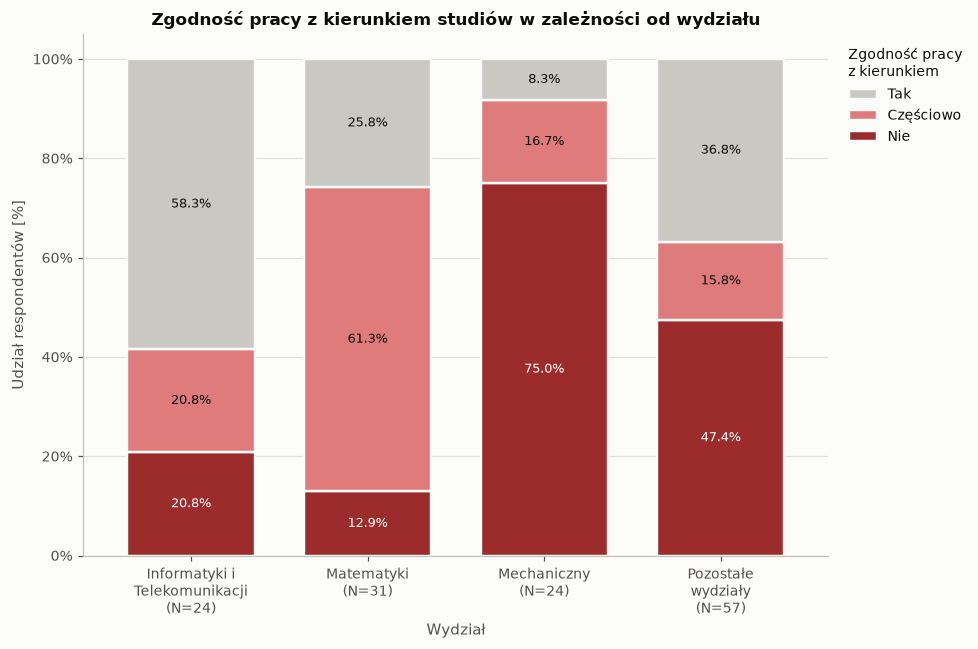

In [71]:
wynik, _tabela = st.run_chi2(df_wydzialy, "wydzial_grupa", "praca_zgodna")
display(rp.chi2(wynik))

# Porównania parami między trzema największymi wydziałami.
PARY = [
    ("Informatyki i Telekomunikacji", "Matematyki"),
    ("Informatyki i Telekomunikacji", "Mechaniczny"),
    ("Matematyki", "Mechaniczny"),
]

porownania = []
for pierwszy, drugi in PARY:
    podzbior = df_wydzialy[df_wydzialy["wydzial_grupa"].isin([pierwszy, drugi])]
    czastkowy, _ = st.run_chi2(podzbior, "wydzial_grupa", "praca_zgodna")
    czastkowy["porownanie"] = f"{pierwszy} vs {drugi}"
    porownania.append(czastkowy)

porownania = st.fdr_correction(pd.concat(porownania, ignore_index=True))
display(rp.dunn(porownania))

_ = pl.plot_stacked_likert(
    df_wydzialy,
    x="wydzial_grupa",
    y="praca_zgodna",
    y_labels=WARTOSCI("praca_zgodna"),
    title="Zgodność pracy z kierunkiem studiów w zależności od wydziału",
    xlabel="Wydział",
    legend_title="Zgodność pracy\nz kierunkiem",
    wrap=16,
)

Wyniki testu χ² wykazały istotny związek pomiędzy wydziałem a zgodnością wykonywanej pracy z kierunkiem studiów (χ² = 43,25; p < 0,001; V Craméra = 0,399), wskazując na umiarkowaną siłę zależności. W celu określenia, pomiędzy którymi wydziałami występowały różnice, przeprowadzono porównania post hoc z zastosowaniem korekty FDR. Istotne różnice odnotowano we wszystkich analizowanych parach wydziałów. Najbardziej wyraźne różnice dotyczyły porównań z Wydziałem Mechanicznym.

Analiza rozkładów odpowiedzi wskazuje, że studenci Wydziału Informatyki i Telekomunikacji najczęściej wykonywali pracę w pełni zgodną z kierunkiem studiów. Wśród studentów Wydziału Matematyki dominowała natomiast częściowa zgodność wykonywanej pracy z kierunkiem, podczas gdy na Wydziale Mechanicznym zdecydowanie najczęściej deklarowano brak zgodności. W pozostałych wydziałach rozkład odpowiedzi był trochę bardziej zrównoważony i nie wskazywał na pełną dominację jednej z kategorii.

### 9.2.2 Związek zgodności wykonywanej pracy z dobrostanem

W kolejnym etapie analiz zbadano, czy stopień zgodności wykonywanej pracy z kierunkiem studiów wiązał się z dobrostanem respondentów. Analizę przeprowadzono wyłącznie wśród studentów podejmujących pracę zawodową, porównując poziom dobrostanu pomiędzy osobami deklarującymi brak zgodności, częściową zgodność oraz pełną zgodność wykonywanej pracy z kierunkiem studiów.

In [72]:
OBSZARY_PRACY = [
    "sat_zycie",
    "sat_zdrowie_psych",
    "sat_relacje",
    "sat_studia",
    "sat_czas_wolny",
    "poziom_stresu",
    "sat_srednia",
]

wyniki = pd.concat(
    [st.run_kruskal(df_pracujacy, "praca_zgodna", obszar)[0] for obszar in OBSZARY_PRACY],
    ignore_index=True,
)
display(rp.kruskal(st.fdr_correction(wyniki)))

,Obszar,H,η²,p (FDR),Istotna?
0,Satysfakcja z życia,"4,24","0,017","0,210",Nie
1,Zdrowie psychiczne,"6,84","0,036","0,115",Nie
2,Satysfakcja z relacji,"2,15","0,001","0,396",Nie
3,Satysfakcja ze studiów,"10,59","0,065","0,035",Tak
4,Satysfakcja z czasu wolnego,"1,85","0,000","0,396",Nie
5,Poziom stresu,"2,36","0,003","0,396",Nie
6,Ogólny wskaźnik satysfakcji,"4,60","0,020","0,210",Nie


Po zastosowaniu korekty FDR istotne różnice pomiędzy grupami uzyskano jedynie dla satysfakcji ze studiów (H = 10,59; p = 0,035). Dla pozostałych analizowanych wymiarów dobrostanu nie uzyskano dowodów na istotne różnice. W związku z tym dalsze analizy post hoc przeprowadzono wyłącznie dla satysfakcji ze studiów.

,Porównanie,p (FDR),Istotna?
0,Nie.Nie vs Nie.5,"0,003",Tak
1,Nie.Nie vs Tak.Nie,"0,168",Nie
2,Nie.5 vs Tak.Nie,"0,091",Nie


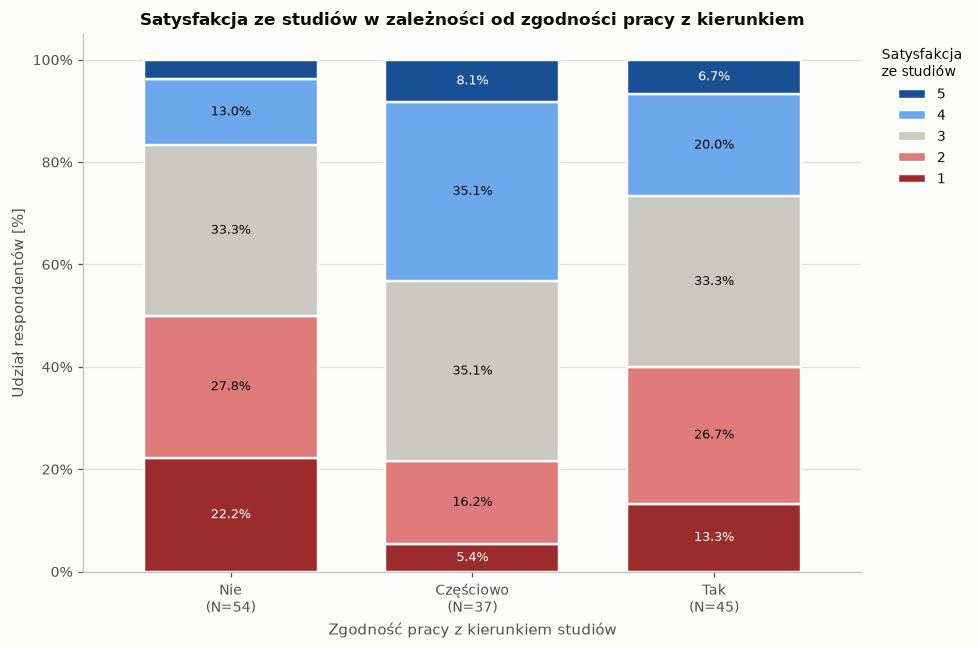

In [73]:
porownania = st.fdr_correction(st.run_dunn(df_pracujacy, "praca_zgodna", "sat_studia"))
display(rp.dunn(porownania, value_labels=WARTOSCI("praca_zgodna")))

_ = pl.plot_stacked_likert(
    df_pracujacy,
    x="praca_zgodna",
    y="sat_studia",
    x_labels=WARTOSCI("praca_zgodna"),
    title="Satysfakcja ze studiów w zależności od zgodności pracy z kierunkiem",
    xlabel="Zgodność pracy z kierunkiem studiów",
    legend_title="Satysfakcja\nze studiów",
)

Analiza post hoc z zastosowaniem testu Dunna wykazała istotną różnicę jedynie pomiędzy studentami wykonującymi pracę niezwiązaną z kierunkiem studiów a osobami deklarującymi częściową zgodność wykonywanej pracy z kierunkiem (p = 0,003). Nie uzyskano natomiast dowodów na istotne różnice pomiędzy studentami deklarującymi brak i pełną zgodność wykonywanej pracy z kierunkiem ani pomiędzy grupami częściowej i pełnej zgodności. Rozkład odpowiedzi wskazuje, że studenci deklarujący częściową zgodność wykonywanej pracy z kierunkiem rzadziej wybierali najniższą ocenę satysfakcji ze studiów (5,4%) oraz częściej oceniali ją na poziomie 4 (35,1%) niż osoby wykonujące pracę niezwiązaną z kierunkiem studiów. W grupie deklarującej pełną zgodność wykonywanej pracy z kierunkiem również często pojawiały się wyższe oceny satysfakcji ze studiów, jednak rozkład odpowiedzi był bardziej zbliżony do pozostałych grup, co znajduje odzwierciedlenie w braku istotnych różnic w analizie post hoc.

## 9.3 Pracujący vs niepracujący

W kolejnym etapie analiz zbadano różnice w poziomie dobrostanu pomiędzy studentami podejmującymi pracę zawodową a osobami niepracującymi. Analizie poddano zarówno ogólny poziom dobrostanu, jak i jego poszczególne wymiary.

In [74]:
wyniki = st.comparison_table(df, "czy_pracuje", OBSZARY_PRACY)
display(rp.comparisons(wyniki))

,Obszar,p (FDR),|r_rb|,Siła efektu,Różnica istotna?
0,Satysfakcja z czasu wolnego,"0,064","0,155",mały,Nie
1,Zdrowie psychiczne,"0,100","0,131",mały,Nie
2,Satysfakcja z relacji,"0,526","0,072",pomijalny,Nie
3,Satysfakcja z życia,"0,638","0,036",pomijalny,Nie
4,Ogólny wskaźnik satysfakcji,"0,638","0,049",pomijalny,Nie
5,Poziom stresu,"0,638","0,036",pomijalny,Nie
6,Satysfakcja ze studiów,"0,915","0,006",pomijalny,Nie


Wyniki porównania osób pracujących i niepracujących nie wykazały istotnych różnic w żadnym z analizowanych wymiarów dobrostanu po zastosowaniu korekty FDR. Choć najniższe wartości p uzyskano dla satysfakcji z czasu wolnego oraz zdrowia psychicznego, również w tych przypadkach nie uzyskano dowodów na istotne różnice pomiędzy grupami.

## 9.4 Ocena sytuacji finansowej

W ostatnim etapie analiz zbadano zależności pomiędzy subiektywną oceną sytuacji finansowej studentów a dobrostanem. Oceniono związek oceny sytuacji finansowej z ogólnym poziomem dobrostanu oraz jego poszczególnymi wymiarami.

In [75]:
wyniki = st.correlation_table(df, "ocena_finansowa", OBSZARY_PRACY)
display(rp.correlations(wyniki))

,Obszar,N,ρ,p (FDR),Istotna?,Uwaga
0,Ogólny wskaźnik satysfakcji,396,"0,381","<0,001",Tak,zależność część-całość
1,Satysfakcja z życia,396,"0,249","<0,001",Tak,
2,Zdrowie psychiczne,396,"0,204","<0,001",Tak,
3,Satysfakcja z czasu wolnego,396,"0,181","<0,001",Tak,
4,Poziom stresu,396,"-0,128","0,013",Tak,
5,Satysfakcja ze studiów,396,"0,128","0,013",Tak,
6,Satysfakcja z relacji,396,"0,116","0,021",Tak,


Po korekcie Benjaminiego-Hochberga istotne zależności uzyskano dla wszystkich analizowanych wymiarów dobrostanu. Dodatnie korelacje odnotowano dla satysfakcji z życia (ρ = 0,249), zdrowia psychicznego (ρ = 0,204), satysfakcji z czasu wolnego (ρ = 0,181), satysfakcji ze studiów (ρ = 0,128) oraz satysfakcji z relacji (ρ = 0,116). Jedyną zależność ujemną zaobserwowano dla poziomu stresu (ρ = -0,128) — lepsza ocena własnej sytuacji finansowej wiązała się z niższym poziomem odczuwanego stresu.

Najwyższy współczynnik przypadł ogólnemu wskaźnikowi satysfakcji (ρ = 0,381), ale podobnie jak w rozdziale 7.5 jest to zależność część-całość: wskaźnik zawiera satysfakcję finansową, która mierzy niemal ten sam konstrukt co ocena sytuacji finansowej. Wartość ta jest zatem zawyżona z konstrukcji wskaźnika i nie powinna być czytana jako najsilniejszy wynik w tabeli.

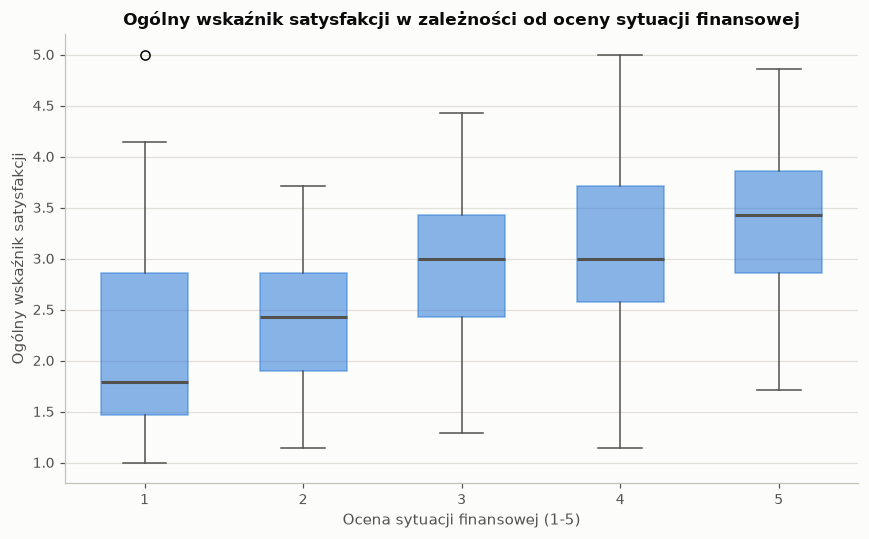

In [76]:
_ = pl.plot_box(
    df,
    x="ocena_finansowa",
    y="sat_srednia",
    title="Ogólny wskaźnik satysfakcji w zależności od oceny sytuacji finansowej",
    xlabel="Ocena sytuacji finansowej (1-5)",
    ylabel="Ogólny wskaźnik satysfakcji",
)

Wraz ze wzrostem oceny sytuacji finansowej widoczny jest stopniowy wzrost mediany ogólnego wskaźnika satysfakcji. Jednocześnie rozkłady odpowiedzi w poszczególnych grupach częściowo się nakładają, wskazując na zróżnicowanie indywidualnych wyników w obrębie każdej z kategorii oceny sytuacji finansowej.

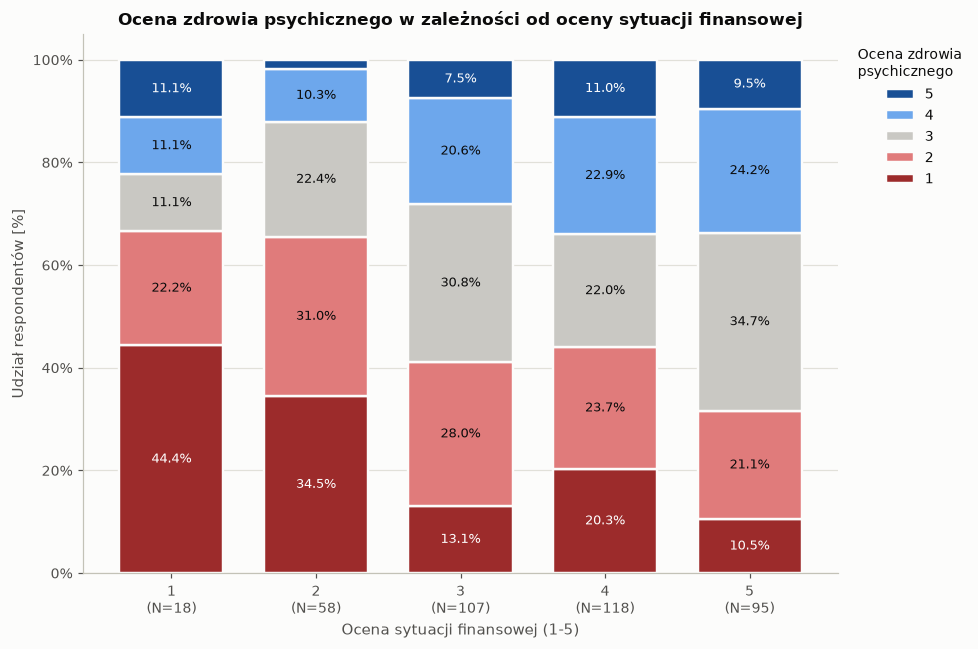

In [77]:
_ = pl.plot_stacked_likert(
    df,
    x="ocena_finansowa",
    y="sat_zdrowie_psych",
    title="Ocena zdrowia psychicznego w zależności od oceny sytuacji finansowej",
    xlabel="Ocena sytuacji finansowej (1-5)",
    legend_title="Ocena zdrowia\npsychicznego",
)

W grupach wyżej oceniających swoją sytuację finansową częściej występowały wysokie oceny zdrowia psychicznego, choć zmiany między kolejnymi kategoriami nie mają w pełni monotonicznego charakteru. Największy udział najwyższych ocen zdrowia psychicznego obserwowano wśród studentów oceniających swoją sytuację finansową na 5.

Wykres obejmuje całą próbę (N = 396), spójnie z tabelą korelacji powyżej. W poprzedniej wersji raportu rysowano go na podpróbie osób pracujących, przez co liczebności pod wykresem nie odpowiadały tabeli — najniższa ocena sytuacji finansowej obejmowała tam 2 osoby, podczas gdy w całej próbie jest ich 18.

## 9.5 Podsumowanie

Uzyskane wyniki wskazują, że poszczególne aspekty aktywności zawodowej oraz sytuacji finansowej wiązały się z dobrostanem w różnym stopniu. Sam fakt podejmowania pracy zawodowej nie wykazał istotnych zależności z żadnym z analizowanych wymiarów dobrostanu. Z kolei zgodność wykonywanej pracy z kierunkiem studiów wiązała się wyłącznie z satysfakcją ze studiów. Najszerszy zakres istotnych zależności odnotowano dla subiektywnej oceny sytuacji finansowej, która wiązała się ze wszystkimi analizowanymi wymiarami dobrostanu, wskazując, że lepsza ocena własnej sytuacji finansowej współwystępowała z wyższym poziomem dobrostanu oraz niższym poziomem odczuwanego stresu.

---

# 10. Modele wieloczynnikowe

Dotychczasowe analizy oceniały każdą zależność osobno. Ostatnie pytanie badawcze dotyczy jednak tego, czy zaobserwowane związki utrzymują się po jednoczesnym uwzględnieniu wielu czynników — czy też część z nich znika, gdy uwzględnimy zmienne z nimi skorelowane.

Zbudowano trzy modele regresji liniowej dla najważniejszych wskaźników dobrostanu: poziomu stresu, oceny zdrowia psychicznego oraz satysfakcji z życia. Każdy model obejmuje ten sam zestaw predyktorów, reprezentujących obszary omówione w rozdziałach 4-9: sen (długość, problemy, regularność), aktywność fizyczną, dietę, wsparcie społeczne oraz ocenę sytuacji finansowej.

Rozdział ma charakter podsumowujący — nie służy poszukiwaniu nowych zależności, lecz sprawdzeniu, które z już opisanych są od siebie niezależne.

In [78]:
PREDYKTORY = [
    "sen_h_dni_robocze",
    "problemy_sen",
    "social_jetlag",
    "aktywnosc_fiz_h_tydz",
    "ocena_diety",
    "poziom_wsparcia",
    "ocena_finansowa",
]

NAZWY_PREDYKTOROW = {"Intercept": "Wyraz wolny", **{k: OPISY[k] for k in PREDYKTORY}}

FORMULA = "{} ~ " + " + ".join(PREDYKTORY)

modele = {
    "Poziom stresu": smf.ols(FORMULA.format("poziom_stresu"), data=df).fit(),
    "Zdrowie psychiczne": smf.ols(FORMULA.format("sat_zdrowie_psych"), data=df).fit(),
    "Satysfakcja z życia": smf.ols(FORMULA.format("sat_zycie"), data=df).fit(),
}

display(pd.concat([rp.model_fit(m, nazwa) for nazwa, m in modele.items()], ignore_index=True))

,Model,N,R²,skoryg. R²,F,p
0,Poziom stresu,396,"0,165","0,149","10,92","<0,001"
1,Zdrowie psychiczne,396,"0,252","0,238","18,65","<0,001"
2,Satysfakcja z życia,396,"0,289","0,276","22,54","<0,001"


Wszystkie trzy modele są istotne statystycznie. Najwięcej zróżnicowania wyjaśnia model satysfakcji z życia (R² = 0,289), następnie zdrowia psychicznego (R² = 0,252), najmniej — poziomu stresu (R² = 0,165). Oznacza to, że uwzględnione czynniki stylu życia i sytuacji społecznej tłumaczą od około jednej szóstej do niecałej jednej trzeciej różnic między studentami, a zdecydowana większość zróżnicowania pozostaje poza zasięgiem tego zestawu zmiennych.

In [79]:
for nazwa, model in modele.items():
    print(nazwa)
    display(rp.regression(model, NAZWY_PREDYKTOROW))

Poziom stresu


,Zmienna,β,95% CI,p
0,Wyraz wolny,"4,315","[3,38; 5,25]","<0,001"
1,Długość snu w dni robocze [h],"-0,104","[-0,20; -0,01]","0,037"
2,Problemy ze snem,"0,227","[0,14; 0,31]","<0,001"
3,Social jetlag [h],"-0,021","[-0,11; 0,07]","0,632"
4,Aktywność fizyczna [h/tydzień],"-0,079","[-0,12; -0,04]","<0,001"
5,Ocena jakości diety,"0,055","[-0,06; 0,17]","0,365"
6,Poziom wsparcia społecznego,"-0,098","[-0,20; 0,00]","0,060"
7,Ocena sytuacji finansowej,"-0,050","[-0,15; 0,05]","0,315"


Zdrowie psychiczne


,Zmienna,β,95% CI,p
0,Wyraz wolny,"1,434","[0,51; 2,36]","0,002"
1,Długość snu w dni robocze [h],"0,032","[-0,06; 0,13]","0,511"
2,Problemy ze snem,"-0,208","[-0,29; -0,12]","<0,001"
3,Social jetlag [h],"-0,005","[-0,09; 0,08]","0,910"
4,Aktywność fizyczna [h/tydzień],"0,108","[0,07; 0,15]","<0,001"
5,Ocena jakości diety,"-0,036","[-0,15; 0,08]","0,552"
6,Poziom wsparcia społecznego,"0,285","[0,18; 0,39]","<0,001"
7,Ocena sytuacji finansowej,"0,140","[0,04; 0,24]","0,005"


Satysfakcja z życia


,Zmienna,β,95% CI,p
0,Wyraz wolny,"1,762","[0,96; 2,56]","<0,001"
1,Długość snu w dni robocze [h],"-0,032","[-0,12; 0,05]","0,459"
2,Problemy ze snem,"-0,177","[-0,25; -0,11]","<0,001"
3,Social jetlag [h],"0,042","[-0,03; 0,12]","0,264"
4,Aktywność fizyczna [h/tydzień],"0,093","[0,06; 0,13]","<0,001"
5,Ocena jakości diety,"0,070","[-0,03; 0,17]","0,176"
6,Poziom wsparcia społecznego,"0,306","[0,22; 0,39]","<0,001"
7,Ocena sytuacji finansowej,"0,171","[0,09; 0,26]","<0,001"


Zestawienie współczynników ujawnia wyraźny wzorzec.

**Problemy ze snem** pozostają istotne we wszystkich trzech modelach i mają najsilniejszy pojedynczy wpływ na poziom stresu (β = 0,228; p < 0,001). Jednocześnie **długość snu** traci istotność w modelu zdrowia psychicznego (p = 0,511) i satysfakcji z życia (p = 0,459), a w modelu stresu utrzymuje się na granicy istotności (β = -0,104; p = 0,037). Potwierdza to wniosek z rozdziału 4: dla dobrostanu psychicznego liczy się przede wszystkim jakość snu, a nie liczba przespanych godzin. Gdy w modelu znajdą się problemy ze snem, sama jego długość przestaje wnosić informację.

**Wsparcie społeczne** jest najsilniejszym predyktorem zarówno satysfakcji z życia (β = 0,306; p < 0,001), jak i zdrowia psychicznego (β = 0,285; p < 0,001), natomiast w modelu stresu nie osiąga istotności (p = 0,060). Sugeruje to, że wsparcie działa raczej jako zasób podnoszący dobrostan niż jako bufor obniżający odczuwany stres.

**Aktywność fizyczna** utrzymuje istotność we wszystkich trzech modelach — jako jedyny element stylu życia obok problemów ze snem.

**Ocena diety** przestaje być istotna w każdym z modeli (p od 0,176 do 0,552). Zależności opisane w rozdziale 6 dotyczyły przede wszystkim zdrowia fizycznego; po uwzględnieniu pozostałych czynników dieta nie wnosi niezależnego wkładu w wyjaśnienie dobrostanu psychicznego.

**Social jetlag** nie jest istotny w żadnym modelu, co jest spójne ze słabymi korelacjami z rozdziału 4.8.

In [80]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[PREDYKTORY].dropna().assign(const=1.0)

wspolliniowosc = pd.DataFrame(
    {
        "Predyktor": [OPISY[k] for k in PREDYKTORY],
        "VIF": [
            round(variance_inflation_factor(X.values, i), 2)
            for i, kolumna in enumerate(X.columns)
            if kolumna != "const"
        ],
    }
)

display(wspolliniowosc)

,Predyktor,VIF
0,Długość snu w dni robocze [h],2.14
1,Problemy ze snem,1.18
2,Social jetlag [h],2.15
3,Aktywność fizyczna [h/tydzień],1.09
4,Ocena jakości diety,1.18
5,Poziom wsparcia społecznego,1.11
6,Ocena sytuacji finansowej,1.12


Współczynniki inflacji wariancji nie przekraczają 2,2, a więc znacznie poniżej progu 5 uznawanego za sygnał problematycznej współliniowości. Oszacowania współczynników można zatem interpretować niezależnie od siebie.

Modele oparto na regresji liniowej mimo porządkowego charakteru zmiennych zależnych. Przy pięciostopniowych skalach i tej wielkości próby jest to rozwiązanie powszechnie stosowane, jednak wyniki należy traktować jako przybliżenie kierunku i względnej siły zależności, a nie jako precyzyjne oszacowania punktowe.

---

# 11. Synteza wyników

Poniższa tabela zestawia najsilniejszy wynik uzyskany w każdym z analizowanych obszarów wraz z informacją, czy zależność utrzymała się w modelu wieloczynnikowym z rozdziału 10.

In [81]:
synteza = pd.DataFrame(
    [
        ["Sen — problemy", "Poziom stresu", "r_rb = 0,428", "umiarkowany", "Tak"],
        ["Sen — długość", "Poziom stresu", "ρ = -0,270", "słaby", "Na granicy"],
        ["Sen — social jetlag", "Problemy ze snem", "ρ = 0,291", "słaby", "Nie"],
        ["Aktywność fizyczna", "Zdrowie fizyczne", "r_rb = 0,399", "umiarkowany", "Tak"],
        ["Dieta", "Zdrowie fizyczne", "ρ = 0,320", "umiarkowany", "Nie"],
        ["Relacje — wsparcie", "Satysfakcja z życia", "ρ = 0,388", "umiarkowany", "Tak"],
        ["Relacje — liczba bliskich", "Satysfakcja z relacji", "ρ = 0,320", "umiarkowany", "—"],
        ["Studia — średnia ocen", "Satysfakcja ze studiów", "ρ = 0,268", "słaby", "—"],
        ["Praca — sam fakt", "Brak istotnych różnic", "—", "pomijalny", "—"],
        ["Finanse — ocena", "Satysfakcja z życia", "ρ = 0,249", "słaby", "Tak"],
    ],
    columns=[
        "Obszar",
        "Najsilniejszy wynik",
        "Siła zależności",
        "Wielkość efektu",
        "Istotny w modelu wieloczynnikowym",
    ],
)

display(synteza)

,Obszar,Najsilniejszy wynik,Siła zależności,Wielkość efektu,Istotny w modelu wieloczynnikowym
0,Sen — problemy,Poziom stresu,"r_rb = 0,428",umiarkowany,Tak
1,Sen — długość,Poziom stresu,"ρ = -0,270",słaby,Na granicy
2,Sen — social jetlag,Problemy ze snem,"ρ = 0,291",słaby,Nie
3,Aktywność fizyczna,Zdrowie fizyczne,"r_rb = 0,399",umiarkowany,Tak
4,Dieta,Zdrowie fizyczne,"ρ = 0,320",umiarkowany,Nie
5,Relacje — wsparcie,Satysfakcja z życia,"ρ = 0,388",umiarkowany,Tak
6,Relacje — liczba bliskich,Satysfakcja z relacji,"ρ = 0,320",umiarkowany,—
7,Studia — średnia ocen,Satysfakcja ze studiów,"ρ = 0,268",słaby,—
8,Praca — sam fakt,Brak istotnych różnic,—,pomijalny,—
9,Finanse — ocena,Satysfakcja z życia,"ρ = 0,249",słaby,Tak


Zestawienie pokazuje trzy rzeczy.

Po pierwsze, **najsilniejsze zależności dotyczą subiektywnej jakości, a nie mierzalnej ilości**. Problemy ze snem wiążą się ze stresem silniej niż liczba przespanych godzin; odczuwane wsparcie silniej niż liczba znajomych.

Po drugie, **tylko część zależności przetrwała kontrolę pozostałych czynników**. Dieta i social jetlag, istotne w analizach dwuzmiennowych, przestają wnosić niezależny wkład w modelu pełnym.

Po trzecie, **żaden pojedynczy czynnik nie dominuje**. Najsilniejsze efekty mieszczą się w kategorii umiarkowanych, a modele wieloczynnikowe wyjaśniają najwyżej 29% zróżnicowania.

---

# 12. Najważniejsze wyniki

Dziesięć zależności o największej sile spośród wszystkich przeanalizowanych, uszeregowanych według wielkości efektu.

In [82]:
najwazniejsze = pd.DataFrame(
    [
        [1, "Problemy ze snem → poziom stresu", "r_rb = 0,428", "umiarkowany", "4.9.1"],
        [2, "Aktywność fizyczna → zdrowie fizyczne", "r_rb = 0,399", "umiarkowany", "5.3.1"],
        [3, "Problemy ze snem → zdrowie psychiczne", "r_rb = -0,391", "umiarkowany", "4.9.2"],
        [4, "Wsparcie społeczne → satysfakcja z życia", "ρ = 0,388", "umiarkowany", "7.5"],
        [5, "Wsparcie społeczne → satysfakcja z relacji", "ρ = 0,370", "umiarkowany", "7.5"],
        [6, "Wsparcie społeczne → zdrowie psychiczne", "ρ = 0,343", "umiarkowany", "7.5"],
        [7, "Ocena diety → zdrowie fizyczne", "ρ = 0,320", "umiarkowany", "6.2.1"],
        [8, "Liczba bliskich znajomych → satysfakcja z relacji", "ρ = 0,320", "umiarkowany", "7.2.1"],
        [9, "Stan związku → satysfakcja z relacji", "r_rb = -0,293", "słaby", "7.4.2"],
        [10, "Social jetlag → problemy ze snem", "ρ = 0,291", "słaby", "4.8"],
    ],
    columns=["Miejsce", "Zależność", "Siła", "Wielkość efektu", "Rozdział"],
)

display(najwazniejsze.set_index("Miejsce"))

,Zależność,Siła,Wielkość efektu,Rozdział
Miejsce,,,,
1,Problemy ze snem → poziom stresu,"r_rb = 0,428",umiarkowany,4.9.1
2,Aktywność fizyczna → zdrowie fizyczne,"r_rb = 0,399",umiarkowany,5.3.1
3,Problemy ze snem → zdrowie psychiczne,"r_rb = -0,391",umiarkowany,4.9.2
4,Wsparcie społeczne → satysfakcja z życia,"ρ = 0,388",umiarkowany,7.5
5,Wsparcie społeczne → satysfakcja z relacji,"ρ = 0,370",umiarkowany,7.5
6,Wsparcie społeczne → zdrowie psychiczne,"ρ = 0,343",umiarkowany,7.5
7,Ocena diety → zdrowie fizyczne,"ρ = 0,320",umiarkowany,6.2.1
8,Liczba bliskich znajomych → satysfakcja z relacji,"ρ = 0,320",umiarkowany,7.2.1
9,Stan związku → satysfakcja z relacji,"r_rb = -0,293",słaby,7.4.2


W pierwszej dziesiątce dominują dwa obszary: **sen** (trzy pozycje) oraz **relacje społeczne** (cztery pozycje). Wszystkie zależności mieszczą się w przedziale umiarkowanym lub słabym — w badanej próbie nie wystąpił żaden efekt o dużej sile.

---

# 13. Ograniczenia badania

Wyniki należy czytać z uwzględnieniem poniższych zastrzeżeń.

### Charakter danych

**Dane mają charakter deklaratywny.** Wszystkie zmienne, łącznie z długością snu, czasem nauki i oceną zdrowia, pochodzą z samoopisu respondentów. Nie były weryfikowane pomiarem obiektywnym i mogą podlegać zniekształceniom pamięciowym oraz tendencji do przedstawiania się w korzystnym świetle.

**Badanie ma charakter przekrojowy.** Wszystkie zmienne zmierzono w jednym momencie, dlatego **żadnej z opisanych zależności nie można interpretować przyczynowo**. Stwierdzenie, że problemy ze snem współwystępują z wyższym stresem, nie rozstrzyga, czy sen wpływa na stres, stres na sen, czy oba zjawiska mają wspólne źródło.

### Dobór próby

**Próba nie jest losowa.** Udział w badaniu był dobrowolny, co oznacza samoselekcję — osoby zainteresowane tematem dobrostanu mogły odpowiadać częściej. Wyników nie należy uogólniać na ogół studentów.

**Badanie objęło jedną uczelnię techniczną.** Struktura kierunków, obciążenie zajęciami i profil studentów Politechniki Wrocławskiej różnią się od uczelni o innym profilu.

**Reprezentacja wydziałów jest nierównomierna.** Trzy wydziały stanowią ponad połowę próby, a dwa są reprezentowane przez jedną i dwie osoby. Porównania międzywydziałowe ograniczono do trzech najliczniejszych grup.

### Sposób pomiaru

**Kategorie otwarte ścieśniają krańce skal.** Odpowiedziom przedziałowym przypisano wartości reprezentatywne, ale kategorie bez ograniczenia z jednej strony („10 i więcej", „powyżej 20 godzin", „powyżej 4 000 zł") otrzymały wartość brzegową zamiast środka przedziału. Zaniża to zróżnicowanie na krańcach skali i może osłabiać obserwowane korelacje. Kategorie te są oznaczone w aneksie.

**Przedziały czasu nauki nachodzą na siebie.** Kwestionariusz zawierał kategorie „7 - 11 godzin" i „11 - 15 godzin", więc respondent poświęcający dokładnie 11 godzin nie miał jednoznacznego wyboru. Dotyczy to niewielkiej części odpowiedzi, ale stanowi wadę konstrukcyjną narzędzia.

**Ogólny wskaźnik satysfakcji zawiera swoje składowe.** `sat_srednia` jest średnią z siedmiu wymiarów satysfakcji, dlatego jej korelacja z którymkolwiek z nich jest zawyżona z konstrukcji. W tabelach takie wiersze oznaczono jako zależność część-całość.

### Braki danych

**Średnia ocen jest nieznana dla 27% respondentów** — to studenci pierwszego semestru, którzy nie mieli jeszcze ocen. Brak ten nie jest losowy: dotyczy systematycznie najmłodszej grupy, co może obciążać wnioski dotyczące średniej ocen.

**Pytania o pracę były warunkowe.** Analizy dotyczące formy zatrudnienia, wymiaru godzin i zgodności z kierunkiem obejmują wyłącznie 136 osób pracujących, co ogranicza moc tych porównań.

### Siła wyników

**Zdecydowana większość efektów jest słaba lub umiarkowana**, a modele wieloczynnikowe wyjaśniają od 16% do 29% zróżnicowania. Oznacza to, że dobrostan studentów zależy w przeważającej mierze od czynników nieuwzględnionych w tym badaniu.

---

# 14. Wnioski

Badanie objęło 396 studentów Politechniki Wrocławskiej i dotyczyło związków między stylem życia, sytuacją społeczną i akademicką a dobrostanem. Poniżej zebrano odpowiedzi na postawione pytania badawcze.

### Pytanie 1 — styl życia a dobrostan

Elementy stylu życia okazały się związane z dobrostanem, ale w stopniu wyraźnie zróżnicowanym i słabszym, niż sugerowałby powszechny przekaz o „zdrowych nawykach".

Najbardziej konsekwentne okazały się **problemy ze snem** oraz **aktywność fizyczna** — jako jedyne elementy stylu życia utrzymały istotność po uwzględnieniu pozostałych czynników. Istotny jest przy tym rozkład akcentów: nie liczba przespanych godzin, lecz subiektywna ocena jakości snu wiązała się z dobrostanem najsilniej. Sama długość snu przestawała mieć znaczenie, gdy w modelu uwzględniono problemy ze snem.

**Dieta** wykazywała wyraźny związek ze zdrowiem fizycznym, który utrzymał się po kontroli poziomu wydatków, natomiast jej związek ze zdrowiem psychicznym był słaby i zanikał w modelu wieloczynnikowym. Ocena diety okazała się elementem szerszego wzorca zachowań prozdrowotnych, a nie samodzielnym czynnikiem dobrostanu psychicznego.

### Pytanie 2 — relacje, studia i praca a dobrostan

**Relacje społeczne** były najsilniej powiązanym z dobrostanem obszarem spośród wszystkich analizowanych. Kluczowe okazało się jednak nie samo posiadanie rozbudowanej sieci kontaktów, lecz **odczuwane wsparcie** — jedyna zmienna istotnie związana ze wszystkimi badanymi wskaźnikami dobrostanu. Analiza liczby bliskich znajomych ujawniła efekt nasycenia: satysfakcja z relacji rosła wyraźnie do około 3-5 bliskich osób, po czym się stabilizowała. Częstsze spotkania wzmacniały ten związek, co wskazuje, że regularność kontaktu ma znaczenie obok samej liczby relacji.

**Sytuacja akademicka** wiązała się z dobrostanem umiarkowanie. Wyższa średnia ocen współwystępowała z większą satysfakcją ze studiów, a przynależność do organizacji studenckiej — z wyższą satysfakcją z życia. Dłuższy czas nauki wiązał się jednocześnie z wyższą satysfakcją ze studiów i niższą satysfakcją z czasu wolnego.

**Aktywność zawodowa** okazała się zaskakująco nieistotna. Sam fakt podejmowania pracy nie różnicował żadnego z badanych wymiarów dobrostanu. Znaczenie miała natomiast **ocena sytuacji finansowej**, powiązana ze wszystkimi wskaźnikami — o dobrostanie decydowała więc subiektywnie postrzegana stabilność materialna, a nie to, czy student pracuje.

### Pytanie 3 — najsilniejsze czynniki

Dla **satysfakcji z życia** i **zdrowia psychicznego** najsilniejszym czynnikiem było wsparcie społeczne. Dla **poziomu stresu** — problemy ze snem. Dla **zdrowia fizycznego** — aktywność fizyczna i ocena diety.

Warto odnotować, że poziom stresu był najsłabiej powiązany z analizowanymi zmiennymi (model wyjaśnił 16,5% zróżnicowania wobec 28,9% dla satysfakcji z życia). Sugeruje to, że stres studencki wynika w większym stopniu z czynników nieobjętych badaniem — obciążenia zajęciami, terminów, sytuacji egzaminacyjnej — niż ze stylu życia.

### Pytanie 4 — trwałość zależności

Po jednoczesnym uwzględnieniu wszystkich czynników utrzymały się cztery: **problemy ze snem**, **aktywność fizyczna**, **wsparcie społeczne** oraz **ocena sytuacji finansowej**. Straciły istotność: **ocena diety**, **social jetlag** oraz — w modelach dobrostanu psychicznego — **długość snu**.

Oznacza to, że część zależności opisanych w rozdziałach 4-9 nie jest niezależna: wynikają one ze współwystępowania z innymi czynnikami, a nie z własnego wkładu.

### Wniosek ogólny

Obraz wyłaniający się z badania jest spójny: dobrostan studentów wiąże się przede wszystkim z **jakością relacji i jakością odpoczynku**, a nie z mierzalnymi parametrami stylu życia. Wsparcie społeczne i problemy ze snem — obie zmienne subiektywne — okazały się silniejszymi korelatami dobrostanu niż liczba znajomych, liczba przespanych godzin czy fakt podejmowania pracy.

Jednocześnie wszystkie zaobserwowane efekty są słabe lub umiarkowane, a przekrojowy charakter badania wyklucza wnioskowanie przyczynowe. Wyniki należy traktować jako mapę współwystępowania, wskazującą obszary warte pogłębionego badania podłużnego, a nie jako podstawę rekomendacji interwencyjnych.

---

# 15. Aneks

## 15.1 Kodowanie zmiennych przedziałowych

Zestawienie wartości liczbowych przypisanych kategoriom odpowiedzi. Kolumna „kategoria otwarta" wskazuje pozycje, którym przypisano wartość brzegową zamiast środka przedziału — konsekwencje omówiono w rozdziale 13.

In [83]:
display(tabela_mapowan.style.hide(axis="index"))

zmienna,odpowiedź,wartość_numeryczna,etykieta,kategoria_otwarta
dojazd_min,do 15 minut,7.500000,do 15 minut,False
dojazd_min,16 - 30 minut,23.000000,16 - 30 minut,False
dojazd_min,31 - 45 minut,38.000000,31 - 45 minut,False
dojazd_min,46 - 60 minut,53.000000,46 - 60 minut,False
dojazd_min,powyżej 60 minut,60.000000,powyżej 60 minut,True
liczba_bliskich,0,0.000000,0,False
liczba_bliskich,1 - 2,1.500000,1 - 2,False
liczba_bliskich,3 - 5,4.000000,3 - 5,False
liczba_bliskich,6 - 9,7.500000,6 - 9,False
liczba_bliskich,10 i więcej,10.000000,10 i więcej,True


## 15.2 Rozkłady pozostałych zmiennych

Zmienne nieomówione w części głównej raportu, zamieszczone dla kompletności opisu próby.

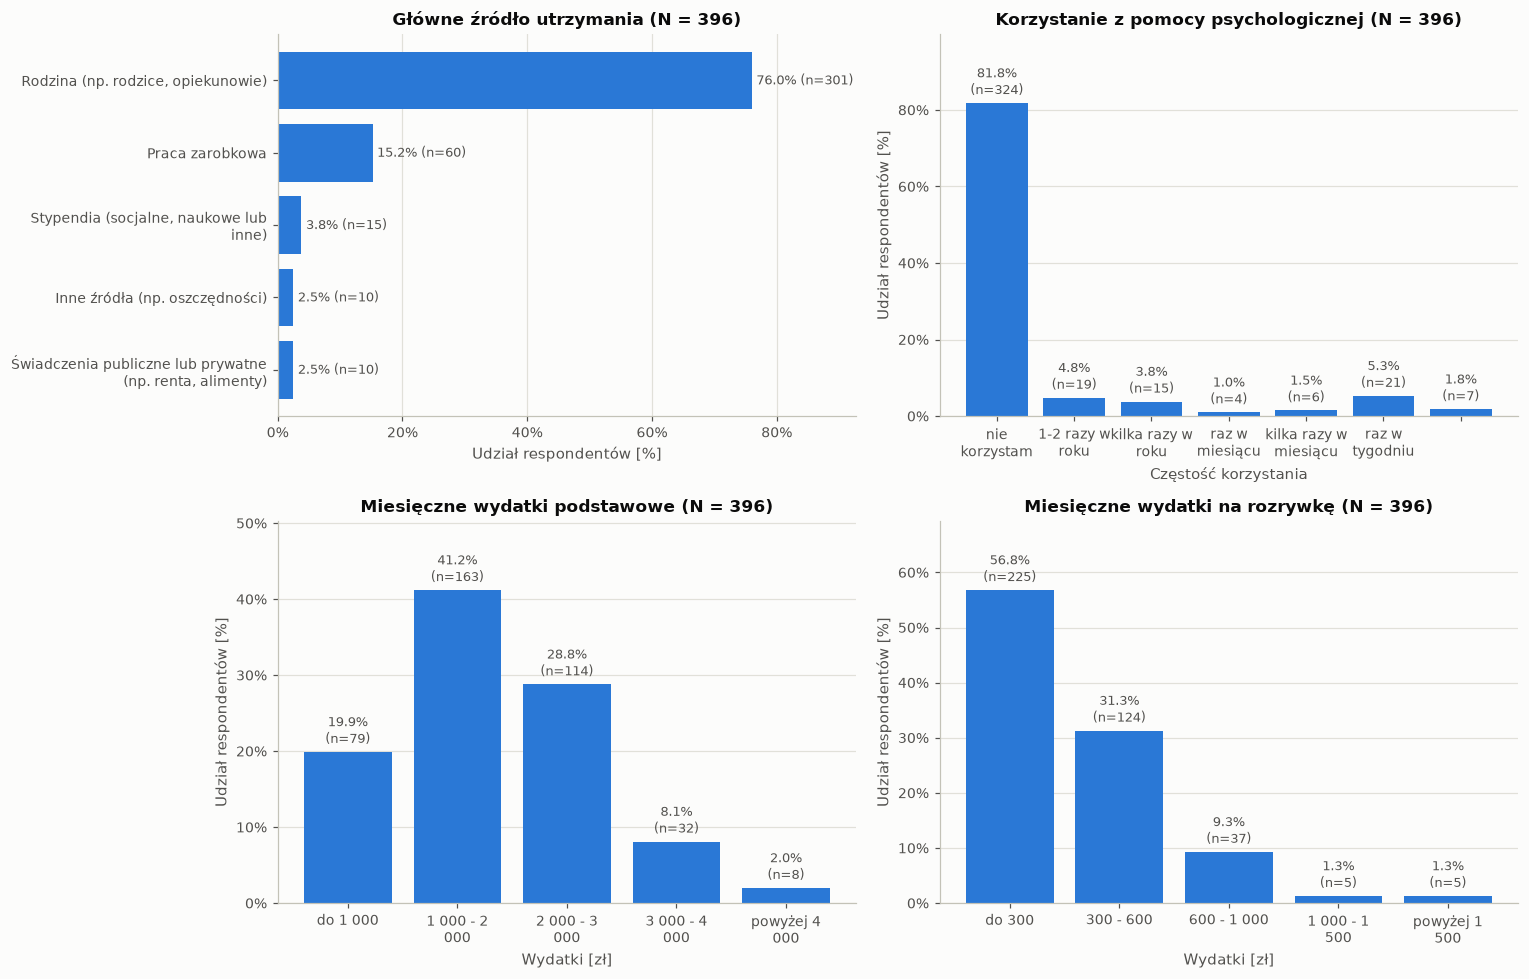

In [84]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

pl.plot_distribution(
    df, "zrodlo_utrzymania",
    sort="count", horizontal=True, wrap=34,
    title="Główne źródło utrzymania",
    ax=axes[0, 0],
)
pl.plot_distribution(
    df, "czestosc_pomoc_psych",
    value_labels=WARTOSCI("czestosc_pomoc_psych"), wrap=12,
    title="Korzystanie z pomocy psychologicznej",
    xlabel="Częstość korzystania",
    ax=axes[0, 1],
)
pl.plot_distribution(
    df, "wydatki_podstawowe",
    value_labels=WARTOSCI("wydatki_podstawowe"), wrap=12,
    title="Miesięczne wydatki podstawowe",
    xlabel="Wydatki [zł]",
    ax=axes[1, 0],
)
pl.plot_distribution(
    df, "wydatki_rozrywka",
    value_labels=WARTOSCI("wydatki_rozrywka"), wrap=12,
    title="Miesięczne wydatki na rozrywkę",
    xlabel="Wydatki [zł]",
    ax=axes[1, 1],
)

fig.tight_layout()

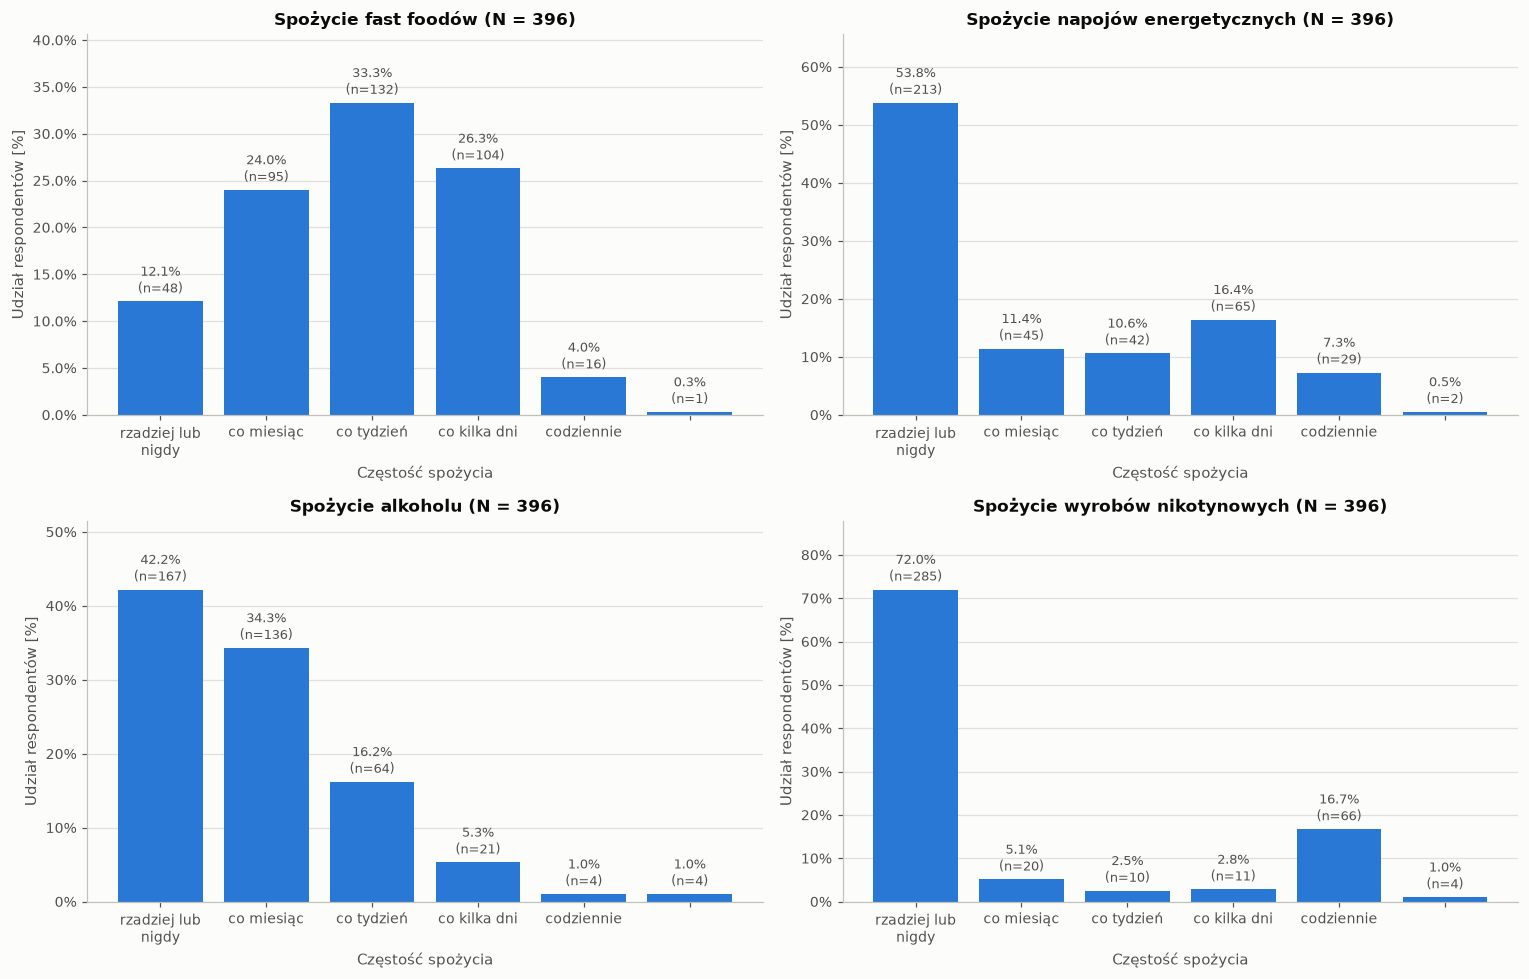

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for osie, (kolumna, tytul) in zip(
    axes.ravel(),
    [
        ("czestosc_fastfood", "Spożycie fast foodów"),
        ("czestosc_energetyki", "Spożycie napojów energetycznych"),
        ("czestosc_alkohol", "Spożycie alkoholu"),
        ("czestosc_nikotyna", "Spożycie wyrobów nikotynowych"),
    ],
):
    pl.plot_distribution(
        df, kolumna,
        value_labels=WARTOSCI(kolumna), wrap=12,
        title=tytul, xlabel="Częstość spożycia",
        ax=osie,
    )

fig.tight_layout()

## 15.3 Macierz korelacji wszystkich zmiennych liczbowych

Pełne zestawienie korelacji Spearmana. Służy jako materiał pomocniczy — wartości nie były korygowane na wielokrotne testowanie i nie należy na ich podstawie formułować wniosków o istotności.

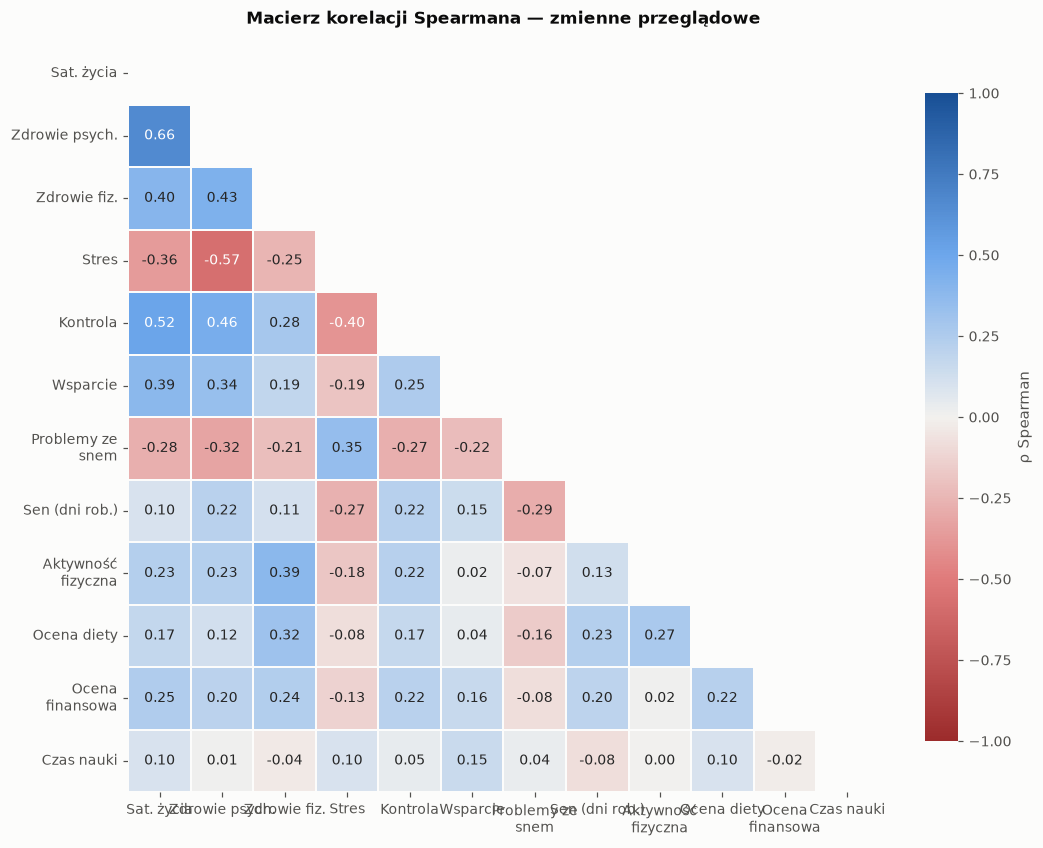

In [86]:
ZMIENNE_PRZEGLADOWE = [
    "sat_zycie", "sat_zdrowie_psych", "sat_zdrowie_fiz", "poziom_stresu",
    "poczucie_kontroli", "poziom_wsparcia", "problemy_sen", "sen_h_dni_robocze",
    "aktywnosc_fiz_h_tydz", "ocena_diety", "ocena_finansowa", "nauka_h_tydz",
]

_ = pl.plot_correlation_heatmap(
    df,
    columns=ZMIENNE_PRZEGLADOWE,
    labels=ETYKIETY,
    title="Macierz korelacji Spearmana — zmienne przeglądowe",
    figsize=(11, 9),
)

## 15.4 Odtworzenie analizy

Raport jest w pełni odtwarzalny. Aby uruchomić go od zera:

```bash
python -m venv .venv
.venv/Scripts/activate          # Linux/macOS: source .venv/bin/activate
pip install -r requirements.txt
jupyter lab notebooks/raport.ipynb
```

Kod przygotowania danych, testów statystycznych i wykresów znajduje się w pakiecie `src/dobrostan`. Opis decyzji metodologicznych zawiera `docs/metodologia.md`.